# **Data Understanding**

 ## Import libraries and setup environment

In [ ]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,  LabelEncoder
from tensorflow import keras
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Embedding
from tensorflow.keras.layers import Input, Concatenate, MultiHeadAttention, LayerNormalization, Add, Dropout, Flatten, GlobalAveragePooling1D
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

##Loading the Dataset

In [ ]:
df = pd.read_csv('/content/hotel_bookings.csv')

In [ ]:
print("Dataset shape:", df.shape)

Dataset shape: (119390, 32)


In [ ]:
print(df.columns)

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')


In [ ]:
print("Dataset first 5 rows:" , df.head(5))

Dataset first 5 rows:           hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...  

In [ ]:
print("Dataset information:" , df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [ ]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


,proportion
is_canceled,
0,0.629584
1,0.370416


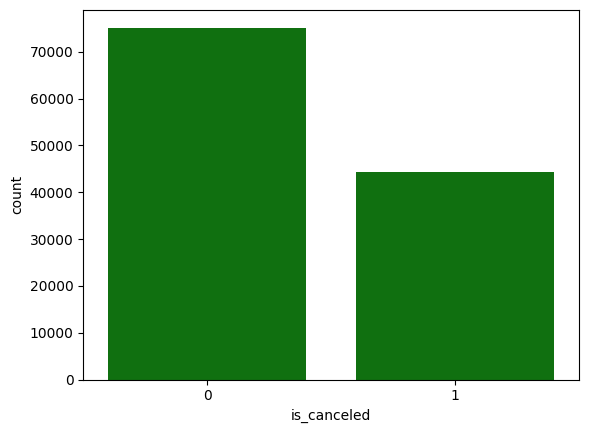

In [ ]:
import seaborn as sns
sns.countplot(data=df, x='is_canceled', color= 'green')


df['is_canceled'].value_counts(normalize=True)

# **Exploratory Insights & Behavioral Patterns**

### Deposit Type vs. Cancellation Rate

<ipython-input-240-ac6ef38b20e9>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='deposit_type', y='is_canceled', estimator=np.mean, palette='Set2')


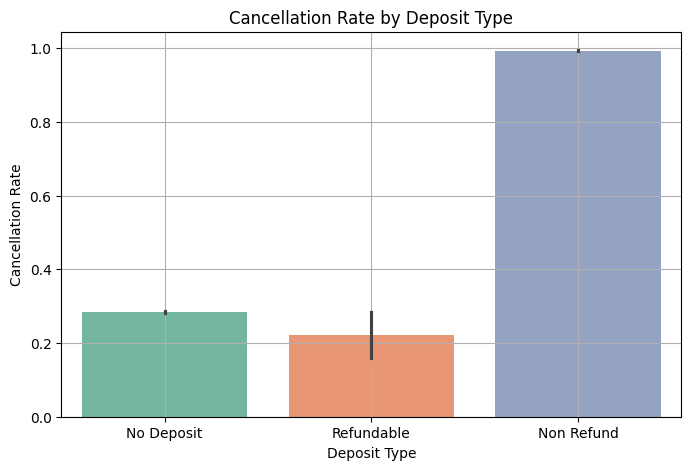

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='deposit_type', y='is_canceled', estimator=np.mean, palette='Set2')
plt.title("Cancellation Rate by Deposit Type")
plt.ylabel("Cancellation Rate")
plt.xlabel("Deposit Type")
plt.grid(True)
plt.show()

### Hotel Booking Proportions by Market Segment

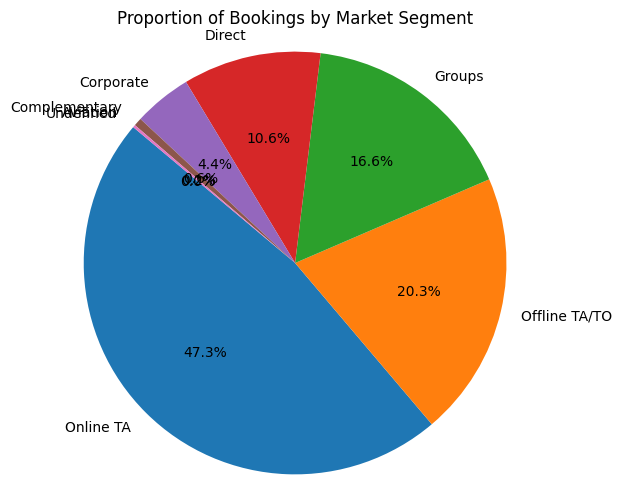

In [ ]:
segment_data = df['market_segment'].value_counts(normalize=True)
plt.figure(figsize=(6, 6))
plt.pie(segment_data, labels=segment_data.index, autopct='%1.1f%%', startangle=140)
plt.title('Proportion of Bookings by Market Segment')
plt.axis('equal')
plt.show()

### Distribution of Special Requests

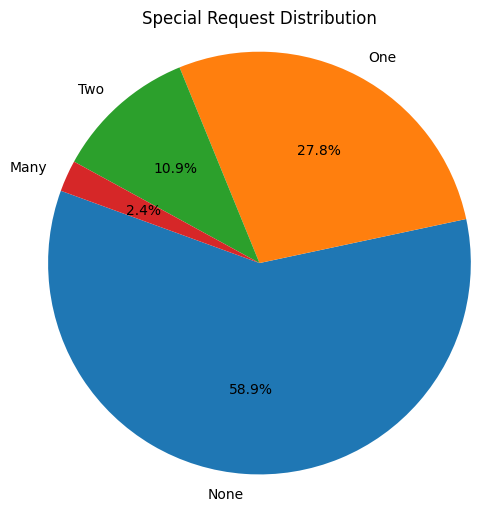

In [ ]:
special_requests = pd.cut(df['total_of_special_requests'], bins=[-1, 0, 1, 2, 5], labels=['None', 'One', 'Two', 'Many'])
req_counts = special_requests.value_counts()
plt.figure(figsize=(6, 6))
plt.pie(req_counts, labels=req_counts.index, autopct='%1.1f%%', startangle=160)
plt.title('Special Request Distribution')
plt.axis('equal')
plt.show()

###  Histogram: Room Type Assignments Frequency


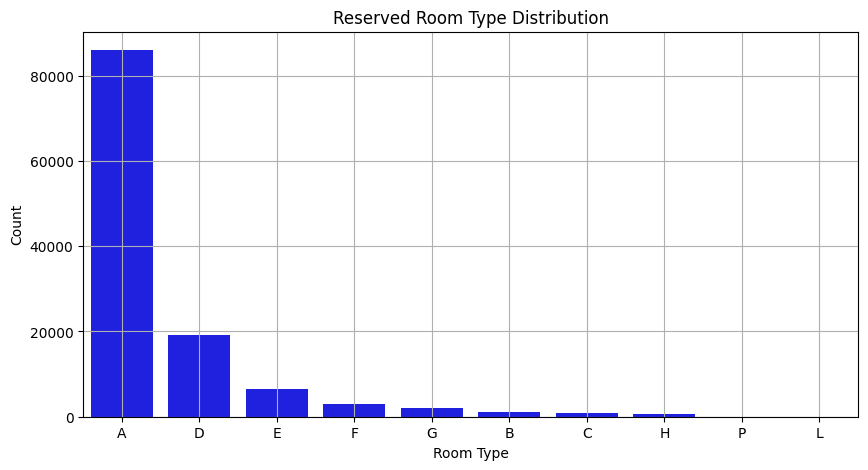

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df,
              x='reserved_room_type',
              order=df['reserved_room_type'].value_counts().index,
              color="blue")
plt.title('Reserved Room Type Distribution')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.grid(True)
plt.show()

### KDE Plot: Length of Stay (not grouped by cancellation)

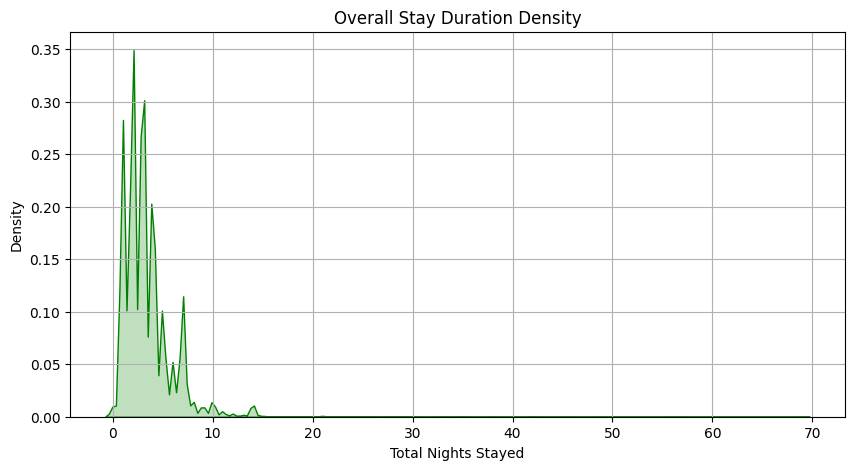

In [ ]:
plt.figure(figsize=(10, 5))
stay_duration = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
sns.kdeplot(stay_duration, fill=True, color = "green")
plt.title('Overall Stay Duration Density')
plt.xlabel('Total Nights Stayed')
plt.grid(True)
plt.show()


### Simulated ADR Prediction vs Actual Values

<ipython-input-239-f11178bcbba7>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['adr_predicted'] = df_filtered['adr'] * 0.9 + np.random.normal(0, 10, len(df_filtered))


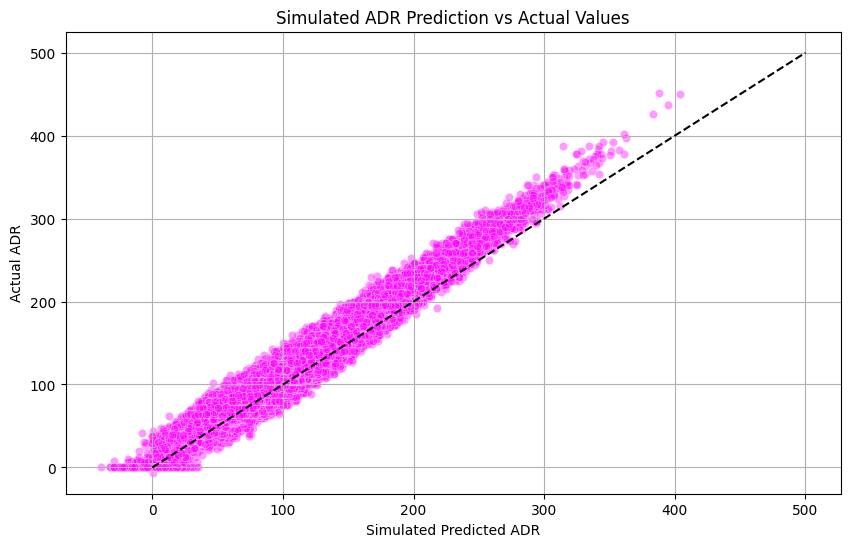

In [ ]:
# Flip axes and limit extreme values for better clarity
df_filtered = df[df['adr'] < 500]  # remove extreme outliers

# Simulate prediction
df_filtered['adr_predicted'] = df_filtered['adr'] * 0.9 + np.random.normal(0, 10, len(df_filtered))

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='adr_predicted', y='adr', data=df_filtered, alpha=0.4, color = "Magenta")
plt.plot([0, 500], [0, 500], 'k--')
plt.xlabel("Simulated Predicted ADR")
plt.ylabel("Actual ADR")
plt.title("Simulated ADR Prediction vs Actual Values")
plt.grid(True)
plt.show()


### Lead Time Grouped by Year

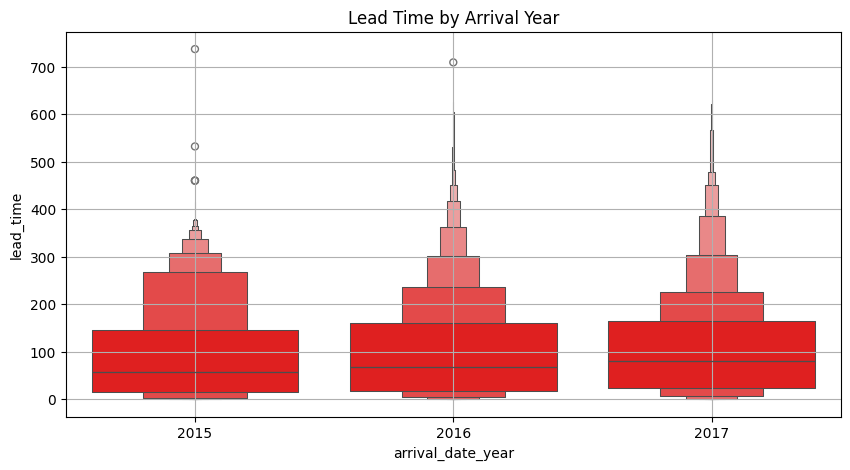

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxenplot(data=df, x='arrival_date_year', y='lead_time', color= "red")
plt.title('Lead Time by Arrival Year')
plt.grid(True)
plt.show()

### Customer Count vs. Hotel

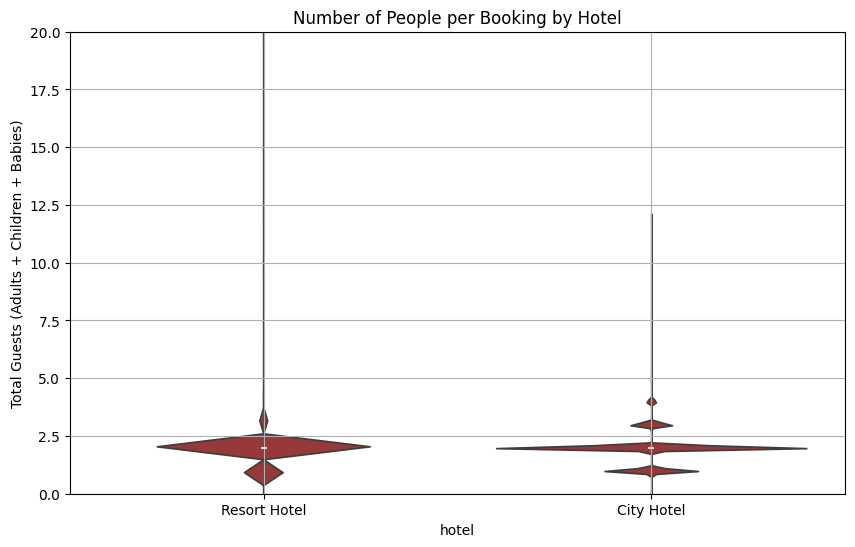

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='hotel',
               y=df['adults'] + df['children'].fillna(0) + df['babies'],
               data=df, color = "brown")
plt.title("Number of People per Booking by Hotel")
plt.ylabel("Total Guests (Adults + Children + Babies)")
plt.grid(True)
plt.ylim(0, 20)
plt.show()


### Treemap: Country Contribution to Children Bookings

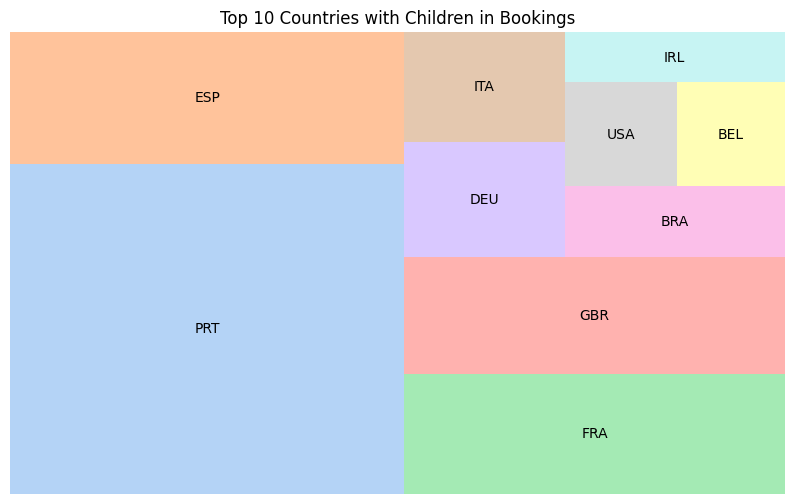

In [ ]:
!pip install squarify

import squarify

children_data = df[df['children'] > 0]
top_kids_countries = children_data['country'].value_counts().head(10)

plt.figure(figsize=(10, 6))
squarify.plot(sizes=top_kids_countries.values,
              label=top_kids_countries.index,
              alpha=0.8,
              color=sns.color_palette('pastel'))
plt.title("Top 10 Countries with Children in Bookings")
plt.axis('off')
plt.show()


### Outlier Boxplots

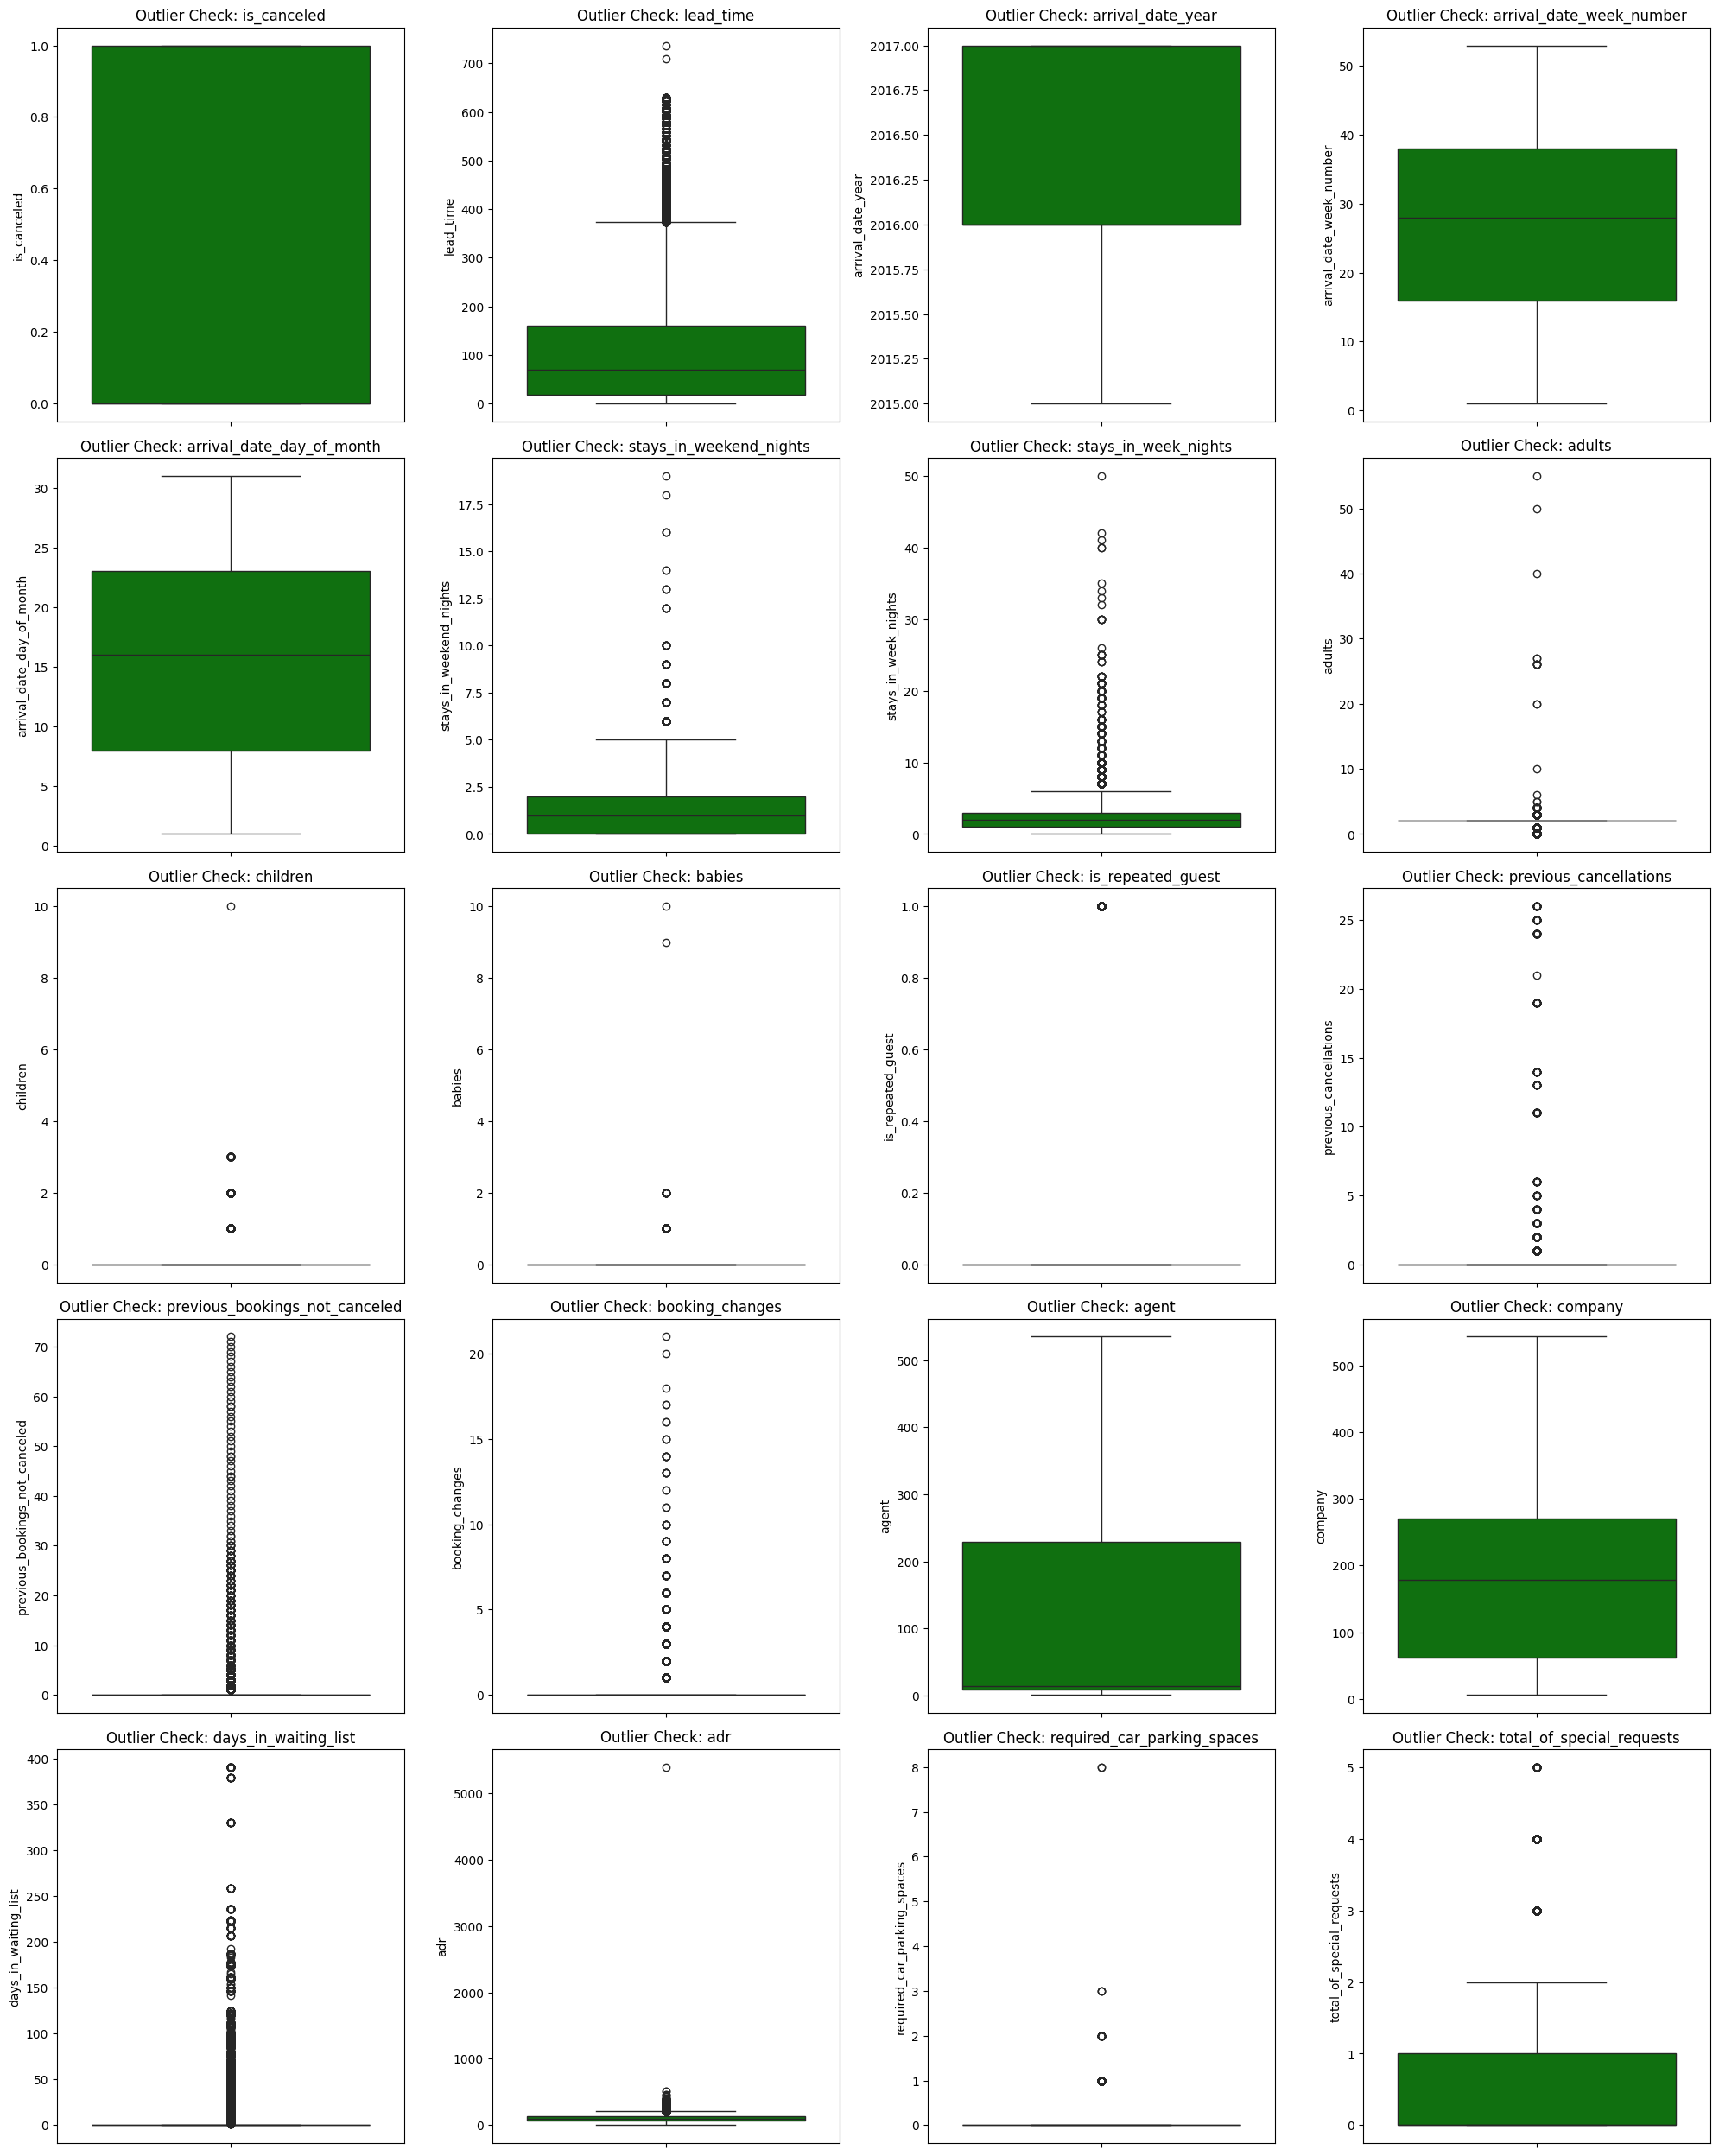

In [ ]:
# Identify numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Plot boxplots for each numeric column
fig, axes = plt.subplots(nrows=len(numeric_cols)//4 + 1, ncols=4, figsize=(20, 5*(len(numeric_cols)//4 + 1)))

for idx, col in enumerate(numeric_cols):
    row, col_idx = divmod(idx, 4)
    ax = axes[row, col_idx]
    sns.boxplot(y=df[col], ax=ax, color='green')
    ax.set_title(f'Outlier Check: {col}')

# Hide unused subplots
for i in range(len(numeric_cols), len(axes.flatten())):
    fig.delaxes(axes.flatten()[i])

plt.tight_layout()
plt.show()

###  Correlation Heatmap of numerical features

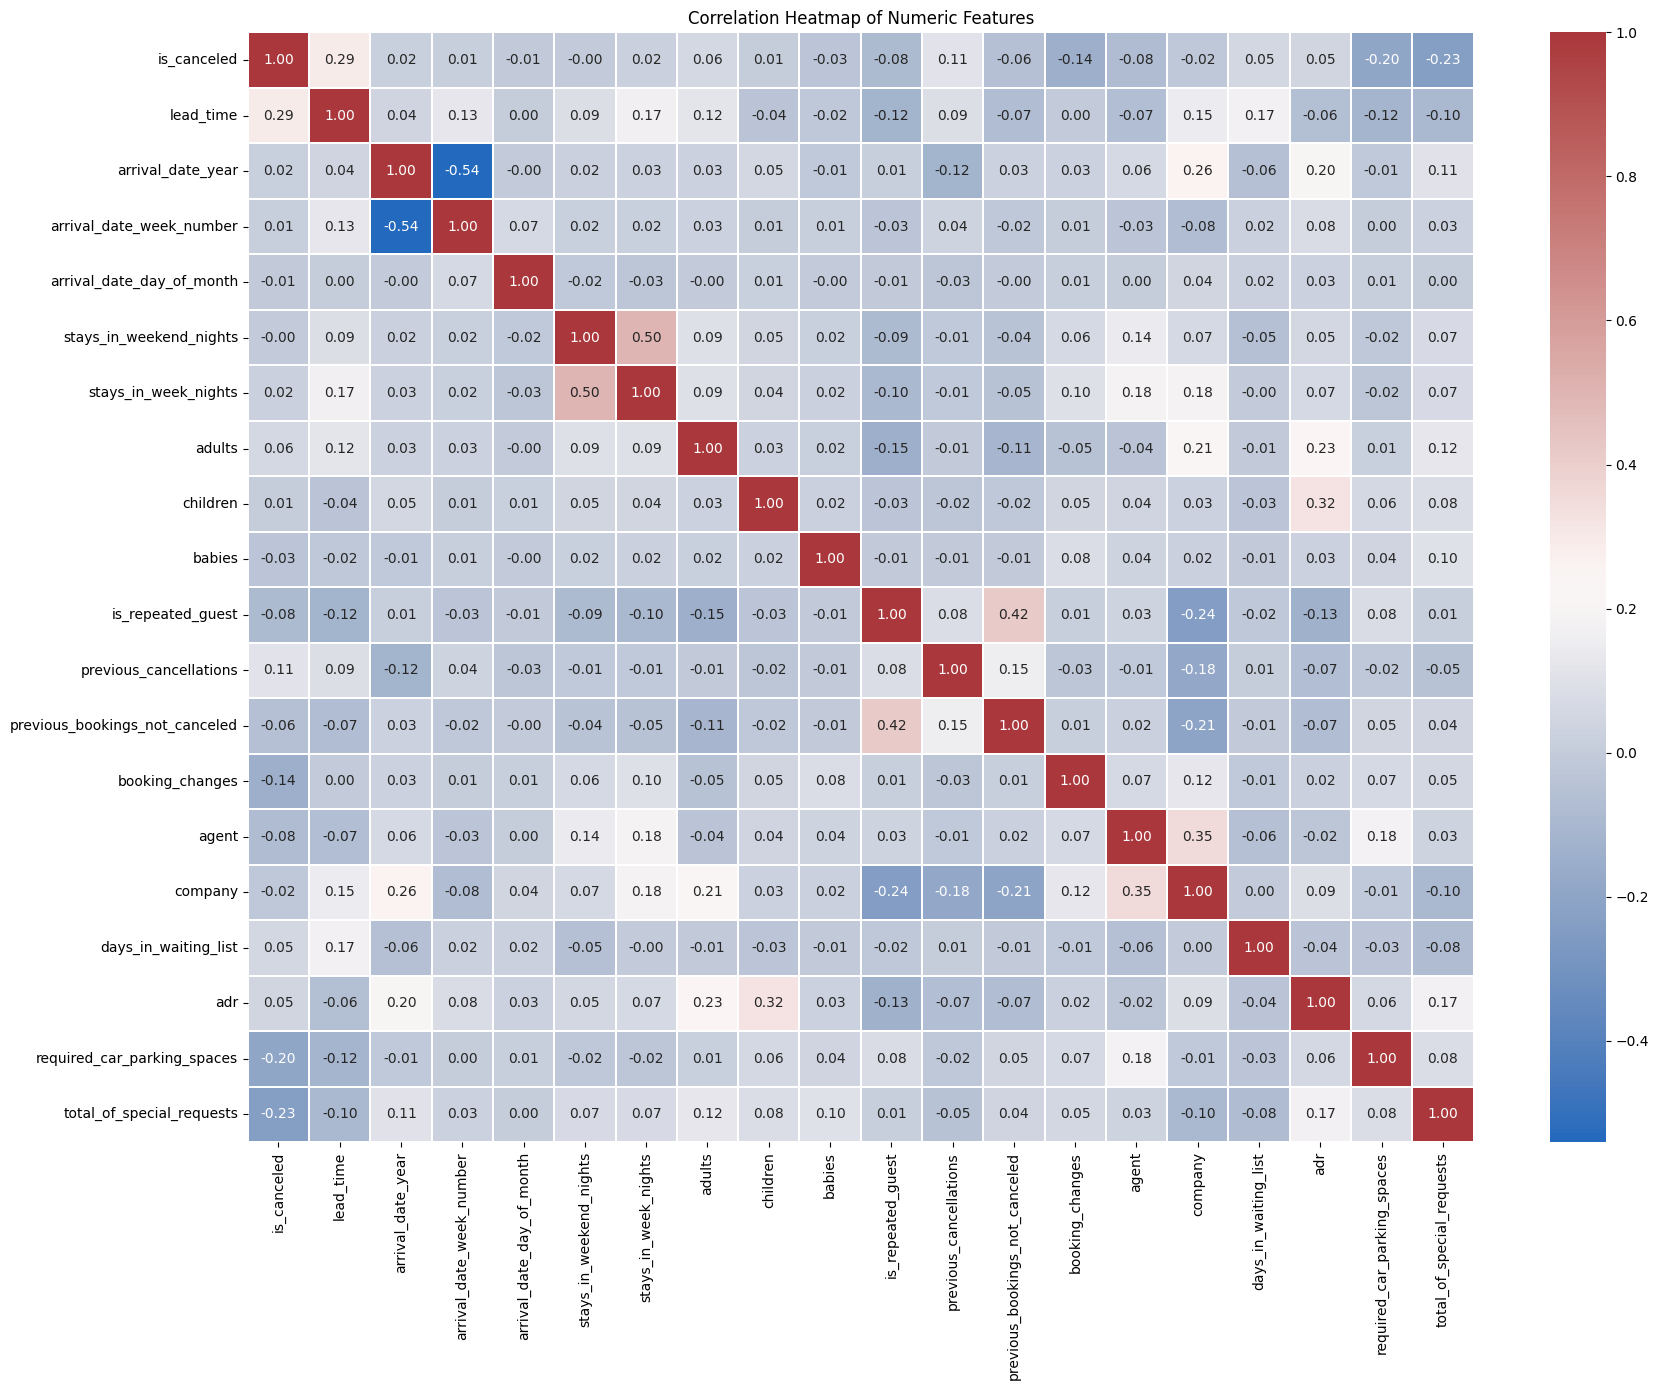

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(18, 14))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap='vlag', linewidths=0.3)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()


###  FacetGrid: Distribution of lead_time by hotel and cancellation

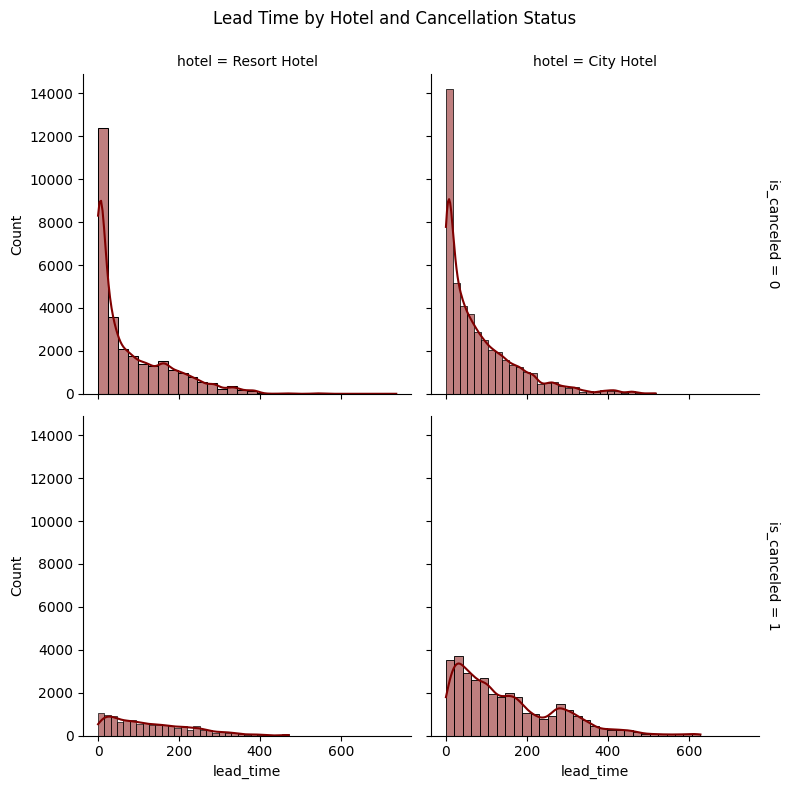

In [ ]:
g = sns.FacetGrid(df, col="hotel", row="is_canceled", height=4, margin_titles=True)
g.map_dataframe(sns.histplot, x="lead_time", bins=30, kde=True, color="maroon")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Lead Time by Hotel and Cancellation Status")
plt.show()

###  Pairplot of selected features

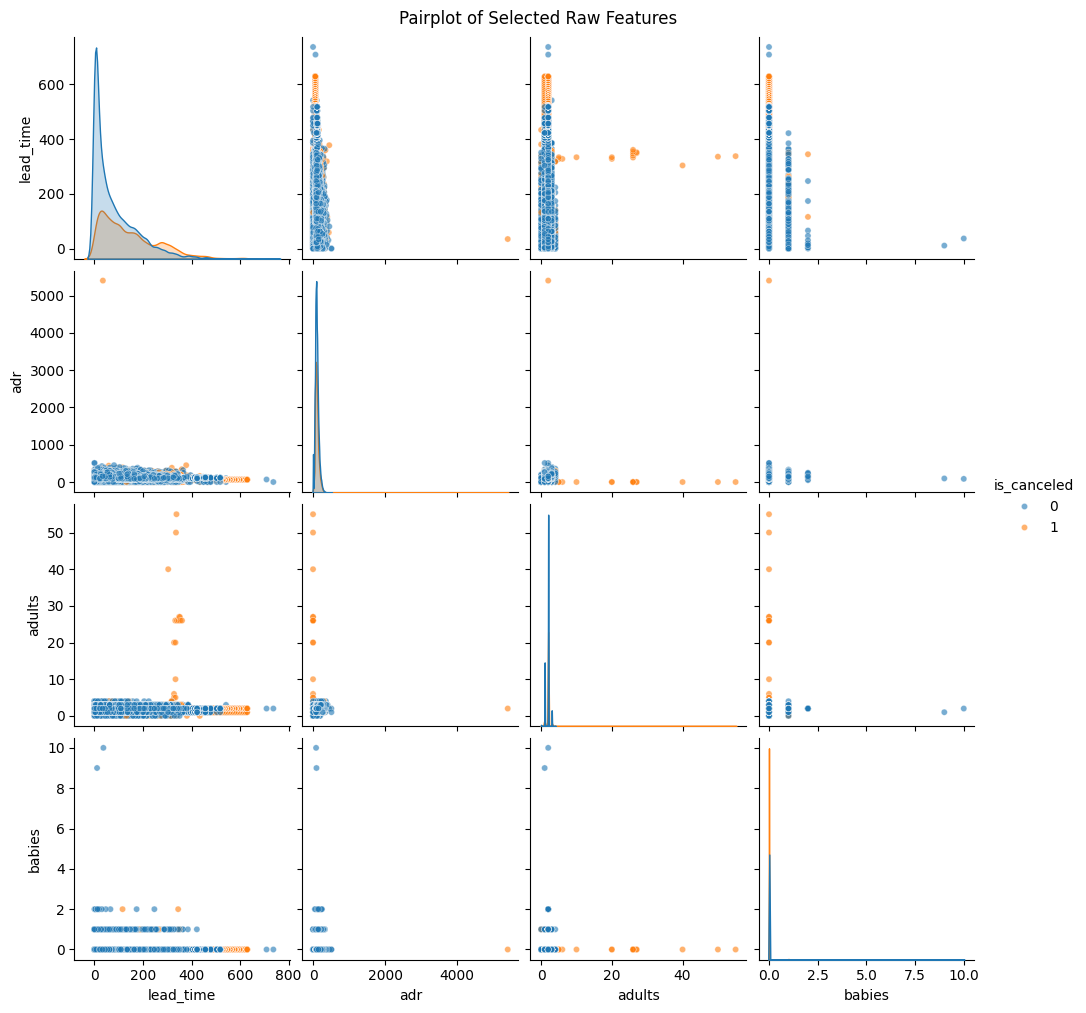

In [ ]:
pairplot_cols = ['lead_time', 'adr', 'adults', 'babies', 'is_canceled']
sns.pairplot(df[pairplot_cols], hue='is_canceled', plot_kws={'alpha': 0.6, 's': 20})
plt.suptitle("Pairplot of Selected Raw Features", y=1.01)
plt.show()

#**Data Preprocessing**

### Irrelevant columns drop and Data Cleaning (Handle Missing Values)

In [ ]:
# Drop irrelevant or leakage-prone columns
irrelevant_cols = [
    'company', 'agent', 'reservation_status', 'reservation_status_date'
    , 'assigned_room_type', 'booking_changes'
]

df.drop(columns=[col for col in irrelevant_cols if col in df.columns], inplace=True)

In [ ]:
# Handle missing values

# Fill missing children with 0 (assuming missing means 0 children)
if 'children' in df.columns:
    df['children'].fillna(0, inplace=True)

# Fill missing country with 'Unknown'
if 'country' in df.columns:
    df['country'].fillna('Unknown', inplace=True)

# Confirm no remaining missing values
print("Missing values per column:\n", df.isnull().sum())


Missing values per column:
 hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests         0
dtype: int64


<ipython-input-11-d799b284ed79>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['children'].fillna(0, inplace=True)
<ipython-input-11-d799b284ed79>:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.meth

###  Feature Engineering


In [ ]:
cols_to_fix = ['adults', 'children', 'babies', 'stays_in_week_nights', 'stays_in_weekend_nights', 'days_in_waiting_list']
df[cols_to_fix] = df[cols_to_fix].apply(pd.to_numeric, errors='coerce')

In [ ]:
# Add engineered features
df['total_guests'] = df['adults'] + df['children'] + df['babies']
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['was_waitlisted'] = (df['days_in_waiting_list'] > 0).astype(int)
df['is_family'] = ((df['children'] + df['babies']) > 0).astype(int)

### Feature/Target Definition

In [ ]:
# Defining target and features
y = df['is_canceled']
X = df.drop('is_canceled', axis=1)

####  Encoding

In [ ]:
# Identify categorical and numeric features
cat_cols = X.select_dtypes(include='object').columns.tolist()
numeric_cols = [col for col in X.columns if col not in cat_cols]

# One-hot encode categorical features
X = pd.get_dummies(X, columns=cat_cols, drop_first=False, dummy_na=False)
print("Features after one-hot encoding:", X.shape)

Features after one-hot encoding: (119390, 247)


#### Clip outliers

In [ ]:
# Clip outliers for all numeric columns
for col in X.select_dtypes(include=['int64', 'float64']).columns:
    upper = X[col].quantile(0.99)
    X[col] = X[col].clip(upper=upper)
    print(f"Clipped {col} at: {upper:.2f}")

adr_upper = X['adr'].quantile(0.99)
lead_time_upper = X['lead_time'].quantile(0.99)
print(f"Clipped ADR at: {adr_upper:.2f}")
print(f"Clipped Lead Time at: {lead_time_upper:.2f}")

print("Clipped outliers for all numeric features.")

Clipped lead_time at: 444.00
Clipped arrival_date_year at: 2017.00
Clipped arrival_date_week_number at: 53.00
Clipped arrival_date_day_of_month at: 31.00
Clipped stays_in_weekend_nights at: 4.00
Clipped stays_in_week_nights at: 10.00
Clipped adults at: 3.00
Clipped children at: 2.00
Clipped babies at: 0.00
Clipped is_repeated_guest at: 1.00
Clipped previous_cancellations at: 1.00
Clipped previous_bookings_not_canceled at: 3.00
Clipped days_in_waiting_list at: 75.00
Clipped adr at: 252.00
Clipped required_car_parking_spaces at: 1.00
Clipped total_of_special_requests at: 3.00
Clipped total_guests at: 4.00
Clipped total_nights at: 14.00
Clipped was_waitlisted at: 1.00
Clipped is_family at: 1.00
Clipped ADR at: 252.00
Clipped Lead Time at: 444.00
Clipped outliers for all numeric features.


### Scaling

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# MinMax scaling for CNN
X_minmax = X.copy()
scaler_mm = MinMaxScaler()
X_minmax[numeric_cols] = scaler_mm.fit_transform(X_minmax[numeric_cols])


### Balancing using SMOTE + Visualization

In [ ]:
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# Impute missing values
imputer = SimpleImputer(strategy='mean')
X_minmax[numeric_cols] = imputer.fit_transform(X_minmax[numeric_cols])

# Apply SMOTE
smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X_minmax, y)


Before SMOTE:
 is_canceled
0    75166
1    44224
Name: count, dtype: int64


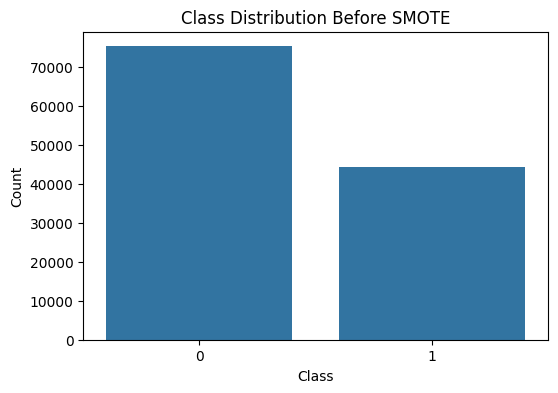

After SMOTE:
 is_canceled
0    75166
1    75166
Name: count, dtype: int64


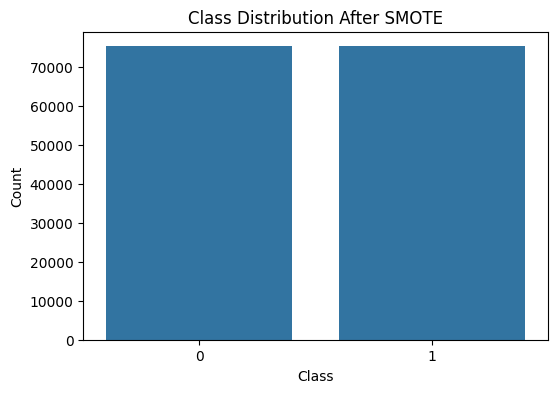

In [ ]:
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# Check class distribution before SMOTE
print("Before SMOTE:\n", y.value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Apply SMOTE
smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X_minmax, y)

# Check class distribution after SMOTE
print("After SMOTE:\n", y_bal.value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x=y_bal)
plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

###  Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# Stratified split using MinMax-scaled + SMOTE-balanced data
X_train, X_test, y_train, y_test = train_test_split(
    X_minmax, y, test_size=0.2, stratify=y, random_state=42
)

# Convert to float32 for TensorFlow models
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

print("Training set size:", X_train.shape[0], "Testing set size:", X_test.shape[0])

Training set size: 95512 Testing set size: 23878


In [ ]:
# Further split training set into train and validation
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

 ### Reshape

In [ ]:
# Reshape for CNN
X_train_seq = X_train_final.astype(np.float32).values.reshape(X_train_final.shape[0], X_train_final.shape[1], 1)
X_test_seq = X_test.astype(np.float32).values.reshape(X_test.shape[0], X_test.shape[1], 1)
X_val_seq = X_val.astype(np.float32).values.reshape(X_val.shape[0], X_val.shape[1], 1)

# y is already a NumPy array if split from np arrays
y_train_arr = y_train
y_test_arr = y_test

# **EDA after Preprocessing**

### Outlier check on key numeric features

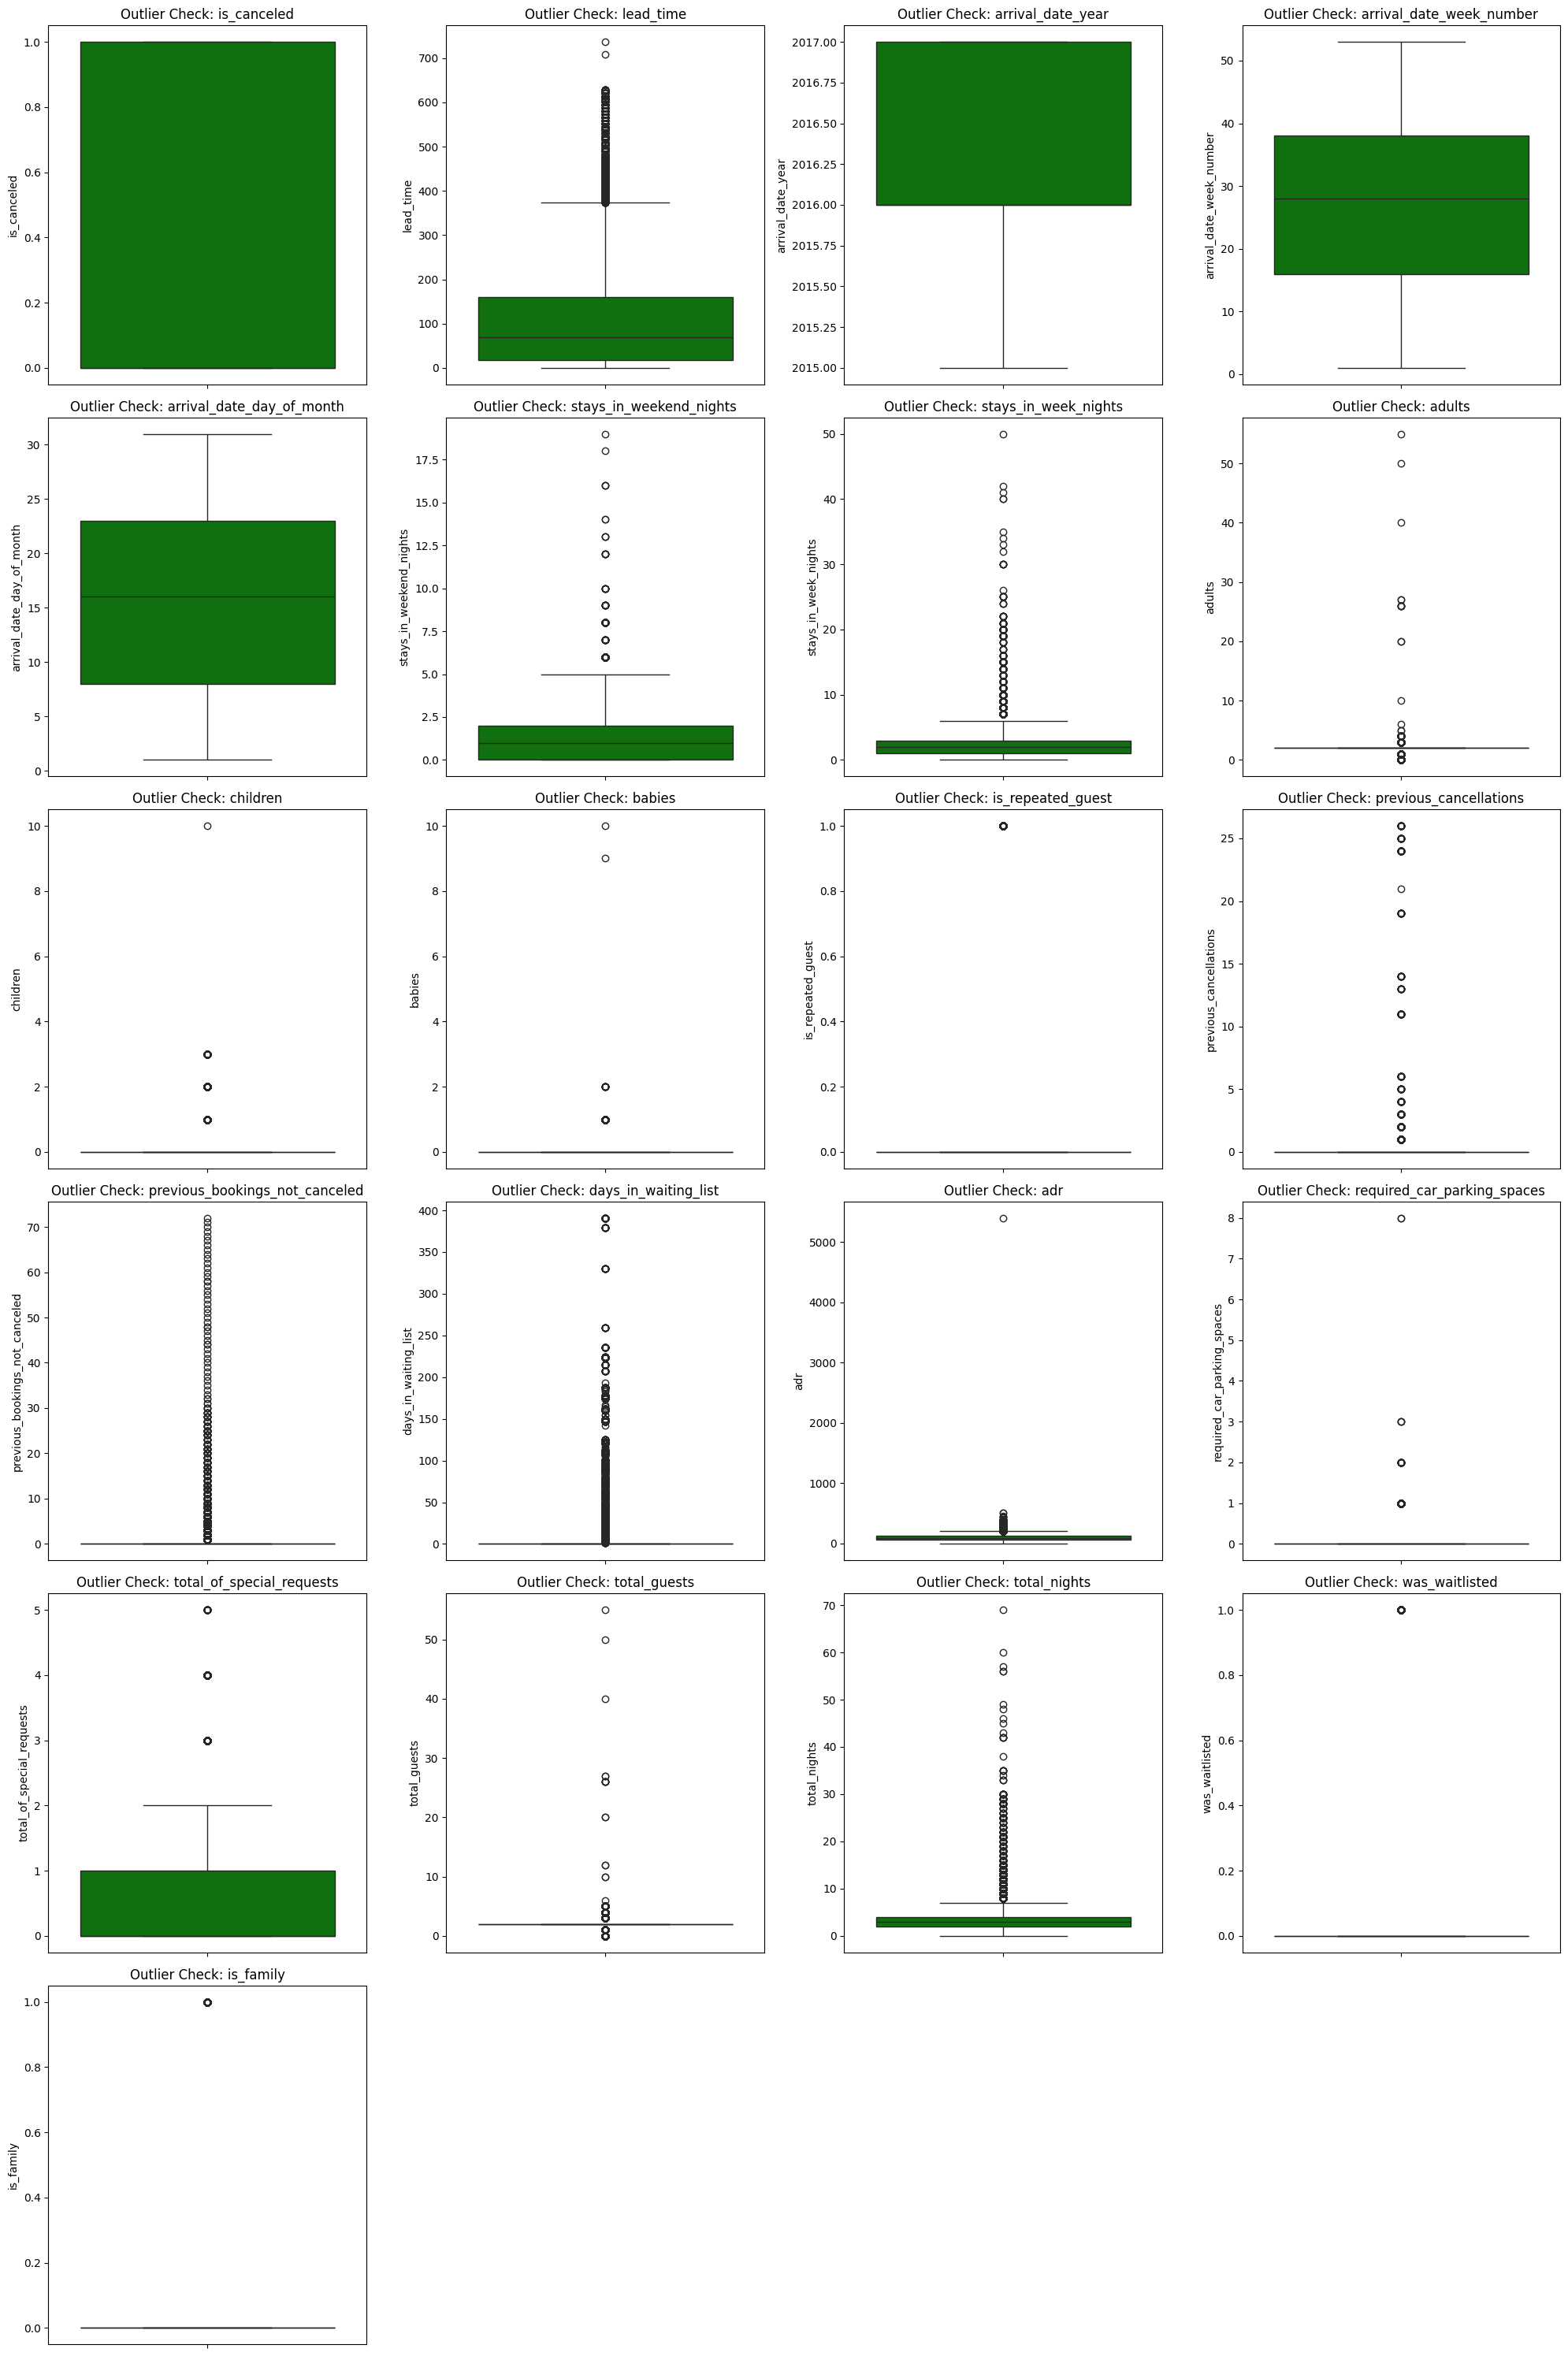

In [ ]:
# Identify numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Plot boxplots for each numeric column
fig, axes = plt.subplots(nrows=len(numeric_cols)//4 + 1, ncols=4, figsize=(20, 5*(len(numeric_cols)//4 + 1)))

for idx, col in enumerate(numeric_cols):
    row, col_idx = divmod(idx, 4)
    ax = axes[row, col_idx]
    sns.boxplot(y=df[col], ax=ax, color='green')
    ax.set_title(f'Outlier Check: {col}')

# Hide unused subplots
for i in range(len(numeric_cols), len(axes.flatten())):
    fig.delaxes(axes.flatten()[i])

plt.tight_layout()
plt.show()

## Histograms of Key Numeric Features After Preprocessing

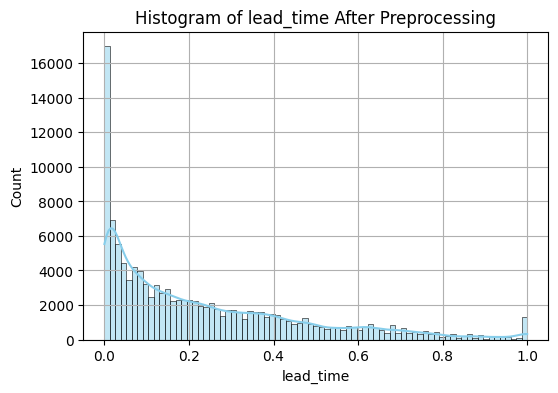

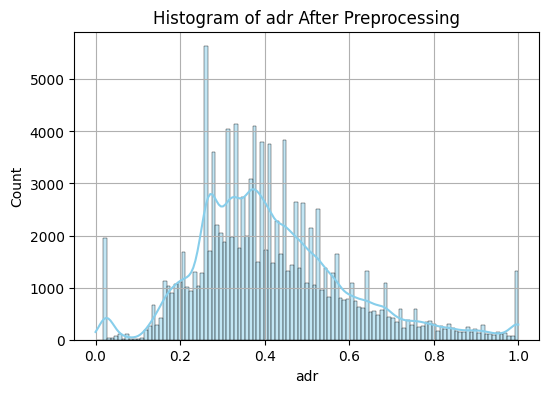

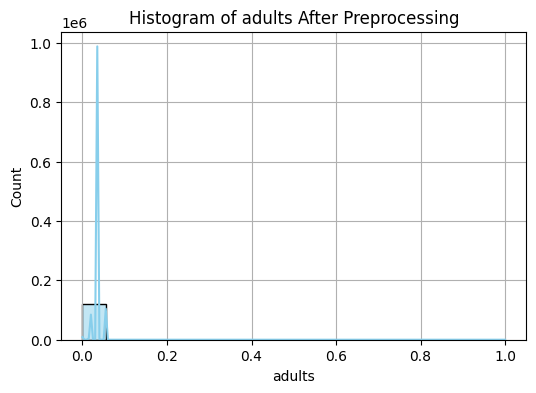

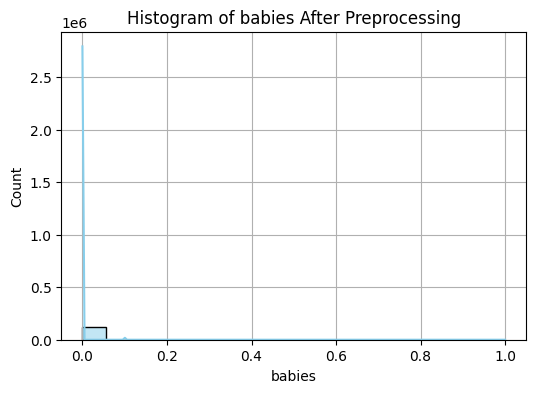

In [ ]:
numeric_cols = ['lead_time', 'adr', 'adults', 'babies']
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=X_minmax, x=col, kde=True, color='skyblue')
    plt.title(f'Histogram of {col} After Preprocessing')
    plt.grid(True)
    plt.show()

## Lead Time VS. ADR

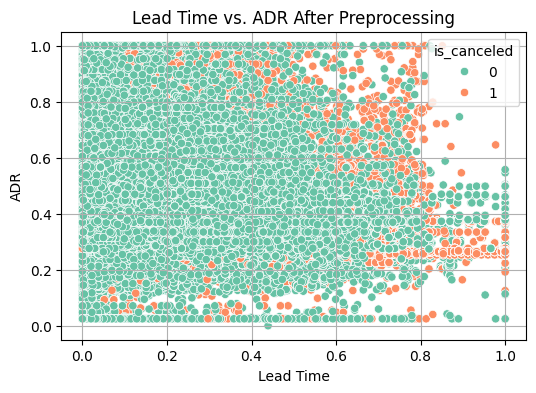

In [ ]:
# Scatterplot: Lead Time vs. ADR
plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_minmax['lead_time'], y=X_minmax['adr'], hue=y, palette='Set2')
plt.title('Lead Time vs. ADR After Preprocessing')
plt.xlabel('Lead Time')
plt.ylabel('ADR')
plt.grid(True)
plt.show()

# **Model Training**

## **1D - CNN**

### CNN Base Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GlobalAveragePooling1D, Dense
from tensorflow.keras.optimizers import Adam

# Define base CNN model
cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_seq.shape[1], 1)),
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    GlobalAveragePooling1D(),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile
cnn_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

cnn_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 67, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 65, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_22     │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,521 (29.38 KB)

 Trainable params: 7,521 (29.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history = cnn_model.fit(
    X_train_seq, y_train_final,
    validation_data=(X_val_seq, y_val),
    epochs=30,
    batch_size=64,
    verbose=1
)

Epoch 1/30
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6299 - loss: 0.6595 - val_accuracy: 0.6299 - val_loss: 0.6422
Epoch 2/30
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6482 - loss: 0.6340 - val_accuracy: 0.7122 - val_loss: 0.5958
Epoch 3/30
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7097 - loss: 0.5933 - val_accuracy: 0.7244 - val_loss: 0.5685
Epoch 4/30
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7224 - loss: 0.5711 - val_accuracy: 0.7269 - val_loss: 0.5548
Epoch 5/30
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7277 - loss: 0.5591 - val_accuracy: 0.7315 - val_loss: 0.5456
Epoch 6/30
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7333 - loss: 0.5505 - val_accuracy: 0.7323 - val_loss: 0.5392
Epoch 7/30
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7357 - loss: 0.5441 - val_accuracy: 0.7343 - val_loss: 0.5347
Epoch 8/30
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7384 - loss: 0.5392 -

In [ ]:
# Find Best Epoch Accuracy
best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_train_acc = history.history['accuracy'][best_epoch - 1]
best_train_loss = history.history['loss'][best_epoch - 1]
best_val_acc = history.history['val_accuracy'][best_epoch - 1]
best_val_loss = history.history['val_loss'][best_epoch - 1]

print(f"Best Epoch: {best_epoch}")
print(f"Training Accuracy: {best_train_acc:.4f}")
print(f"Training Loss: {best_train_loss:.4f}")
print(f"Validation Accuracy: {best_val_acc:.4f}")
print(f"Validation Loss: {best_val_loss:.4f}")

Best Epoch: 29
Training Accuracy: 0.7577
Training Loss: 0.5018
Validation Accuracy: 0.7576
Validation Loss: 0.4946


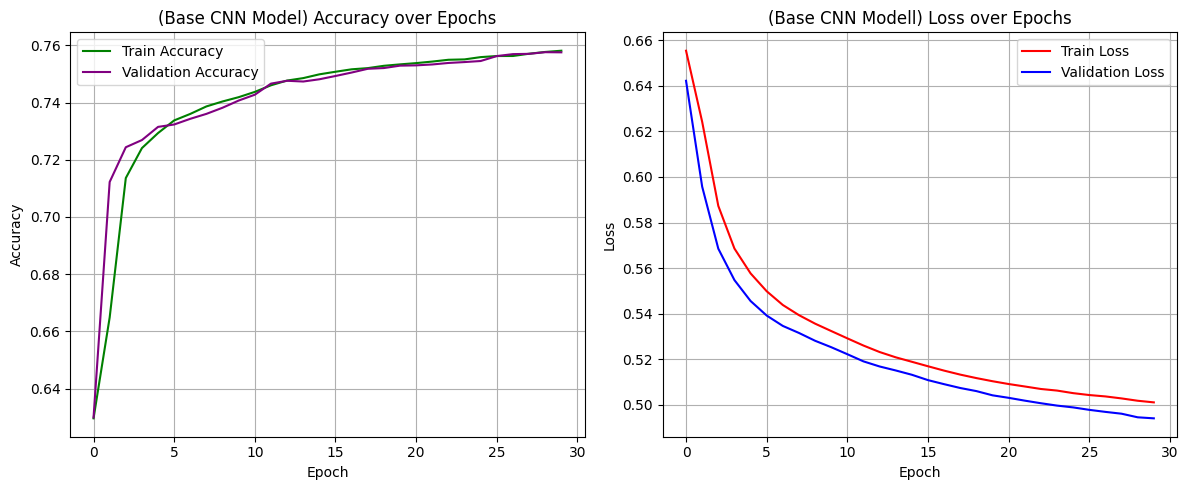

In [ ]:
# Accuracy & Loss Plot for CNN Model
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='purple')
plt.title('(Base CNN Model) Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.title('(Base CNN Modell) Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

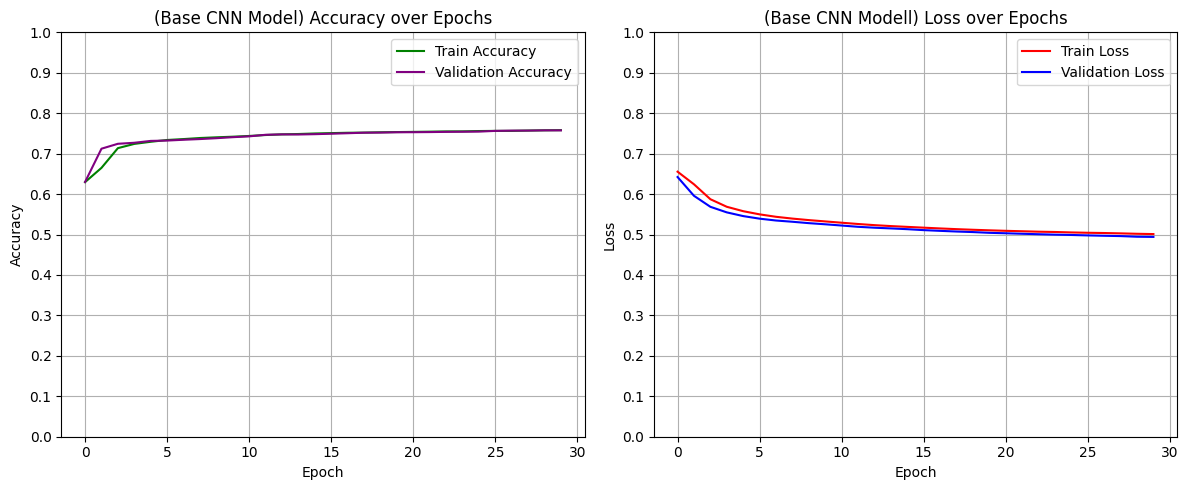

In [ ]:
# Accuracy & Loss Plot for CNN Model
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='purple')
plt.title('(Base CNN Model) Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0.0, 1.0)
plt.yticks([i / 10 for i in range(11)])
plt.grid(True)
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.title('(Base CNN Modell) Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0.0, 1.0)
plt.yticks([i / 10 for i in range(11)])
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


747/747 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


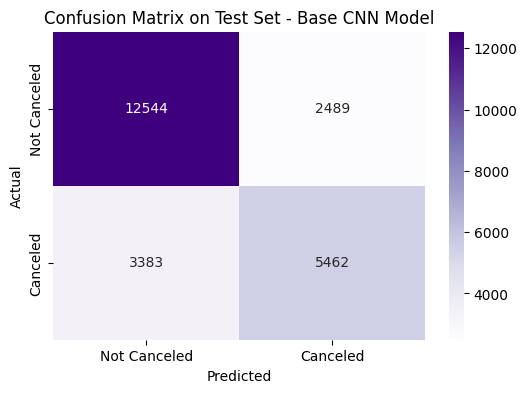


Classification Report for Base CNN Model:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81     15033
           1       0.69      0.62      0.65      8845

    accuracy                           0.75     23878
   macro avg       0.74      0.73      0.73     23878
weighted avg       0.75      0.75      0.75     23878



In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Predict
y_pred_val = (cnn_model.predict(X_test_seq) > 0.5).astype("int32")

# Confusion Matrix
cm = confusion_matrix(y_test_arr, y_pred_val)
labels = ['Not Canceled', 'Canceled']

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix on Test Set - Base CNN Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report for Base CNN Model:")
print(classification_report(y_test_arr, y_pred_val))

747/747 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


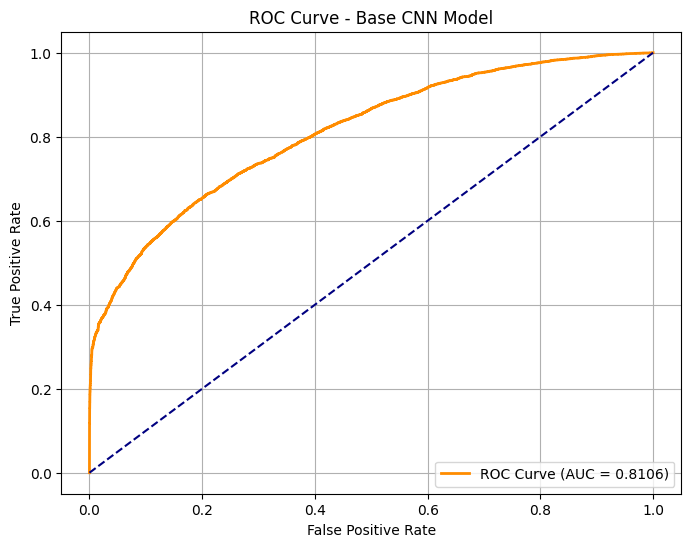

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities
y_pred_prob = cnn_model.predict(X_test_seq).ravel()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_arr, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Base CNN Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
# Final Test Accuracy and Loss for Base CNN Model
test_loss, test_accuracy = cnn_model.evaluate(X_test_seq, y_test_arr, verbose=0)

print(f"\nFinal Test Accuracy (Base CNN Model): {test_accuracy:.4f}")
print(f"Final Test Loss (Base CNN Model): {test_loss:.4f}")


Final Test Accuracy (Base CNN Model): 0.7541
Final Test Loss (Base CNN Model): 0.4978


747/747 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


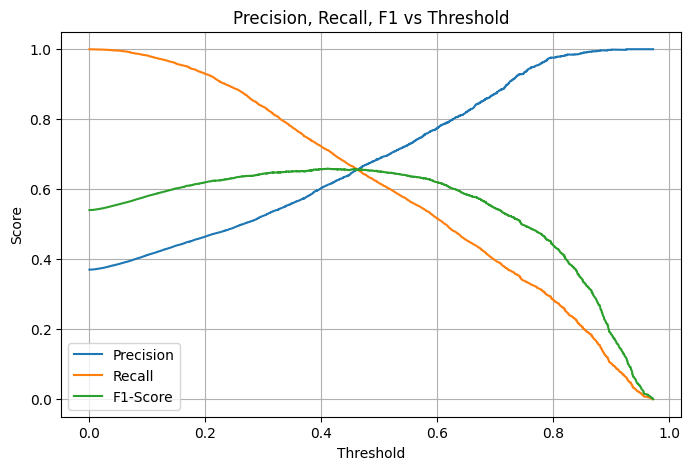

Best Threshold based on F1-Score: 0.4120


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score

# Predict probabilities
y_pred_prob = cnn_model.predict(X_test_seq).ravel()

# Calculate precision, recall, thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test_arr, y_pred_prob)

# Compute F1 for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-6)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1-Score')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, F1 vs Threshold')
plt.grid(True)
plt.legend()
plt.show()

# Get best threshold (highest F1)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Best Threshold based on F1-Score: {best_threshold:.4f}")

y_pred = (y_pred_prob >= best_threshold).astype("int32")

747/747 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


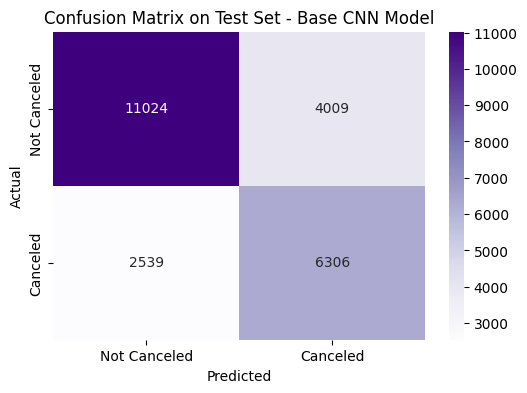


Classification Report for Base CNN Model:
              precision    recall  f1-score   support

           0       0.81      0.73      0.77     15033
           1       0.61      0.71      0.66      8845

    accuracy                           0.73     23878
   macro avg       0.71      0.72      0.71     23878
weighted avg       0.74      0.73      0.73     23878



In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Predict
y_pred_val = (cnn_model.predict(X_test_seq) > 0.41).astype("int32")

# Confusion Matrix
cm = confusion_matrix(y_test_arr, y_pred_val)
labels = ['Not Canceled', 'Canceled']

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix on Test Set - Base CNN Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report for Base CNN Model:")
print(classification_report(y_test_arr, y_pred_val))

### CNN with Focal Loss - Tuning 1

In [ ]:
import tensorflow as tf

def focal_loss(gamma=2., alpha=0.25):
    def loss_fn(y_true, y_pred):
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1. - tf.keras.backend.epsilon())
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        return alpha * tf.pow(1 - p_t, gamma) * bce
    return loss_fn

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2

cnn_focal_model = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(X_train_seq.shape[1], 1), kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(128, 3, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling1D(2),

    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

cnn_focal_model.compile(optimizer='adam',
                        loss=focal_loss(gamma=2., alpha=0.25),
                        metrics=['accuracy'])

cnn_focal_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 67, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 67, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 33, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 31, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 31, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 15, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1920)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 128)            │       245,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_57 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 271,745 (1.04 MB)

 Trainable params: 271,361 (1.04 MB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
X_train_seq = X_train_final.astype(np.float32).values.reshape(X_train_final.shape[0], X_train_final.shape[1], 1)
y_train_seq = y_train_final

# Train the model
history = cnn_focal_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val),
    epochs=50,
    batch_size=64,
    verbose=1,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
)

Epoch 1/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 24s 18ms/step - accuracy: 0.7493 - loss: 0.0479 - val_accuracy: 0.7992 - val_loss: 0.0235
Epoch 2/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.7919 - loss: 0.0223 - val_accuracy: 0.8090 - val_loss: 0.0174
Epoch 3/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.7992 - loss: 0.0183 - val_accuracy: 0.8086 - val_loss: 0.0171
Epoch 4/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.8017 - loss: 0.0173 - val_accuracy: 0.8058 - val_loss: 0.0167
Epoch 5/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.8033 - loss: 0.0167 - val_accuracy: 0.8054 - val_loss: 0.0166
Epoch 6/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.8034 - loss: 0.0164 - val_accuracy: 0.8117 - val_loss: 0.0160
Epoch 7/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.8059 - loss: 0.0161 - val_accuracy: 0.8080 - val_loss: 0.0156
Epoch 8/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.8066 -

In [ ]:
# Find Best Epoch based on Validation Accuracy
best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_train_acc = history.history['accuracy'][best_epoch - 1]
best_train_loss = history.history['loss'][best_epoch - 1]
best_val_acc = history.history['val_accuracy'][best_epoch - 1]
best_val_loss = history.history['val_loss'][best_epoch - 1]

print(f"Best Epoch: {best_epoch}")
print(f"Training Accuracy: {best_train_acc:.4f}")
print(f"Training Loss: {best_train_loss:.4f}")
print(f"Validation Accuracy: {best_val_acc:.4f}")
print(f"Validation Loss: {best_val_loss:.4f}")

Best Epoch: 14
Training Accuracy: 0.8101
Training Loss: 0.0152
Validation Accuracy: 0.8150
Validation Loss: 0.0151


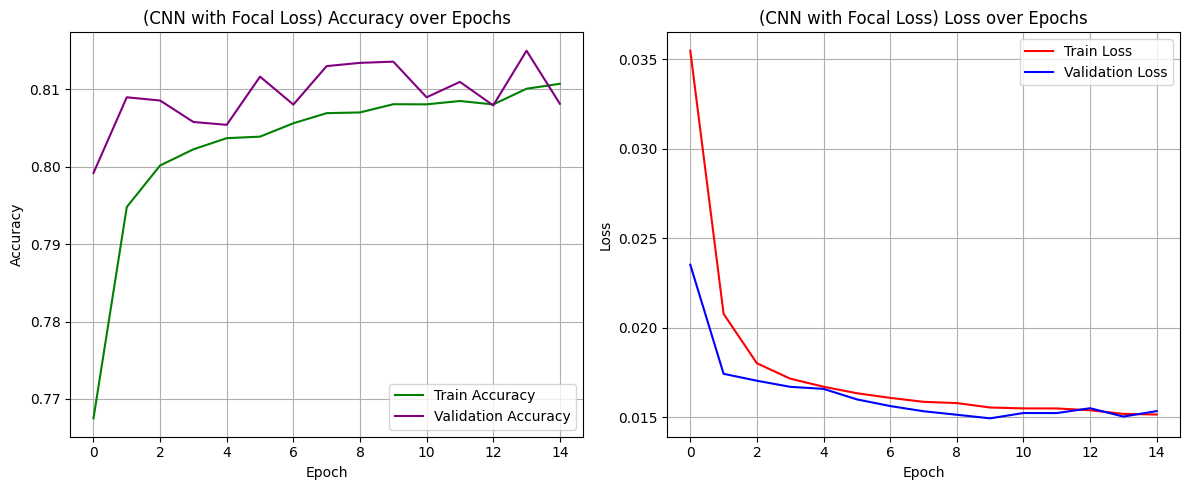

In [ ]:
# Accuracy & Loss Plot for Fine-Tuned CNN Model
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='purple')
plt.title('(CNN with Focal Loss) Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.title('(CNN with Focal Loss) Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

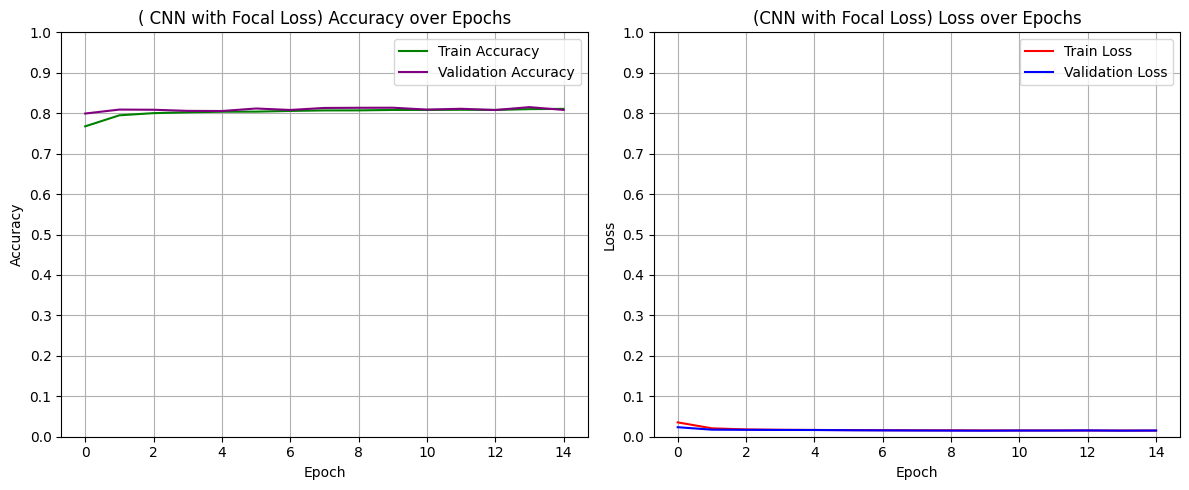

In [ ]:
# Accuracy & Loss Plot for CNN Model
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='purple')
plt.title('( CNN with Focal Loss) Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0.0, 1.0)
plt.yticks([i / 10 for i in range(11)])
plt.grid(True)
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.title('(CNN with Focal Loss) Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0.0, 1.0)
plt.yticks([i / 10 for i in range(11)])
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

747/747 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


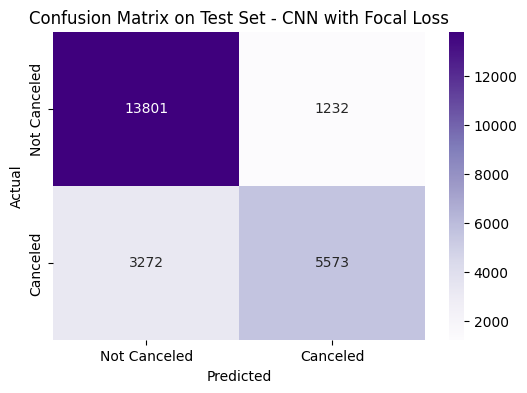


Classification Report for CNN with Focal Loss:
              precision    recall  f1-score   support

           0       0.81      0.92      0.86     15033
           1       0.82      0.63      0.71      8845

    accuracy                           0.81     23878
   macro avg       0.81      0.77      0.79     23878
weighted avg       0.81      0.81      0.81     23878



In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Predict
y_pred_val = (cnn_focal_model.predict(X_test_seq) > 0.5).astype("int32")

# Confusion Matrix
cm = confusion_matrix(y_test_arr, y_pred_val)
labels = ['Not Canceled', 'Canceled']

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix on Test Set - CNN with Focal Loss')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report for CNN with Focal Loss:")
print(classification_report(y_test_arr, y_pred_val))

747/747 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


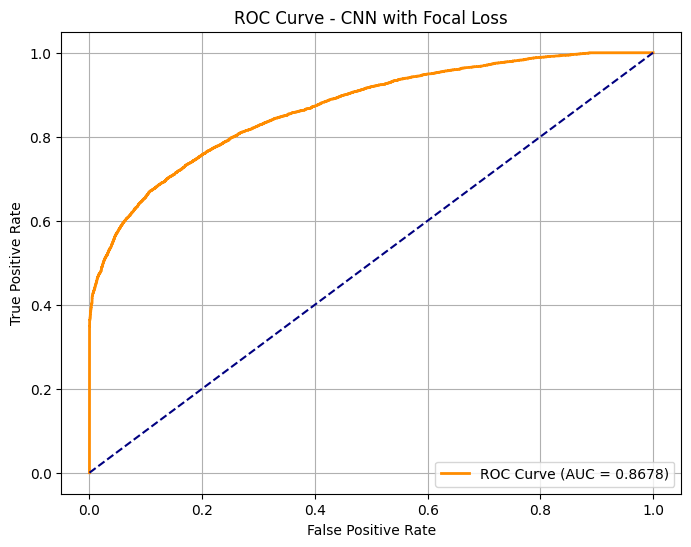

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities
y_pred_prob = cnn_focal_model.predict(X_test_seq).ravel()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_arr, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - CNN with Focal Loss')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
# Final Test Accuracy and Loss for  CNN Model
test_loss, test_accuracy = cnn_focal_model.evaluate(X_test_seq, y_test_arr, verbose=0)

print(f"\nFinal Test Accuracy (CNN with Focal Loss): {test_accuracy:.4f}")
print(f"Final Test Loss (CNN with Focal Loss): {test_loss:.4f}")


Final Test Accuracy (CNN with Focal Loss): 0.8114
Final Test Loss (CNN with Focal Loss): 0.0156


747/747 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


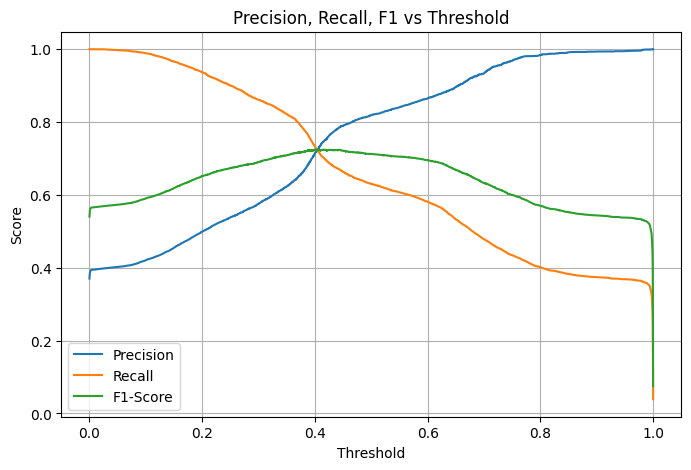

Best Threshold based on F1-Score: 0.4153


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score

# Predict probabilities
y_pred_prob = cnn_focal_model.predict(X_test_seq).ravel()

# Calculate precision, recall, thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test_arr, y_pred_prob)

# Compute F1 for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-6)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1-Score')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, F1 vs Threshold')
plt.grid(True)
plt.legend()
plt.show()


# Get best threshold (highest F1)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Best Threshold based on F1-Score: {best_threshold:.4f}")

y_pred = (y_pred_prob >= best_threshold).astype("int32")

747/747 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


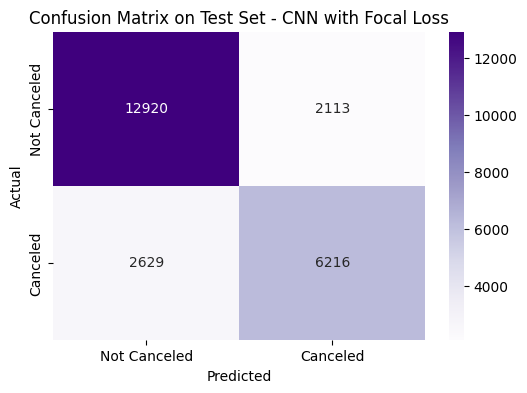


Classification Report for CNN with Focal Loss:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84     15033
           1       0.75      0.70      0.72      8845

    accuracy                           0.80     23878
   macro avg       0.79      0.78      0.78     23878
weighted avg       0.80      0.80      0.80     23878



In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Predict
y_pred_val = (cnn_focal_model.predict(X_test_seq) > 0.415).astype("int32")

# Confusion Matrix
cm = confusion_matrix(y_test_arr, y_pred_val)
labels = ['Not Canceled', 'Canceled']

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix on Test Set - CNN with Focal Loss')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report for CNN with Focal Loss:")
print(classification_report(y_test_arr, y_pred_val))

### CNN with Dropout, Batch Normalization and L2 Regularization - Tuning 2










In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, BatchNormalization, Dropout, GlobalAveragePooling1D, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Build the CNN with BatchNorm and L2
cnn_bn_l2_model = Sequential([
    Conv1D(128, kernel_size=3, activation='relu', input_shape=(X_train_seq.shape[1], 1)),
    BatchNormalization(),
    Dropout(0.3),

    Conv1D(64, kernel_size=3, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Conv1D(32, kernel_size=3, activation='relu'),
    GlobalAveragePooling1D(),

    Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

# Compile
cnn_bn_l2_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


cnn_bn_l2_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 67, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 67, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_58 (Dropout)            │ (None, 67, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 65, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 65, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_59 (Dropout)            │ (None, 65, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 63, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_23     │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_60 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,273 (133.88 KB)

 Trainable params: 33,889 (132.38 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
#Callbacks
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=2, factor=0.5, verbose=1)
]

# Train the model
history = cnn_bn_l2_model.fit(
    X_train_seq, y_train_final,
    validation_data=(X_val_seq, y_val),
    epochs=50,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - accuracy: 0.6578 - loss: 0.6357 - val_accuracy: 0.7604 - val_loss: 0.5314 - learning_rate: 5.0000e-04
Epoch 2/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step - accuracy: 0.7505 - loss: 0.5162 - val_accuracy: 0.7894 - val_loss: 0.4725 - learning_rate: 5.0000e-04
Epoch 3/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 26s 22ms/step - accuracy: 0.7767 - loss: 0.4763 - val_accuracy: 0.8007 - val_loss: 0.4448 - learning_rate: 5.0000e-04
Epoch 4/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - accuracy: 0.7844 - loss: 0.4605 - val_accuracy: 0.8025 - val_loss: 0.4409 - learning_rate: 5.0000e-04
Epoch 5/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - accuracy: 0.7891 - loss: 0.4552 - val_accuracy: 0.8037 - val_loss: 0.4325 - learning_rate: 5.0000e-04
Epoch 6/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - accuracy: 0.7899 - loss: 0.4518 - val_accuracy: 0.8048 - val_loss: 0.4294 - learning_rate: 5.0000e-04
Epoch 7/50
1194/1194 ━━━━━━━━━━━━━━━━━━━

In [ ]:
# Find Best Epoch Accuracy
best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_train_acc = history.history['accuracy'][best_epoch - 1]
best_train_loss = history.history['loss'][best_epoch - 1]
best_val_acc = history.history['val_accuracy'][best_epoch - 1]
best_val_loss = history.history['val_loss'][best_epoch - 1]

print(f"Best Epoch: {best_epoch}")
print(f"Training Accuracy: {best_train_acc:.4f}")
print(f"Training Loss: {best_train_loss:.4f}")
print(f"Validation Accuracy: {best_val_acc:.4f}")
print(f"Validation Loss: {best_val_loss:.4f}")

Best Epoch: 31
Training Accuracy: 0.8037
Training Loss: 0.4241
Validation Accuracy: 0.8120
Validation Loss: 0.4105


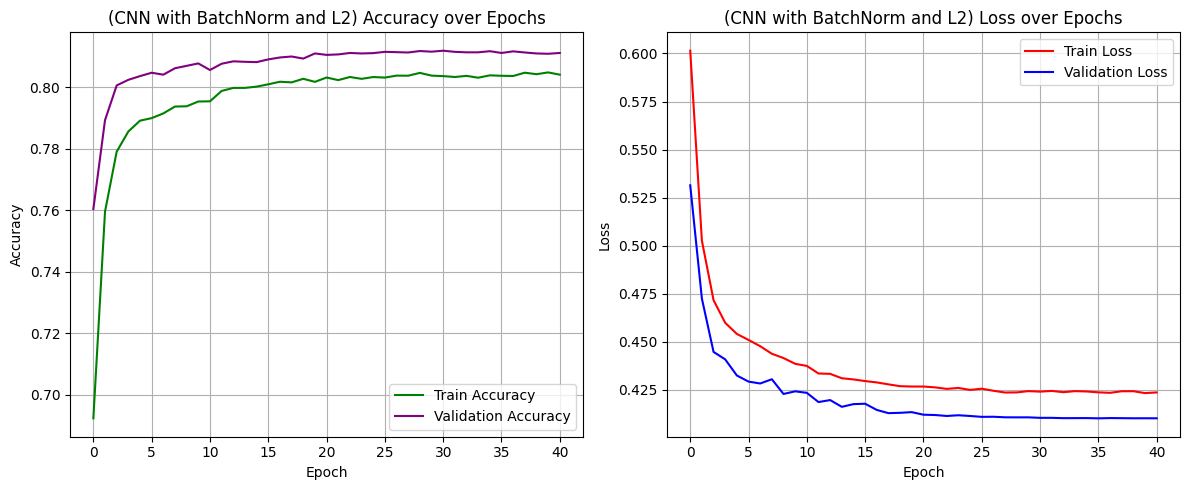

In [ ]:
# Accuracy & Loss Plot for Fine-Tuned CNN Model
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='purple')
plt.title('(CNN with BatchNorm and L2) Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.title('(CNN with BatchNorm and L2) Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

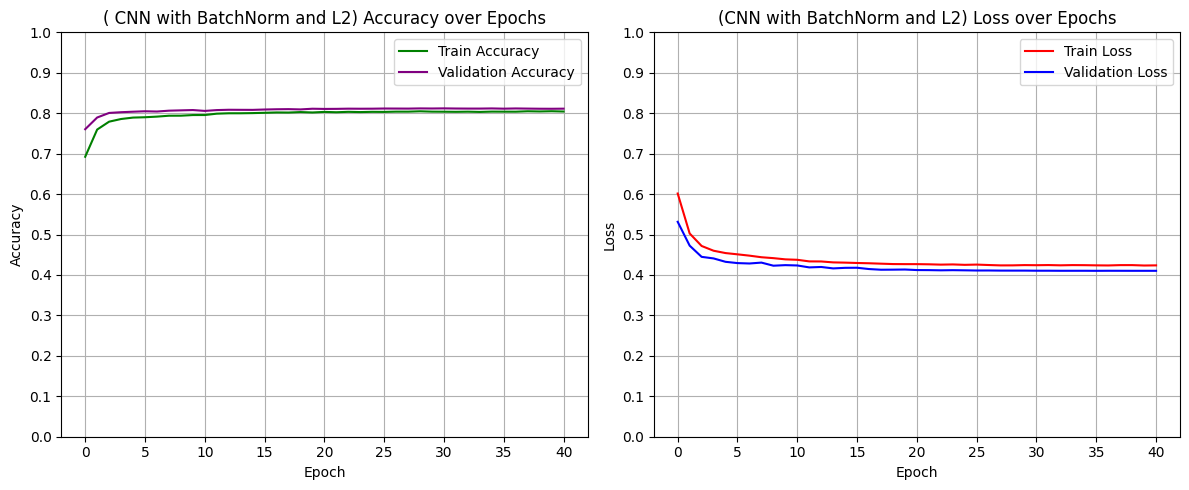

In [ ]:
# Accuracy & Loss Plot for CNN Model
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='purple')
plt.title('( CNN with BatchNorm and L2) Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0.0, 1.0)
plt.yticks([i / 10 for i in range(11)])
plt.grid(True)
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.title('(CNN with BatchNorm and L2) Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0.0, 1.0)
plt.yticks([i / 10 for i in range(11)])
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

747/747 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


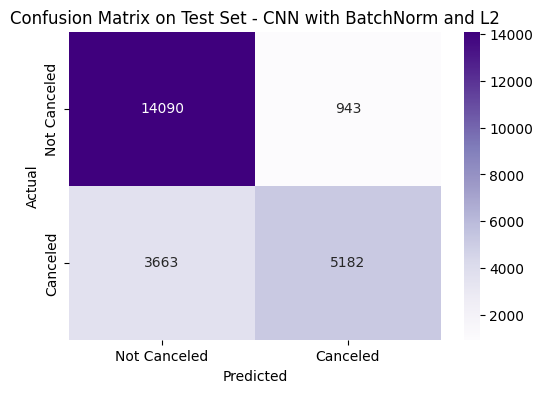


Classification Report for CNN with Batch Normalization and L2:
              precision    recall  f1-score   support

           0       0.79      0.94      0.86     15033
           1       0.85      0.59      0.69      8845

    accuracy                           0.81     23878
   macro avg       0.82      0.76      0.78     23878
weighted avg       0.81      0.81      0.80     23878



In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Predict
y_pred_val = (cnn_bn_l2_model.predict(X_test_seq) > 0.5).astype("int32")

# Confusion Matrix
cm = confusion_matrix(y_test_arr, y_pred_val)
labels = ['Not Canceled', 'Canceled']

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix on Test Set - CNN with BatchNorm and L2')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report for CNN with Batch Normalization and L2:")
print(classification_report(y_test_arr, y_pred_val))

747/747 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


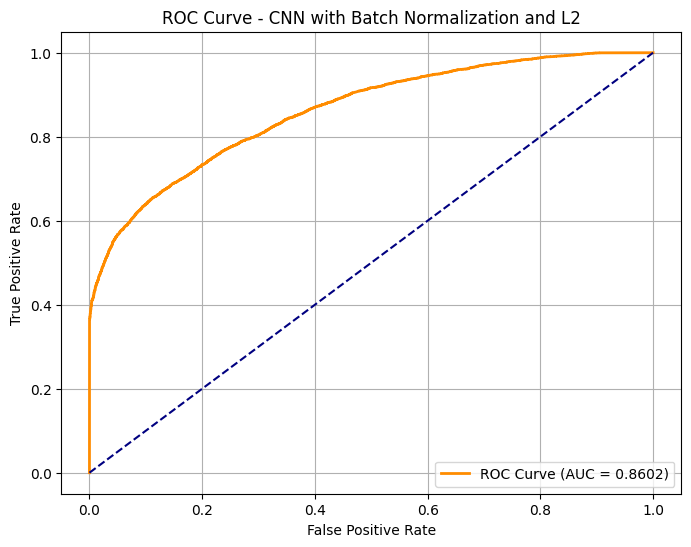

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities
y_pred_prob = cnn_bn_l2_model.predict(X_test_seq).ravel()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_arr, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - CNN with Batch Normalization and L2')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
# Final Test Accuracy and Loss for CNN Model
test_loss, test_accuracy = cnn_bn_l2_model.evaluate(X_test_seq, y_test_arr, verbose=0)

print(f"\nFinal Test Accuracy (CNN with Batch Normalization and L2): {test_accuracy:.4f}")
print(f"Final Test Loss (CNN with Batch Normalization and L2): {test_loss:.4f}")


Final Test Accuracy (CNN with Batch Normalization and L2): 0.8071
Final Test Loss (CNN with Batch Normalization and L2): 0.4150


747/747 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


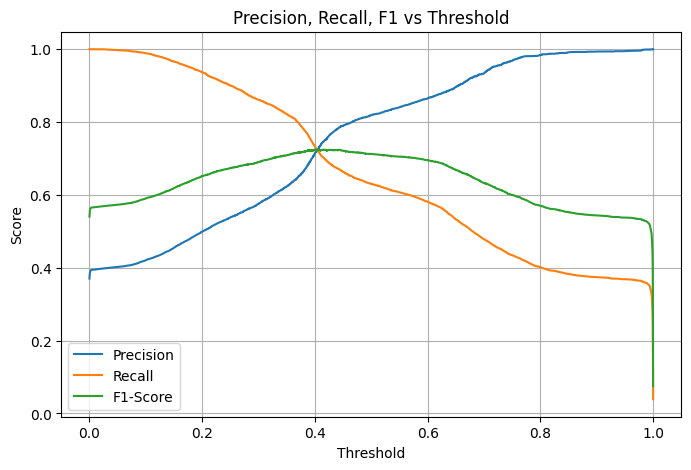

Best Threshold based on F1-Score: 0.4153


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score

# Predict probabilities
y_pred_prob = cnn_focal_model.predict(X_test_seq).ravel()

# Calculate precision, recall, thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test_arr, y_pred_prob)

# Compute F1 for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-6)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1-Score')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, F1 vs Threshold')
plt.grid(True)
plt.legend()
plt.show()

# Get best threshold (highest F1)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Best Threshold based on F1-Score: {best_threshold:.4f}")

y_pred = (y_pred_prob >= best_threshold).astype("int32")

747/747 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


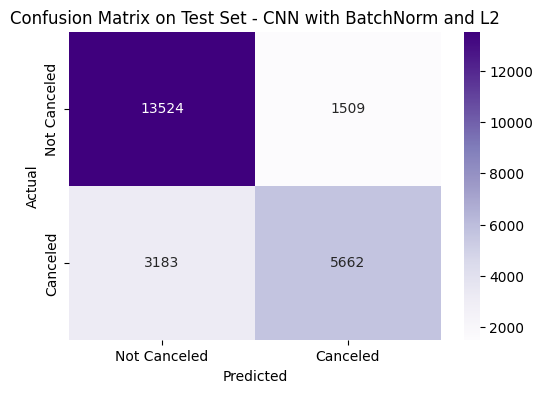


Classification Report for CNN with Batch Normalization and L2:
              precision    recall  f1-score   support

           0       0.81      0.90      0.85     15033
           1       0.79      0.64      0.71      8845

    accuracy                           0.80     23878
   macro avg       0.80      0.77      0.78     23878
weighted avg       0.80      0.80      0.80     23878



In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Predict
y_pred_val = (cnn_bn_l2_model.predict(X_test_seq) > 0.415).astype("int32")

# Confusion Matrix
cm = confusion_matrix(y_test_arr, y_pred_val)
labels = ['Not Canceled', 'Canceled']

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix on Test Set - CNN with BatchNorm and L2')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report for CNN with Batch Normalization and L2:")
print(classification_report(y_test_arr, y_pred_val))

### CNN with  Batch Normalization + L2 Regulation + focal_loss - Tuning 3


In [ ]:
import tensorflow as tf

def focal_loss(gamma=2., alpha=0.25):
    def focal(y_true, y_pred):
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1. - tf.keras.backend.epsilon())
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        return alpha * tf.pow(1 - p_t, gamma) * bce
    return focal


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, BatchNormalization, Dense, Flatten
from tensorflow.keras.regularizers import l2

# Build the CNN with BatchNorm and L2
cnn_bn_l2_focal_model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(1e-4), input_shape=(X_train_seq.shape[1], 1)),
    BatchNormalization(),

    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),

    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dense(1, activation='sigmoid')
])

# Complie
cnn_bn_l2_focal_model.compile(
    optimizer='adam',
    loss=focal_loss(gamma=2., alpha=0.25),
    metrics=['accuracy']
)

cnn_bn_l2_focal_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_11 (Conv1D)              │ (None, 67, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 67, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_12 (Conv1D)              │ (None, 65, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 65, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4160)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 128)            │       532,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 546,369 (2.08 MB)

 Trainable params: 545,857 (2.08 MB)

 Non-trainable params: 512 (2.00 KB)

In [ ]:
# Train the Model
history = cnn_bn_l2_focal_model.fit(
    X_train_seq, y_train_final,
    validation_data=(X_val_seq, y_val),
    epochs=50,
    batch_size=64,
    verbose=1
)

Epoch 1/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.7753 - loss: 0.0402 - val_accuracy: 0.8040 - val_loss: 0.0205
Epoch 2/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.8063 - loss: 0.0192 - val_accuracy: 0.8147 - val_loss: 0.0166
Epoch 3/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.8089 - loss: 0.0167 - val_accuracy: 0.8131 - val_loss: 0.0163
Epoch 4/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.8123 - loss: 0.0157 - val_accuracy: 0.7973 - val_loss: 0.0158
Epoch 5/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.8146 - loss: 0.0149 - val_accuracy: 0.8102 - val_loss: 0.0146
Epoch 6/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.8169 - loss: 0.0146 - val_accuracy: 0.8113 - val_loss: 0.0148
Epoch 7/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.8174 - loss: 0.0142 - val_accuracy: 0.8005 - val_loss: 0.0152
Epoch 8/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.8192 -

In [ ]:
# Find Best Epoch Accuracy
best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_train_acc = history.history['accuracy'][best_epoch - 1]
best_train_loss = history.history['loss'][best_epoch - 1]
best_val_acc = history.history['val_accuracy'][best_epoch - 1]
best_val_loss = history.history['val_loss'][best_epoch - 1]

print(f"Best Epoch: {best_epoch}")
print(f"Training Accuracy: {best_train_acc:.4f}")
print(f"Training Loss: {best_train_loss:.4f}")
print(f"Validation Accuracy: {best_val_acc:.4f}")
print(f"Validation Loss: {best_val_loss:.4f}")

Best Epoch: 45
Training Accuracy: 0.8252
Training Loss: 0.0128
Validation Accuracy: 0.8247
Validation Loss: 0.0128


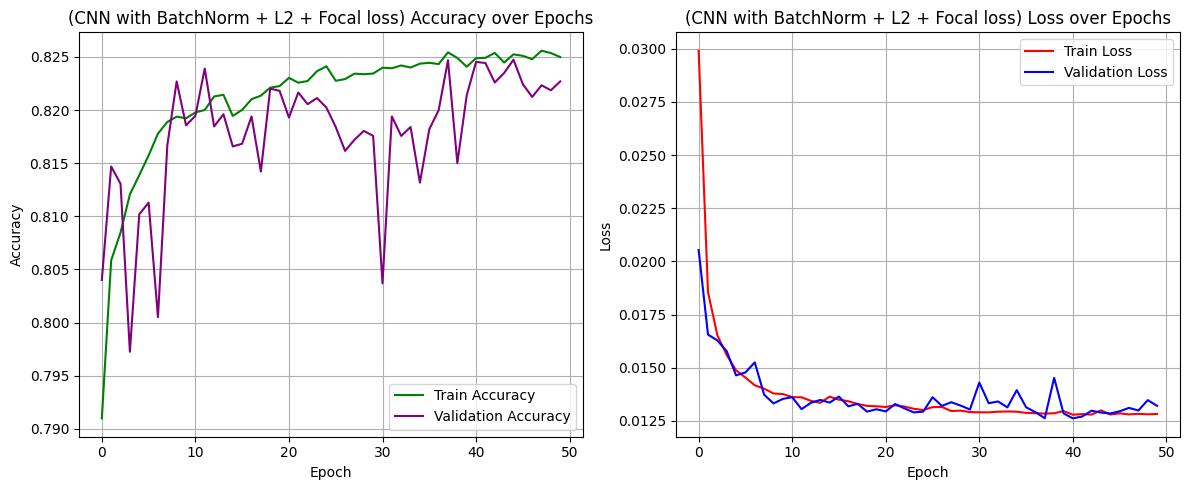

In [ ]:
# Accuracy & Loss Plot for Fine-Tuned CNN Model
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='purple')
plt.title('(CNN with BatchNorm + L2 + Focal loss) Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.title('(CNN with BatchNorm + L2 + Focal loss) Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

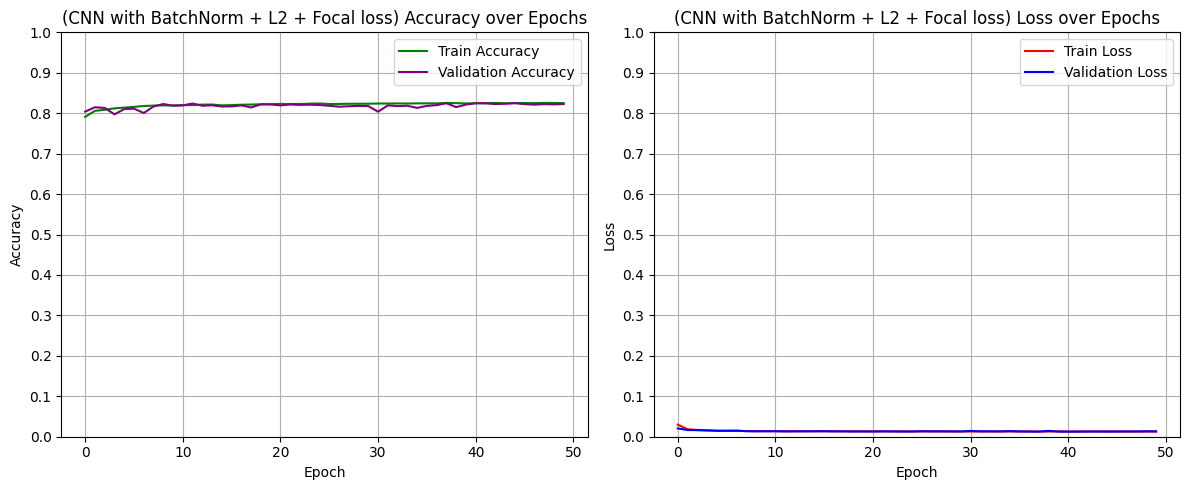

In [ ]:
# Accuracy & Loss Plot for Fine-Tuned CNN Model
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='purple')
plt.title('(CNN with BatchNorm + L2 + Focal loss) Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0.0, 1.0)
plt.yticks([i / 10 for i in range(11)])
plt.grid(True)
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.title('(CNN with BatchNorm + L2 + Focal loss) Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0.0, 1.0)
plt.yticks([i / 10 for i in range(11)])
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

747/747 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


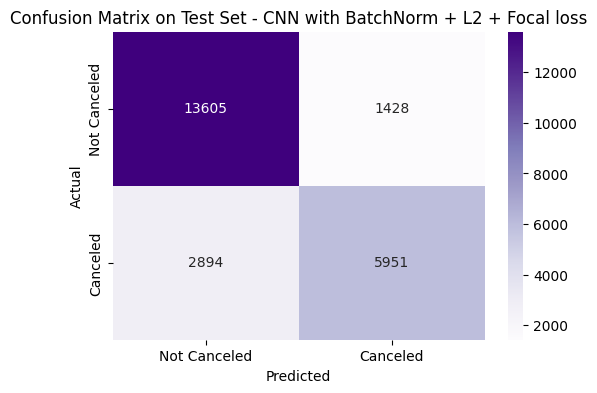


Classification Report for CNN with Batch Normalization + L2 + Focal loss:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86     15033
           1       0.81      0.67      0.73      8845

    accuracy                           0.82     23878
   macro avg       0.82      0.79      0.80     23878
weighted avg       0.82      0.82      0.82     23878



In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Predict
y_pred_val = (cnn_bn_l2_focal_model.predict(X_test_seq) > 0.5).astype("int32")

# Confusion Matrix
cm = confusion_matrix(y_test_arr, y_pred_val)
labels = ['Not Canceled', 'Canceled']

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix on Test Set - CNN with BatchNorm + L2 + Focal loss')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report for CNN with Batch Normalization + L2 + Focal loss:")
print(classification_report(y_test_arr, y_pred_val))

747/747 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


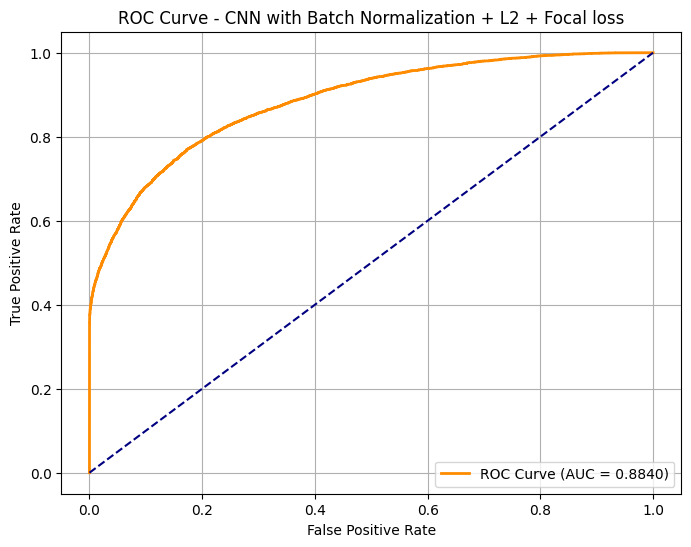

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities
y_pred_prob = cnn_bn_l2_focal_model.predict(X_test_seq).ravel()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_arr, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - CNN with Batch Normalization + L2 + Focal loss')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
# Final Test Accuracy and Loss for CNN Model
test_loss, test_accuracy = cnn_bn_l2_focal_model.evaluate(X_test_seq, y_test_arr, verbose=0)

print(f"\nFinal Test Accuracy (CNN with Batch Normalization + L2 + Focal loss): {test_accuracy:.4f}")
print(f"Final Test Loss (CNN with Batch Normalization + L2 + Focal loss): {test_loss:.4f}")


Final Test Accuracy (CNN with Batch Normalization + L2 + Focal loss): 0.8190
Final Test Loss (CNN with Batch Normalization + L2 + Focal loss): 0.0141


747/747 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


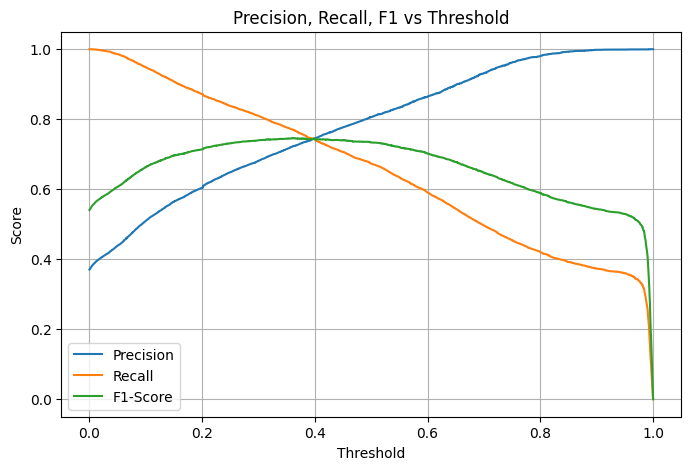

Best Threshold based on F1-Score: 0.3623


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score

# Predict probabilities
y_pred_prob = cnn_bn_l2_focal_model.predict(X_test_seq).ravel()

# Calculate precision, recall, thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test_arr, y_pred_prob)

# Compute F1 for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-6)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1-Score')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, F1 vs Threshold')
plt.grid(True)
plt.legend()
plt.show()

# Get best threshold (highest F1)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Best Threshold based on F1-Score: {best_threshold:.4f}")

y_pred = (y_pred_prob >= best_threshold).astype("int32")

747/747 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


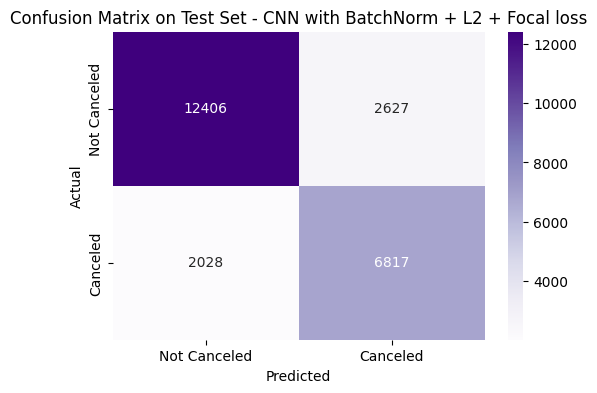


Classification Report for CNN with Batch Normalization + L2 + Focal loss:
              precision    recall  f1-score   support

           0       0.86      0.83      0.84     15033
           1       0.72      0.77      0.75      8845

    accuracy                           0.81     23878
   macro avg       0.79      0.80      0.79     23878
weighted avg       0.81      0.81      0.81     23878



In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Predict
y_pred_val = (cnn_bn_l2_focal_model.predict(X_test_seq) > 0.36).astype("int32")

# Confusion Matrix
cm = confusion_matrix(y_test_arr, y_pred_val)
labels = ['Not Canceled', 'Canceled']

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix on Test Set - CNN with BatchNorm + L2 + Focal loss')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report for CNN with Batch Normalization + L2 + Focal loss:")
print(classification_report(y_test_arr, y_pred_val))

### Optimized CNN with  Batch Normalization + L2 Regulation + focal_loss + Dropout - Tuning 4



In [ ]:
import tensorflow as tf

# Define focal loss
def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1. - tf.keras.backend.epsilon())
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        return alpha * tf.pow(1 - p_t, gamma) * bce
    return loss

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten, BatchNormalization, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Define model
cnn_opt_model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', padding='same', kernel_regularizer=l2(1e-4), input_shape=(X_train_seq.shape[1], 1)),
    BatchNormalization(),
    Dropout(0.3),

    Conv1D(128, kernel_size=3, activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),

    Flatten(),
    Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

cnn_opt_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=focal_loss(),
    metrics=['accuracy']
)

cnn_opt_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_13 (Conv1D)              │ (None, 69, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 69, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_61 (Dropout)            │ (None, 69, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_14 (Conv1D)              │ (None, 69, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 69, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_62 (Dropout)            │ (None, 69, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8832)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 64)             │       565,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_63 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,105 (2.25 MB)

 Trainable params: 590,721 (2.25 MB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the Model
history = cnn_opt_model.fit(
    X_train_seq, y_train_final,
    validation_data=(X_val_seq, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - accuracy: 0.7424 - loss: 0.0443 - val_accuracy: 0.7956 - val_loss: 0.0342
Epoch 2/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step - accuracy: 0.7828 - loss: 0.0346 - val_accuracy: 0.8000 - val_loss: 0.0298
Epoch 3/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step - accuracy: 0.7914 - loss: 0.0302 - val_accuracy: 0.8059 - val_loss: 0.0261
Epoch 4/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 27s 23ms/step - accuracy: 0.7939 - loss: 0.0266 - val_accuracy: 0.8060 - val_loss: 0.0233
Epoch 5/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 27s 23ms/step - accuracy: 0.7973 - loss: 0.0238 - val_accuracy: 0.8103 - val_loss: 0.0213
Epoch 6/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step - accuracy: 0.8027 - loss: 0.0218 - val_accuracy: 0.8154 - val_loss: 0.0192
Epoch 7/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 27s 23ms/step - accuracy: 0.8057 - loss: 0.0202 - val_accuracy: 0.8181 - val_loss: 0.0179
Epoch 8/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 27s 23ms/step - accuracy: 0.8092 -

In [ ]:
# Find Best Epoch Accuracy
best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_train_acc = history.history['accuracy'][best_epoch - 1]
best_train_loss = history.history['loss'][best_epoch - 1]
best_val_acc = history.history['val_accuracy'][best_epoch - 1]
best_val_loss = history.history['val_loss'][best_epoch - 1]

print(f"Best Epoch: {best_epoch}")
print(f"Training Accuracy: {best_train_acc:.4f}")
print(f"Training Loss: {best_train_loss:.4f}")
print(f"Validation Accuracy: {best_val_acc:.4f}")
print(f"Validation Loss: {best_val_loss:.4f}")

Best Epoch: 47
Training Accuracy: 0.8250
Training Loss: 0.0135
Validation Accuracy: 0.8340
Validation Loss: 0.0125


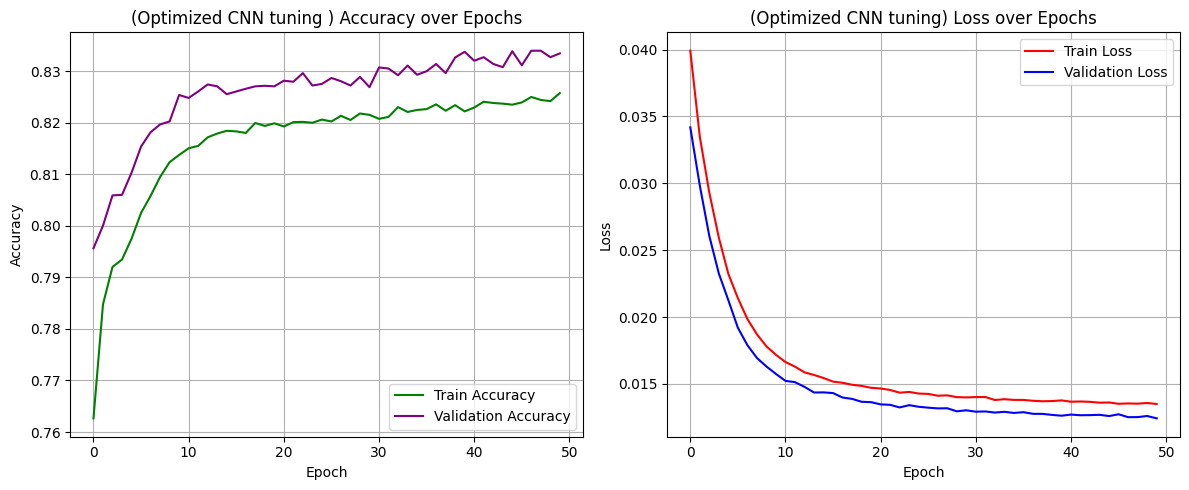

In [ ]:
# Accuracy & Loss Plot for Fine-Tuned CNN Model
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='purple')
plt.title('(Optimized CNN tuning ) Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.title('(Optimized CNN tuning) Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

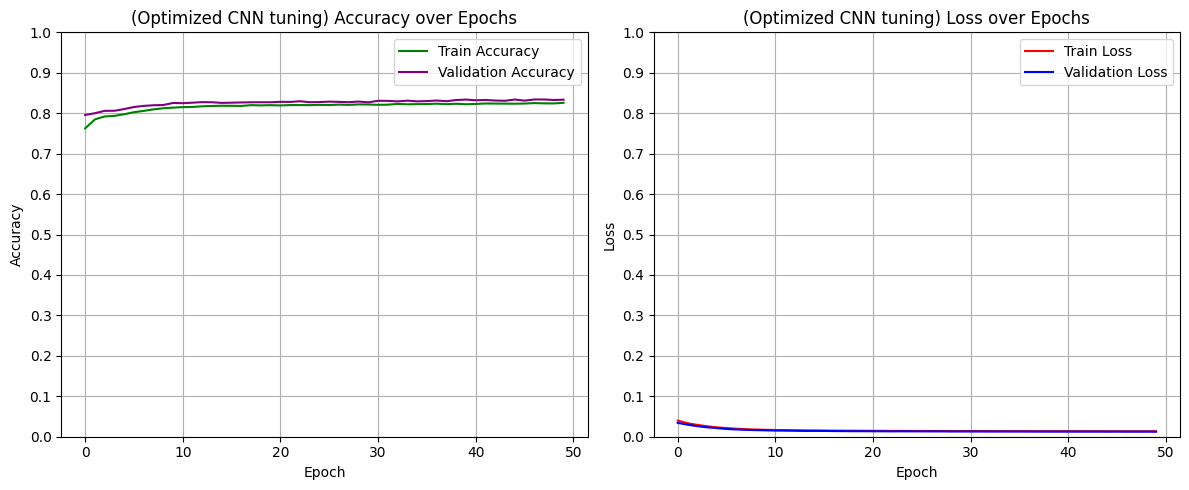

In [ ]:
# Accuracy & Loss Plot for Fine-Tuned CNN Model
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='purple')
plt.title('(Optimized CNN tuning) Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0.0, 1.0)
plt.yticks([i / 10 for i in range(11)])
plt.grid(True)
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.title('(Optimized CNN tuning) Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0.0, 1.0)
plt.yticks([i / 10 for i in range(11)])
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

747/747 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


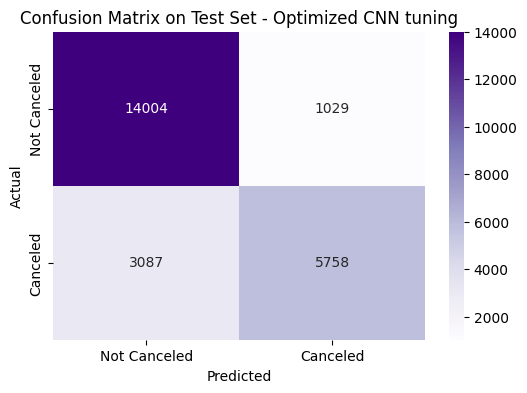


Classification Report for Optimized CNN tuning:
              precision    recall  f1-score   support

           0       0.82      0.93      0.87     15033
           1       0.85      0.65      0.74      8845

    accuracy                           0.83     23878
   macro avg       0.83      0.79      0.80     23878
weighted avg       0.83      0.83      0.82     23878



In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Predict
y_pred_val = (cnn_opt_model.predict(X_test_seq) > 0.5).astype("int32")

# Confusion Matrix
cm = confusion_matrix(y_test_arr, y_pred_val)
labels = ['Not Canceled', 'Canceled']

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix on Test Set - Optimized CNN tuning')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report for Optimized CNN tuning:")
print(classification_report(y_test_arr, y_pred_val))

747/747 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


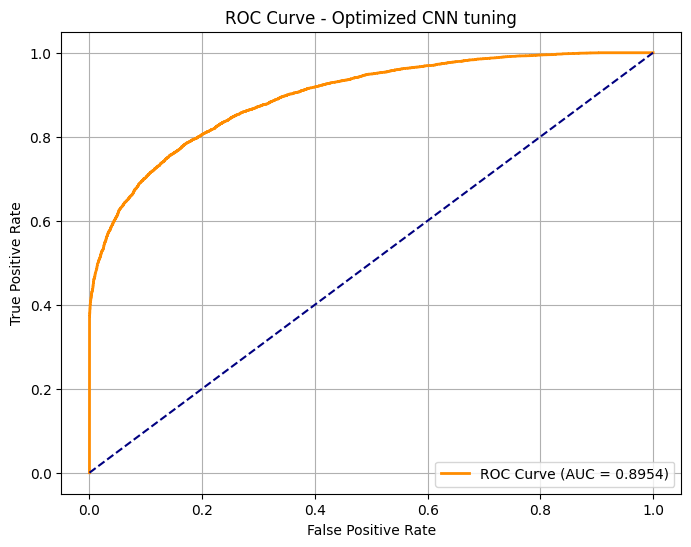

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities
y_pred_prob = cnn_opt_model.predict(X_test_seq).ravel()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_arr, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Optimized CNN tuning')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
# Final Test Accuracy and Loss for CNN Model
test_loss, test_accuracy = cnn_opt_model.evaluate(X_test_seq, y_test_arr, verbose=0)

print(f"\nFinal Test Accuracy (Optimized CNN tuning): {test_accuracy:.4f}")
print(f"Final Test Loss (Optimized CNN tuning): {test_loss:.4f}")


Final Test Accuracy (Optimized CNN tuning): 0.8276
Final Test Loss (Optimized CNN tuning): 0.0133


747/747 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


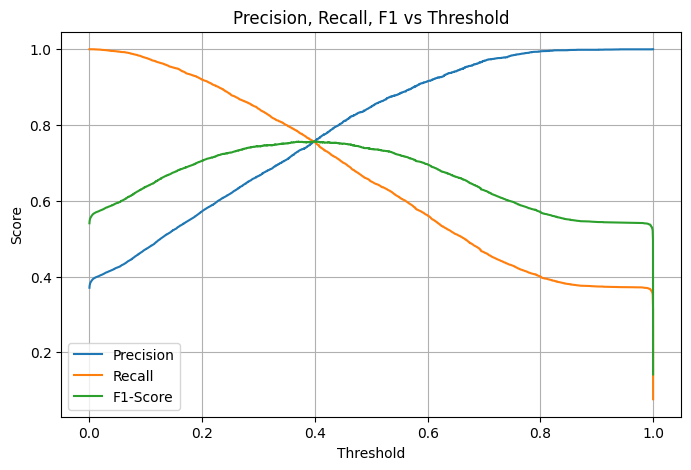

Best Threshold based on F1-Score: 0.3973


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score

# Predict probabilities
y_pred_prob = cnn_opt_model.predict(X_test_seq).ravel()

# Calculate precision, recall, thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test_arr, y_pred_prob)

# Compute F1 for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-6)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1-Score')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, F1 vs Threshold')
plt.grid(True)
plt.legend()
plt.show()

# Get best threshold (highest F1)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Best Threshold based on F1-Score: {best_threshold:.4f}")

y_pred = (y_pred_prob >= best_threshold).astype("int32")

747/747 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


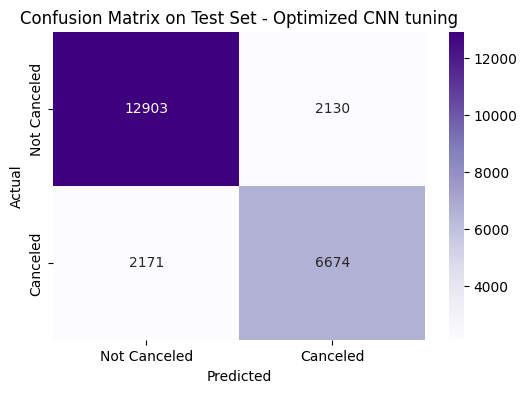


Classification Report for Optimized CNN tuning:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86     15033
           1       0.76      0.75      0.76      8845

    accuracy                           0.82     23878
   macro avg       0.81      0.81      0.81     23878
weighted avg       0.82      0.82      0.82     23878



In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Predict
y_pred_val = (cnn_opt_model.predict(X_test_seq) > 0.40).astype("int32")

# Confusion Matrix
cm = confusion_matrix(y_test_arr, y_pred_val)
labels = ['Not Canceled', 'Canceled']

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix on Test Set - Optimized CNN tuning')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report for Optimized CNN tuning:")
print(classification_report(y_test_arr, y_pred_val))

## **DNN**

### DNN Base Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Base DNN model
dnn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_final.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile
dnn_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
dnn_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_81 (Dense)                │ (None, 64)             │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,593 (25.75 KB)

 Trainable params: 6,593 (25.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the Model
history = dnn_model.fit(X_train_final, y_train_final,
                        validation_data=(X_val, y_val),
                        epochs=30, batch_size=128,
                        verbose=1)


Epoch 1/30
597/597 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7484 - loss: 0.5184 - val_accuracy: 0.8006 - val_loss: 0.4374
Epoch 2/30
597/597 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7995 - loss: 0.4346 - val_accuracy: 0.8043 - val_loss: 0.4214
Epoch 3/30
597/597 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8027 - loss: 0.4194 - val_accuracy: 0.8068 - val_loss: 0.4114
Epoch 4/30
597/597 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8074 - loss: 0.4090 - val_accuracy: 0.8110 - val_loss: 0.4048
Epoch 5/30
597/597 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8113 - loss: 0.4016 - val_accuracy: 0.8129 - val_loss: 0.3999
Epoch 6/30
597/597 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8145 - loss: 0.3958 - val_accuracy: 0.8160 - val_loss: 0.3961
Epoch 7/30
597/597 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8175 - loss: 0.3911 - val_accuracy: 0.8182 - val_loss: 0.3932
Epoch 8/30
597/597 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8200 - loss: 0.3871 - val_accuracy: 0.

In [ ]:
# Find Best Epoch
best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_train_acc = history.history['accuracy'][best_epoch - 1]
best_train_loss = history.history['loss'][best_epoch - 1]
best_val_acc = history.history['val_accuracy'][best_epoch - 1]
best_val_loss = history.history['val_loss'][best_epoch - 1]

print("\nBest Epoch and Results (DNN Base Model):")
print(f"Best Epoch: {best_epoch}")
print(f"Training Accuracy: {best_train_acc:.4f}")
print(f"Training Loss: {best_train_loss:.4f}")
print(f"Validation Accuracy: {best_val_acc:.4f}")
print(f"Validation Loss: {best_val_loss:.4f}")


Best Epoch and Results (DNN Base Model):
Best Epoch: 29
Training Accuracy: 0.8366
Training Loss: 0.3534
Validation Accuracy: 0.8295
Validation Loss: 0.3700


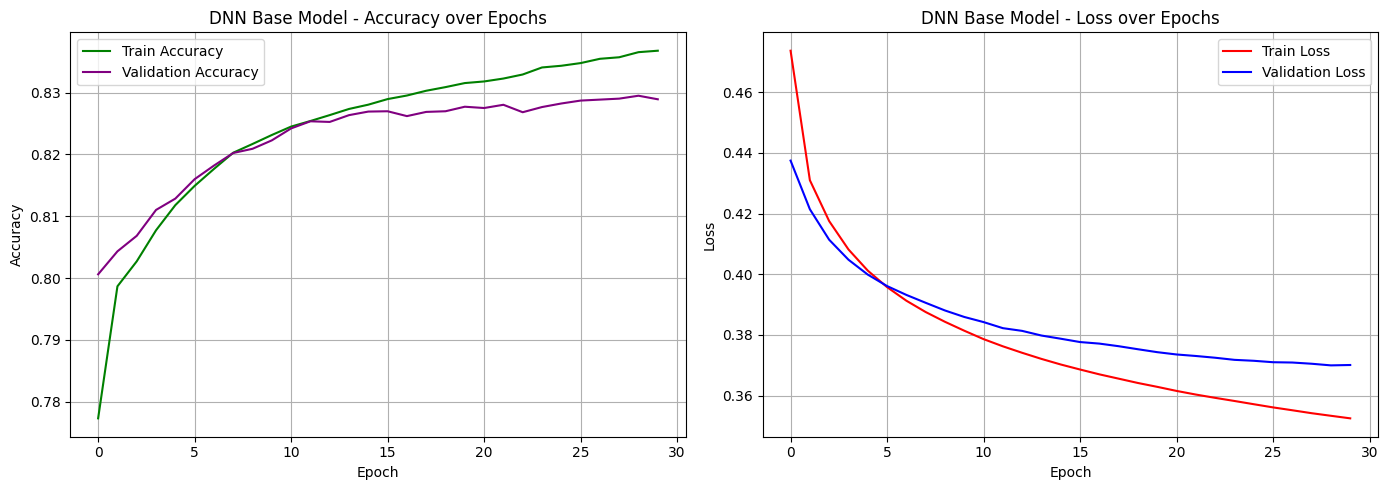

In [ ]:
# Plot Training & Validation Graphs
plt.figure(figsize=(14,5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy',  color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='purple')
plt.title('DNN Base Model - Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss',  color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.title('DNN Base Model - Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

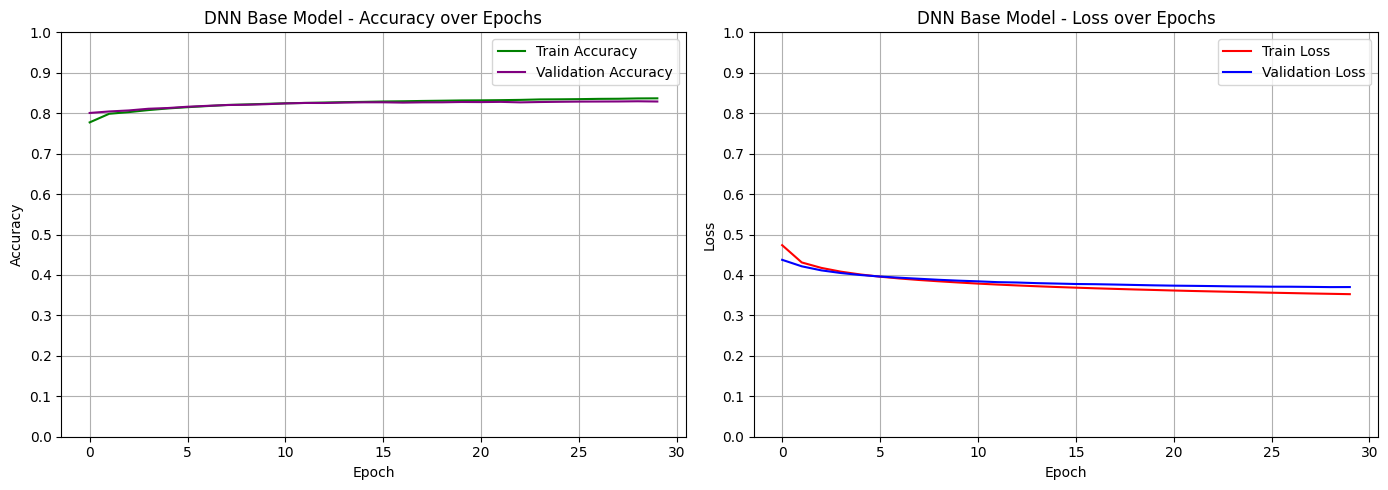

In [ ]:
# Plot Training & Validation Graphs
plt.figure(figsize=(14,5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy',  color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='purple')
plt.title('DNN Base Model - Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0.0, 1.0)
plt.yticks([i/10 for i in range(11)])
plt.grid(True)
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss',  color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.title('DNN Base Model - Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0.0, 1.0)
plt.yticks([i/10 for i in range(11)])
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

747/747 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


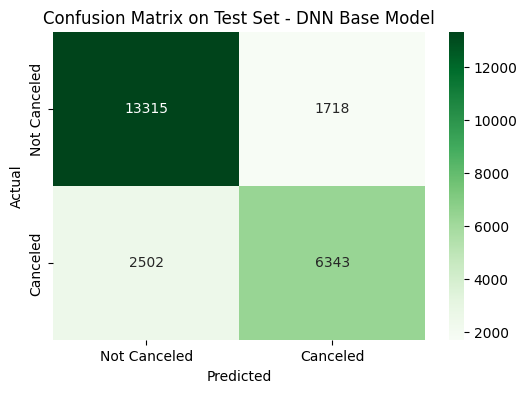


Classification Report for DNN Base Model:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86     15033
           1       0.79      0.72      0.75      8845

    accuracy                           0.82     23878
   macro avg       0.81      0.80      0.81     23878
weighted avg       0.82      0.82      0.82     23878



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on test set
y_pred_val = (dnn_model.predict(X_test) > 0.5).astype("int32")

# Confusion Matrix
cm_dnn = confusion_matrix(y_test, y_pred_val)
labels = ['Not Canceled', 'Canceled']

plt.figure(figsize=(6,4))
sns.heatmap(cm_dnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix on Test Set - DNN Base Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report for DNN Base Model:")
print(classification_report(y_test, y_pred_val))

747/747 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


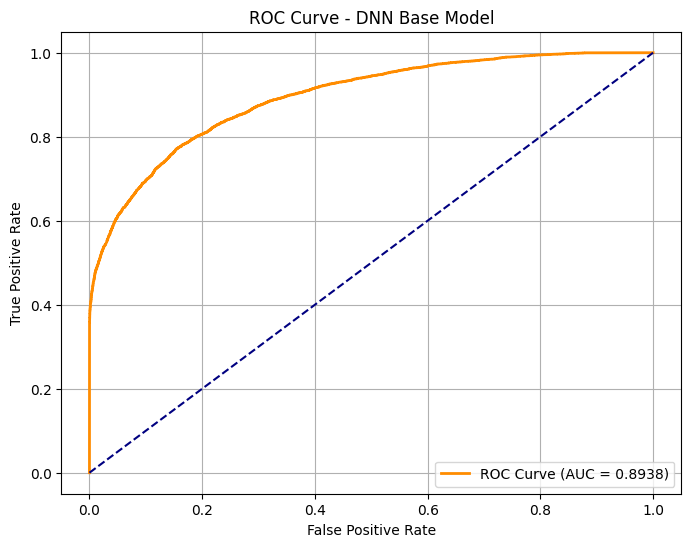

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities using correct input
y_pred_prob = dnn_model.predict(X_test).ravel()  # DNN uses 2D X_test

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - DNN Base Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
# Final Test Accuracy and Loss
test_loss, test_accuracy = dnn_model.evaluate(X_test, y_test, verbose=0)

print(f"\nFinal Test Accuracy (DNN Base Model): {test_accuracy:.4f}")
print(f"Final Test Loss (DNN Base Model): {test_loss:.4f}")


Final Test Accuracy (DNN Base Model): 0.8233
Final Test Loss (DNN Base Model): 0.3751


747/747 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


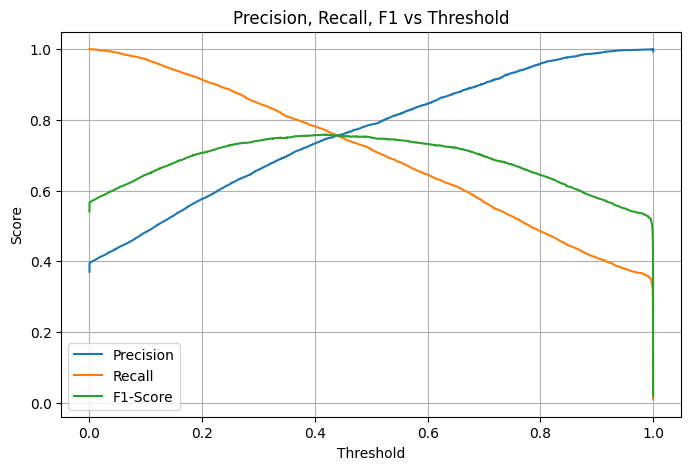

Best Threshold based on F1-Score: 0.4202


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score

# Predict probabilities
y_pred_prob = dnn_model.predict(X_test).ravel()

# Calculate precision, recall, thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test_arr, y_pred_prob)

# Compute F1 for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-6)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1-Score')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, F1 vs Threshold')
plt.grid(True)
plt.legend()
plt.show()

# Get best threshold (highest F1)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Best Threshold based on F1-Score: {best_threshold:.4f}")

y_pred = (y_pred_prob >= best_threshold).astype("int32")

747/747 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


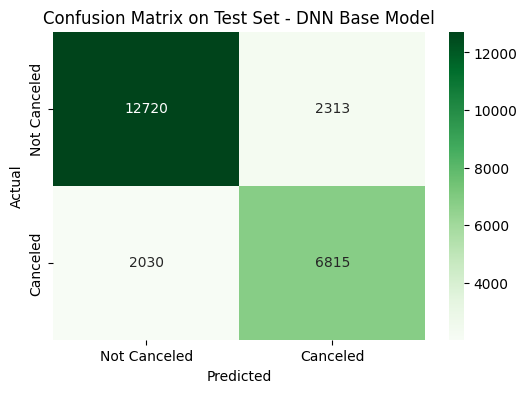


Classification Report for DNN Base Model:
              precision    recall  f1-score   support

           0       0.86      0.85      0.85     15033
           1       0.75      0.77      0.76      8845

    accuracy                           0.82     23878
   macro avg       0.80      0.81      0.81     23878
weighted avg       0.82      0.82      0.82     23878



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Predict
y_pred_val = (dnn_model.predict(X_test) > 0.42).astype("int32")

# Confusion Matrix
cm_dnn = confusion_matrix(y_test, y_pred_val)
labels = ['Not Canceled', 'Canceled']

plt.figure(figsize=(6,4))
sns.heatmap(cm_dnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix on Test Set - DNN Base Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report for DNN Base Model:")
print(classification_report(y_test, y_pred_val))

### DNN with Batch Normalization and Dropout - Tuning 1

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define tuned DNN model
dnn_bn_model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train_final.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

# Compile with lower learning rate
dnn_bn_model.compile(optimizer=Adam(learning_rate=0.0005),
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

dnn_bn_model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_109 (Dense)               │ (None, 512)            │        35,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_79 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_110 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_80 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_111 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_81 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_112 (Dense)               │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,777 (796.00 KB)

 Trainable params: 201,985 (789.00 KB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
# Callbacks
callbacks = [
    EarlyStopping(patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, verbose=1)
]
# Train the Model
history_bn = dnn_bn_model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=50, batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.7386 - loss: 0.5333 - val_accuracy: 0.8018 - val_loss: 0.4284 - learning_rate: 5.0000e-04
Epoch 2/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.7890 - loss: 0.4463 - val_accuracy: 0.8057 - val_loss: 0.4156 - learning_rate: 5.0000e-04
Epoch 3/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.7941 - loss: 0.4318 - val_accuracy: 0.8111 - val_loss: 0.4061 - learning_rate: 5.0000e-04
Epoch 4/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8000 - loss: 0.4205 - val_accuracy: 0.8149 - val_loss: 0.3987 - learning_rate: 5.0000e-04
Epoch 5/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8029 - loss: 0.4131 - val_accuracy: 0.8204 - val_loss: 0.3914 - learning_rate: 5.0000e-04
Epoch 6/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8083 - loss: 0.4061 - val_accuracy: 0.8230 - val_loss: 0.3851 - learning_rate: 5.0000e-04
Epoch 7/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/st

In [ ]:
# Find Best Epoch
best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_train_acc = history.history['accuracy'][best_epoch - 1]
best_train_loss = history.history['loss'][best_epoch - 1]
best_val_acc = history.history['val_accuracy'][best_epoch - 1]
best_val_loss = history.history['val_loss'][best_epoch - 1]

print("\nBest Epoch and Results (DNN with BatchNorm):")
print(f"Best Epoch: {best_epoch}")
print(f"Training Accuracy: {best_train_acc:.4f}")
print(f"Training Loss: {best_train_loss:.4f}")
print(f"Validation Accuracy: {best_val_acc:.4f}")
print(f"Validation Loss: {best_val_loss:.4f}")


Best Epoch and Results (DNN with BatchNorm):
Best Epoch: 29
Training Accuracy: 0.8366
Training Loss: 0.3534
Validation Accuracy: 0.8295
Validation Loss: 0.3700


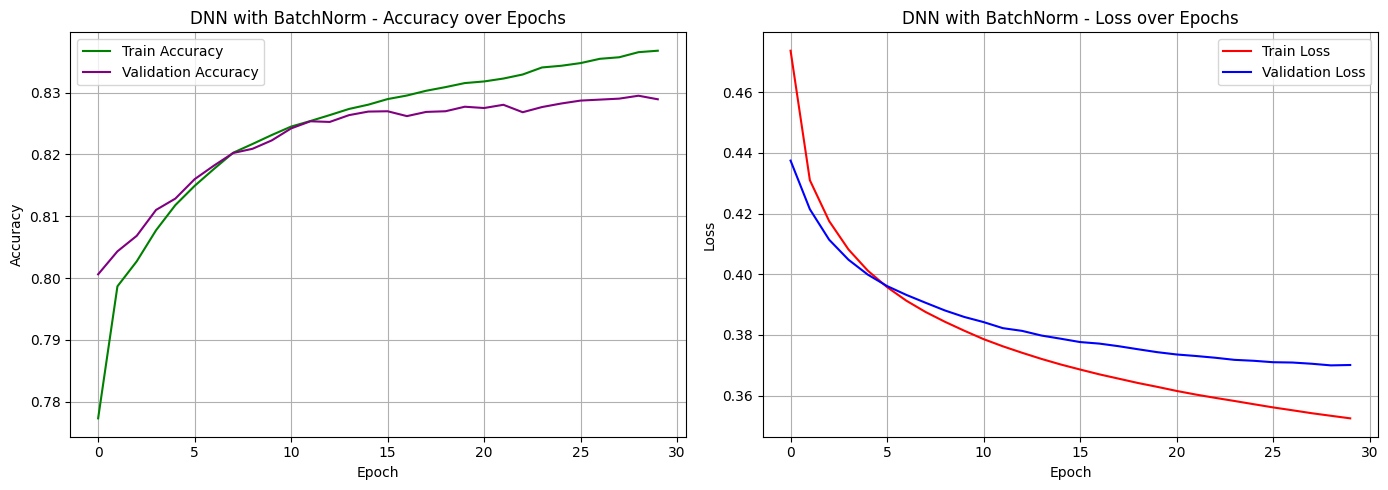

In [ ]:
# Plot Training & Validation Graphs
plt.figure(figsize=(14,5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy',  color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='purple')
plt.title('DNN with BatchNorm - Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss',  color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.title('DNN with BatchNorm - Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

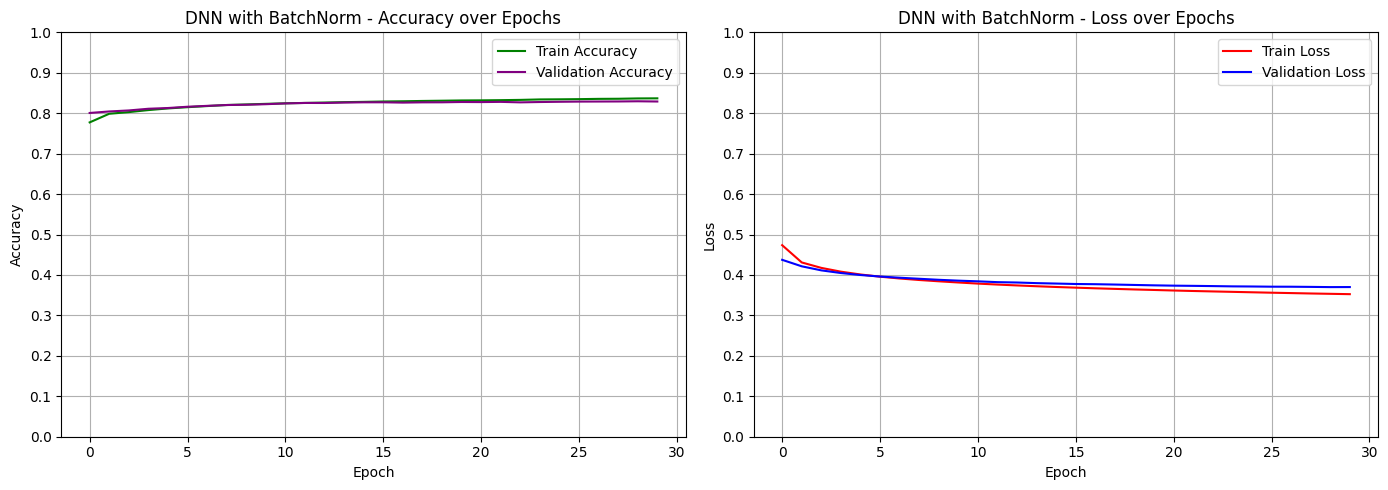

In [ ]:
# Plot Training & Validation Graphs
plt.figure(figsize=(14,5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy',  color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='purple')
plt.title('DNN with BatchNorm - Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0.0, 1.0)
plt.yticks([i/10 for i in range(11)])
plt.grid(True)
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss',  color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.title('DNN with BatchNorm - Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0.0, 1.0)
plt.yticks([i/10 for i in range(11)])
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

747/747 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


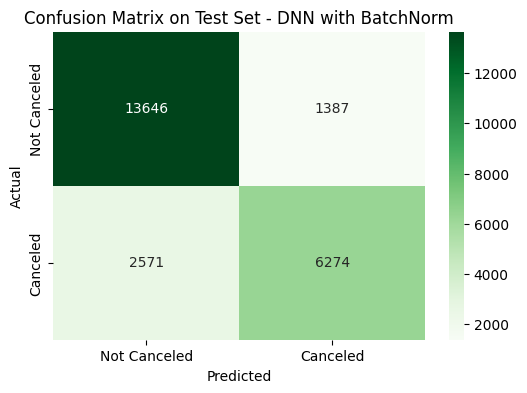


Classification Report for DNN with BatchNorm:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87     15033
           1       0.82      0.71      0.76      8845

    accuracy                           0.83     23878
   macro avg       0.83      0.81      0.82     23878
weighted avg       0.83      0.83      0.83     23878



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on test set
y_pred_val = (dnn_bn_model.predict(X_test) > 0.5).astype("int32")

# Confusion Matrix
cm_dnn = confusion_matrix(y_test, y_pred_val)
labels = ['Not Canceled', 'Canceled']

plt.figure(figsize=(6,4))
sns.heatmap(cm_dnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix on Test Set - DNN with BatchNorm')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report for DNN with BatchNorm:")
print(classification_report(y_test, y_pred_val))

747/747 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


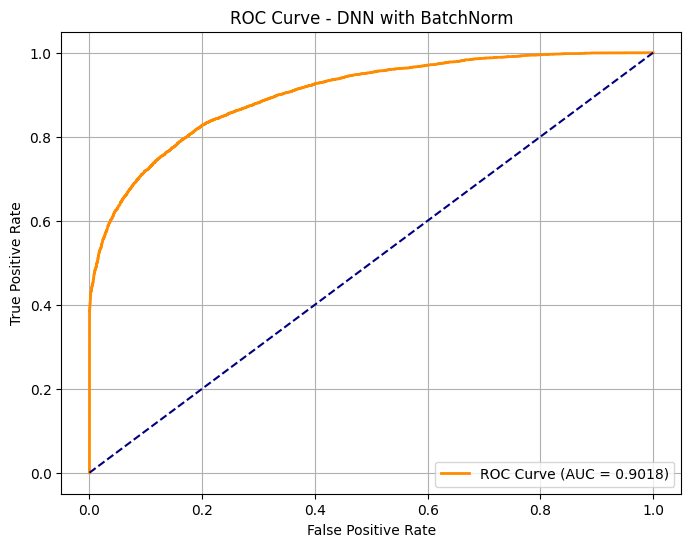

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities using correct input
y_pred_prob = dnn_bn_model.predict(X_test).ravel()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - DNN with BatchNorm')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
# Final Test Accuracy and Loss
test_loss, test_accuracy = dnn_bn_model.evaluate(X_test, y_test, verbose=0)

print(f"\nFinal Test Accuracy (DNN with BatchNorm): {test_accuracy:.4f}")
print(f"Final Test Loss (DNN with BatchNorm): {test_loss:.4f}")


Final Test Accuracy (DNN with BatchNorm): 0.8342
Final Test Loss (DNN with BatchNorm): 0.3610


747/747 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


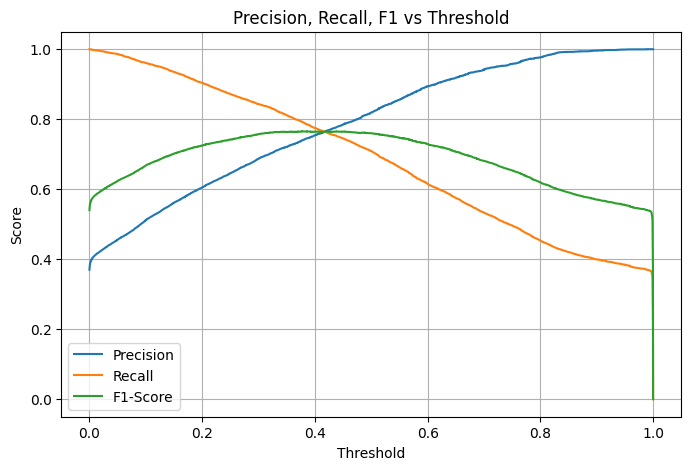

Best Threshold based on F1-Score: 0.3791


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score

# Predict probabilities
y_pred_prob = dnn_bn_model.predict(X_test).ravel()

# Calculate precision, recall, thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test_arr, y_pred_prob)

# Compute F1 for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-6)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1-Score')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, F1 vs Threshold')
plt.grid(True)
plt.legend()
plt.show()

# Get best threshold (highest F1)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Best Threshold based on F1-Score: {best_threshold:.4f}")

y_pred = (y_pred_prob >= best_threshold).astype("int32")

747/747 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


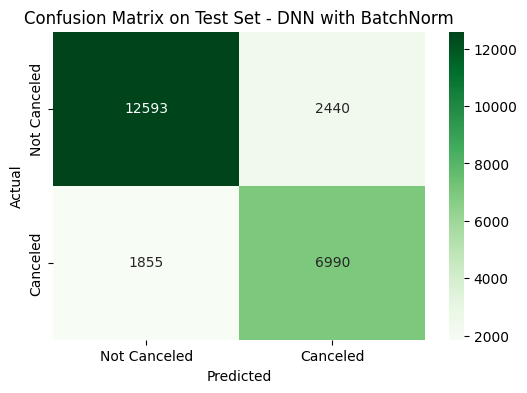


Classification Report for DNN with BatchNorm:
              precision    recall  f1-score   support

           0       0.87      0.84      0.85     15033
           1       0.74      0.79      0.76      8845

    accuracy                           0.82     23878
   macro avg       0.81      0.81      0.81     23878
weighted avg       0.82      0.82      0.82     23878



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on test set
y_pred_val = (dnn_bn_model.predict(X_test) > 0.38).astype("int32")

# Confusion Matrix
cm_dnn = confusion_matrix(y_test, y_pred_val)
labels = ['Not Canceled', 'Canceled']

plt.figure(figsize=(6,4))
sns.heatmap(cm_dnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix on Test Set - DNN with BatchNorm')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report for DNN with BatchNorm:")
print(classification_report(y_test, y_pred_val))

### DNN with Batch Normalization, L2 Regularization and Dropout - Tuning 2

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Build model
dnn_bn_l2_model = Sequential([
    Dense(512, activation='relu', kernel_regularizer=l2(1e-4), input_shape=(X_train_final.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),

    Dense(1, activation='sigmoid')
])

# Compile model
dnn_bn_l2_model.compile(optimizer=Adam(learning_rate=0.0005),
                        loss='binary_crossentropy',
                        metrics=['accuracy'])


dnn_bn_l2_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_113 (Dense)               │ (None, 512)            │        35,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_82 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_114 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_83 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_115 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_84 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_116 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_85 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_117 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_118 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 214,401 (837.50 KB)

 Trainable params: 212,417 (829.75 KB)

 Non-trainable params: 1,984 (7.75 KB)

In [ ]:
# Callbacks
callbacks = [
    EarlyStopping(patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

# Train the Model
history = dnn_bn_l2_model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=50, batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7837 - loss: 0.5314 - val_accuracy: 0.8060 - val_loss: 0.4907 - learning_rate: 5.0000e-04
Epoch 2/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7920 - loss: 0.5084 - val_accuracy: 0.8099 - val_loss: 0.4770 - learning_rate: 5.0000e-04
Epoch 3/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7952 - loss: 0.4942 - val_accuracy: 0.8118 - val_loss: 0.4662 - learning_rate: 5.0000e-04
Epoch 4/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7996 - loss: 0.4808 - val_accuracy: 0.8127 - val_loss: 0.4553 - learning_rate: 5.0000e-04
Epoch 5/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8025 - loss: 0.4693 - val_accuracy: 0.8161 - val_loss: 0.4449 - learning_rate: 5.0000e-04
Epoch 6/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8043 - loss: 0.4615 - val_accuracy: 0.8182 - val_loss: 0.4358 - learning_rate: 5.0000e-04
Epoch 7/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 11s 

In [ ]:
# Find Best Epoch
best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_train_acc = history.history['accuracy'][best_epoch - 1]
best_train_loss = history.history['loss'][best_epoch - 1]
best_val_acc = history.history['val_accuracy'][best_epoch - 1]
best_val_loss = history.history['val_loss'][best_epoch - 1]

print("\nBest Epoch and Results (DNN with BatchNorm & l2):")
print(f"Best Epoch: {best_epoch}")
print(f"Training Accuracy: {best_train_acc:.4f}")
print(f"Training Loss: {best_train_loss:.4f}")
print(f"Validation Accuracy: {best_val_acc:.4f}")
print(f"Validation Loss: {best_val_loss:.4f}")


Best Epoch and Results (DNN with BatchNorm & l2):
Best Epoch: 46
Training Accuracy: 0.8460
Training Loss: 0.3557
Validation Accuracy: 0.8421
Validation Loss: 0.3753


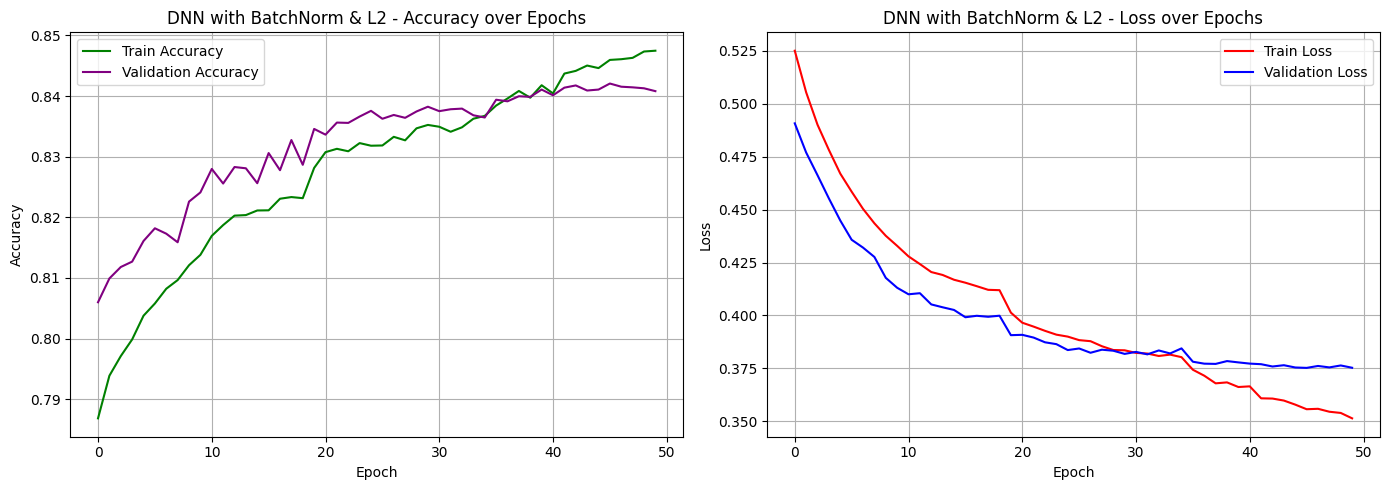

In [ ]:
# Plot Training & Validation Graphs
plt.figure(figsize=(14,5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy',  color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='purple')
plt.title('DNN with BatchNorm & L2 - Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss',  color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.title('DNN with BatchNorm & L2 - Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

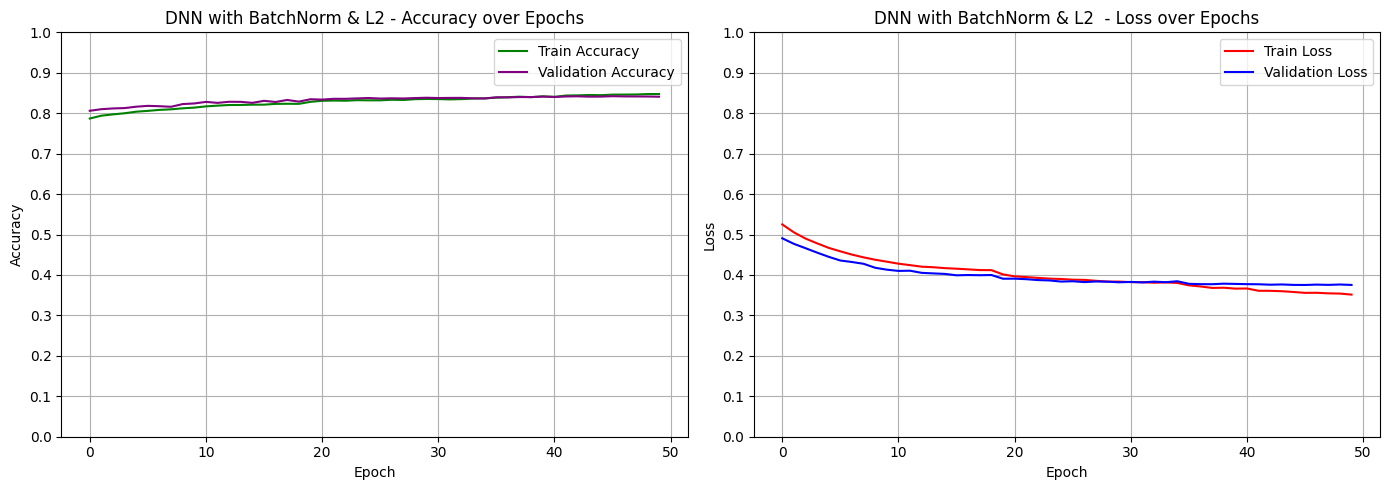

In [ ]:
# Plot Training & Validation Graphs
plt.figure(figsize=(14,5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy',  color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='purple')
plt.title('DNN with BatchNorm & L2 - Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0.0, 1.0)
plt.yticks([i/10 for i in range(11)])
plt.grid(True)
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss',  color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.title('DNN with BatchNorm & L2  - Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0.0, 1.0)
plt.yticks([i/10 for i in range(11)])
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

747/747 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


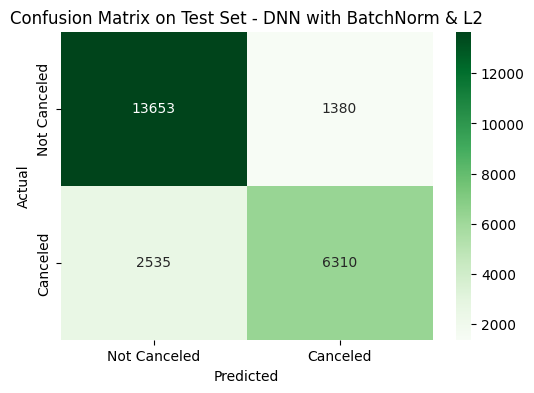


Classification Report for DNN with BatchNorm & L2:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87     15033
           1       0.82      0.71      0.76      8845

    accuracy                           0.84     23878
   macro avg       0.83      0.81      0.82     23878
weighted avg       0.83      0.84      0.83     23878



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on test set
y_pred_val = (dnn_bn_l2_model.predict(X_test) > 0.5).astype("int32")

# Confusion Matrix
cm_dnn = confusion_matrix(y_test, y_pred_val)
labels = ['Not Canceled', 'Canceled']

plt.figure(figsize=(6,4))
sns.heatmap(cm_dnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix on Test Set - DNN with BatchNorm & L2')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report for DNN with BatchNorm & L2:")
print(classification_report(y_test, y_pred_val))

747/747 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


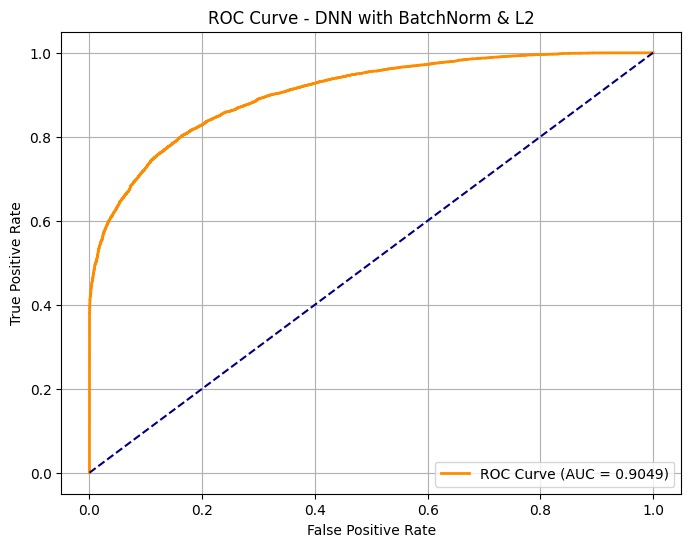

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities using correct input
y_pred_prob = dnn_bn_l2_model.predict(X_test).ravel()  # DNN uses 2D X_test

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - DNN with BatchNorm & L2')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
# Final Test Accuracy and Loss
test_loss, test_accuracy = dnn_bn_l2_model.evaluate(X_test, y_test, verbose=0)

print(f"\nFinal Test Accuracy (DNN with BatchNorm & L2): {test_accuracy:.4f}")
print(f"Final Test Loss (DNN with BatchNorm & L2): {test_loss:.4f}")


Final Test Accuracy (DNN with BatchNorm & L2): 0.8360
Final Test Loss (DNN with BatchNorm & L2): 0.3801


747/747 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


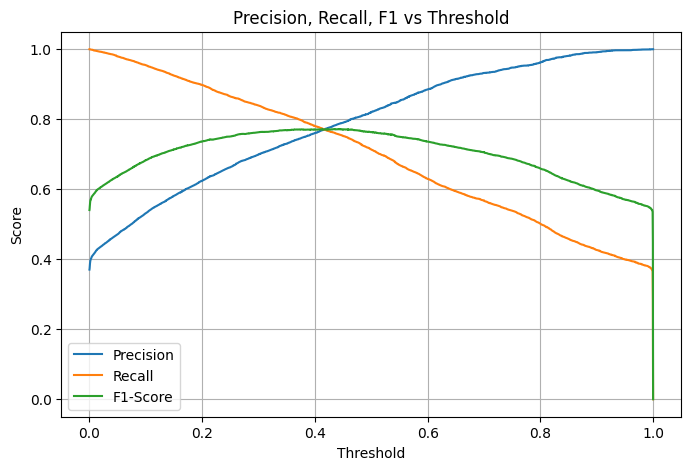

Best Threshold based on F1-Score: 0.4336


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score

# Predict probabilities
y_pred_prob = dnn_bn_l2_model.predict(X_test).ravel()

# Calculate precision, recall, thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test_arr, y_pred_prob)

# Compute F1 for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-6)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1-Score')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, F1 vs Threshold')
plt.grid(True)
plt.legend()
plt.show()


# Get best threshold (highest F1)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Best Threshold based on F1-Score: {best_threshold:.4f}")

y_pred = (y_pred_prob >= best_threshold).astype("int32")

747/747 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


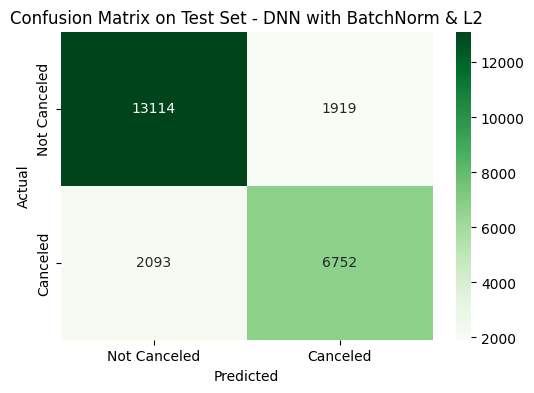


Classification Report for DNN with BatchNorm & L2:
              precision    recall  f1-score   support

           0       0.86      0.87      0.87     15033
           1       0.78      0.76      0.77      8845

    accuracy                           0.83     23878
   macro avg       0.82      0.82      0.82     23878
weighted avg       0.83      0.83      0.83     23878



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on test set
y_pred_val = (dnn_bn_l2_model.predict(X_test) > 0.43).astype("int32")

# Confusion Matrix
cm_dnn = confusion_matrix(y_test, y_pred_val)
labels = ['Not Canceled', 'Canceled']

plt.figure(figsize=(6,4))
sns.heatmap(cm_dnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix on Test Set - DNN with BatchNorm & L2')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report for DNN with BatchNorm & L2:")
print(classification_report(y_test, y_pred_val))

### Optimized DNN with Focal Loss + BatchNorm + L2 Reg + Dropout - Tuning 3

In [ ]:
import tensorflow as tf

def focal_loss(gamma=2.0, alpha=0.25):
    def focal(y_true, y_pred):
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1. - tf.keras.backend.epsilon())
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        return alpha * tf.pow(1 - p_t, gamma) * bce
    return focal

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Build the Model
dnn_opt_model = Sequential([
    Dense(512, activation='relu', kernel_regularizer=l2(1e-4), input_shape=(X_train_final.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),

    Dense(1, activation='sigmoid')
])
# Compile
dnn_opt_model.compile(optimizer=Adam(learning_rate=0.0005),
                        loss=focal_loss(gamma=2.0, alpha=0.25),
                        metrics=['accuracy'])

dnn_opt_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       126,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 303,361 (1.16 MB)

 Trainable params: 301,441 (1.15 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
# Callbacks
callbacks = [
    EarlyStopping(patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, verbose=1)
]

# Train the Model
history = dnn_opt_model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=50, batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7642 - loss: 0.0878 - val_accuracy: 0.8355 - val_loss: 0.0493 - learning_rate: 5.0000e-04
Epoch 2/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8229 - loss: 0.0434 - val_accuracy: 0.8391 - val_loss: 0.0259 - learning_rate: 5.0000e-04
Epoch 3/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8312 - loss: 0.0238 - val_accuracy: 0.8377 - val_loss: 0.0169 - learning_rate: 5.0000e-04
Epoch 4/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8340 - loss: 0.0166 - val_accuracy: 0.8416 - val_loss: 0.0137 - learning_rate: 5.0000e-04
Epoch 5/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8365 - loss: 0.0143 - val_accuracy: 0.8412 - val_loss: 0.0130 - learning_rate: 5.0000e-04
Epoch 6/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8341 - loss: 0.0136 - val_accuracy: 0.8421 - val_loss: 0.0123 - learning_rate: 5.0000e-04
Epoch 7/50
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/st

In [ ]:
# Find Best Epoch
best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_train_acc = history.history['accuracy'][best_epoch - 1]
best_train_loss = history.history['loss'][best_epoch - 1]
best_val_acc = history.history['val_accuracy'][best_epoch - 1]
best_val_loss = history.history['val_loss'][best_epoch - 1]

print("\nBest Epoch and Results (Optimized DNN):")
print(f"Best Epoch: {best_epoch}")
print(f"Training Accuracy: {best_train_acc:.4f}")
print(f"Training Loss: {best_train_loss:.4f}")
print(f"Validation Accuracy: {best_val_acc:.4f}")
print(f"Validation Loss: {best_val_loss:.4f}")


Best Epoch and Results (Optimized DNN):
Best Epoch: 49
Training Accuracy: 0.8739
Training Loss: 0.0075
Validation Accuracy: 0.8697
Validation Loss: 0.0078


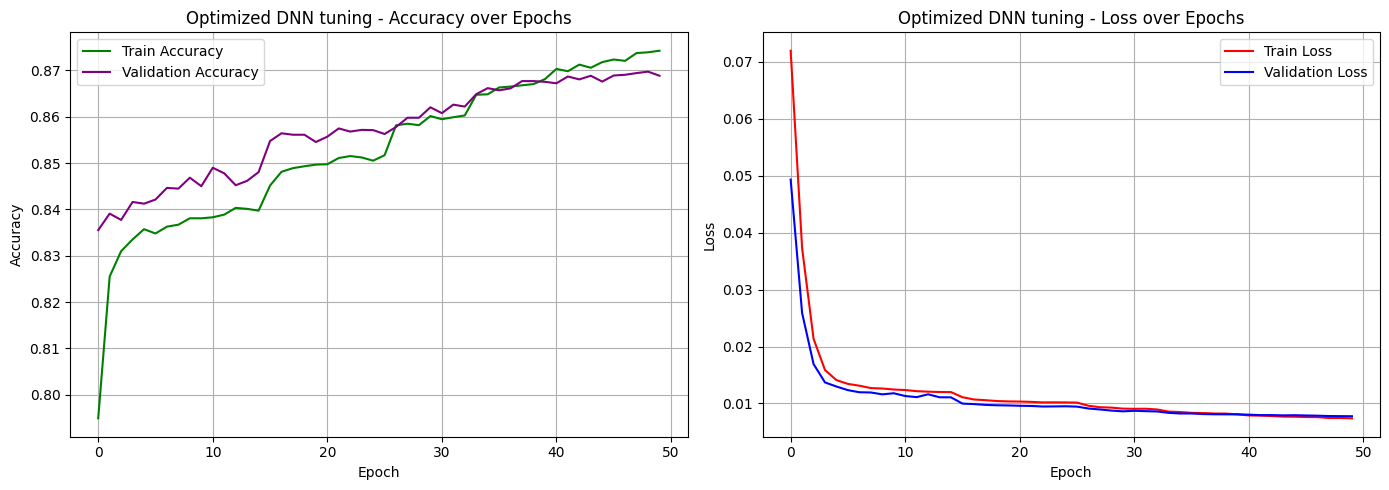

In [ ]:
# Plot Training & Validation Graphs
plt.figure(figsize=(14,5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy',  color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='purple')
plt.title('Optimized DNN tuning - Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss',  color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.title('Optimized DNN tuning - Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

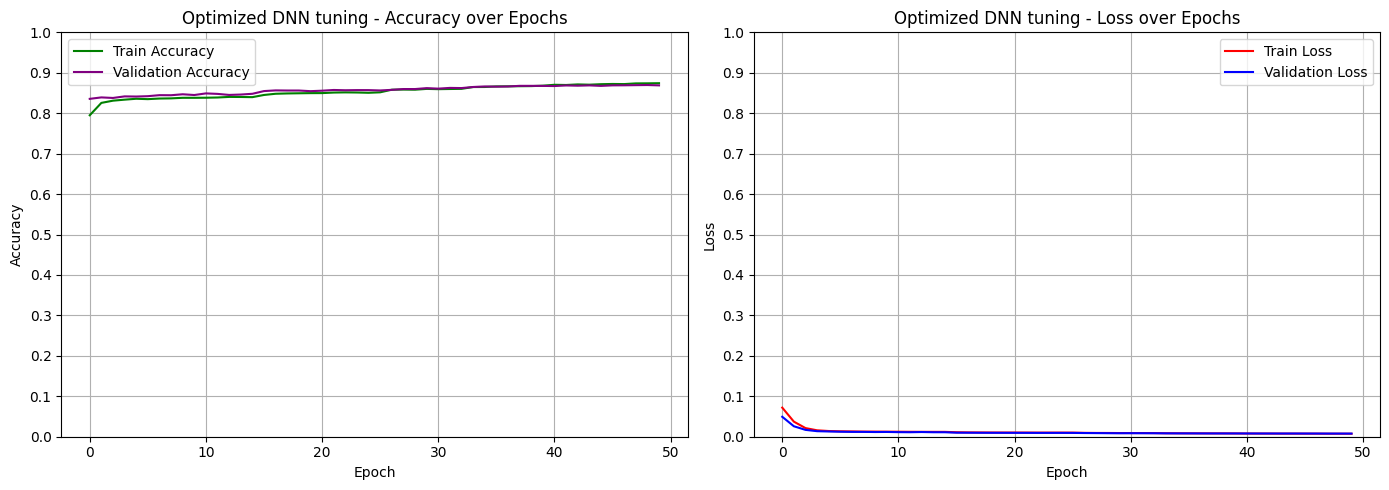

In [ ]:
# Plot Training & Validation Graphs
plt.figure(figsize=(14,5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy',  color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='purple')
plt.title('Optimized DNN tuning - Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0.0, 1.0)
plt.yticks([i/10 for i in range(11)])
plt.grid(True)
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss',  color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.title('Optimized DNN tuning - Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0.0, 1.0)
plt.yticks([i/10 for i in range(11)])
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

747/747 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


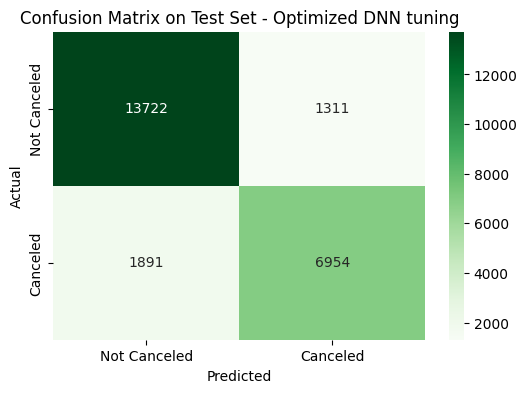


Classification Report for Optimized DNN tuning:
              precision    recall  f1-score   support

           0       0.88      0.91      0.90     15033
           1       0.84      0.79      0.81      8845

    accuracy                           0.87     23878
   macro avg       0.86      0.85      0.85     23878
weighted avg       0.86      0.87      0.86     23878



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on test set (2D input for DNN)
y_pred_val = (dnn_opt_model.predict(X_test) > 0.5).astype("int32")

# Confusion Matrix
cm_dnn = confusion_matrix(y_test, y_pred_val)
labels = ['Not Canceled', 'Canceled']

plt.figure(figsize=(6,4))
sns.heatmap(cm_dnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix on Test Set - Optimized DNN tuning')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report for Optimized DNN tuning:")
print(classification_report(y_test, y_pred_val))

747/747 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


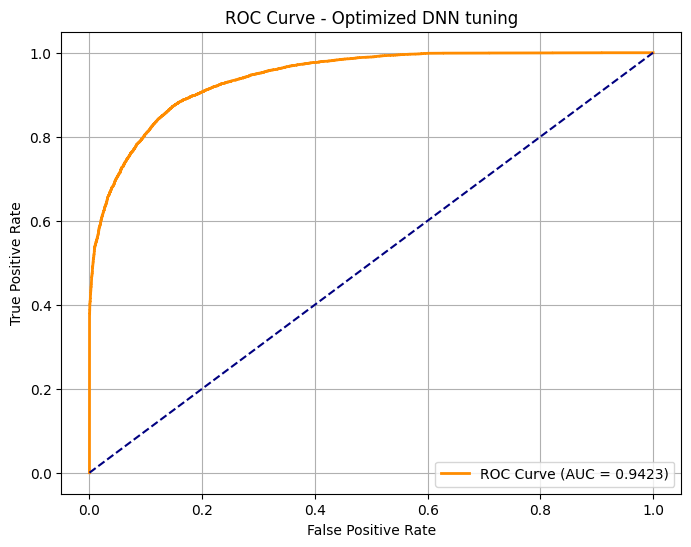

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities using correct 2D test data
y_pred_prob = dnn_opt_model.predict(X_test).ravel()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Optimized DNN tuning')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
# Final Test Accuracy and Loss
test_loss, test_accuracy = dnn_opt_model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal Test Accuracy (Optimized DNN tuning): {test_accuracy:.4f}")
print(f"Final Test Loss (Optimized DNN tuning): {test_loss:.4f}")


Final Test Accuracy (Optimized DNN tuning): 0.8659
Final Test Loss (Optimized DNN tuning): 0.0084


747/747 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


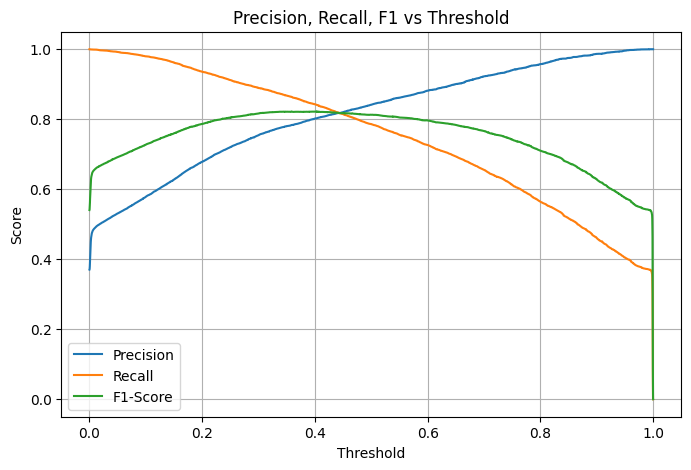

Best Threshold based on F1-Score: 0.4006


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score

# Predict probabilities
y_pred_prob = dnn_opt_model.predict(X_test).ravel()

# Calculate precision, recall, thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test_arr, y_pred_prob)

# Compute F1 for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-6)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1-Score')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, F1 vs Threshold')
plt.grid(True)
plt.legend()
plt.show()

# Get best threshold (highest F1)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Best Threshold based on F1-Score: {best_threshold:.4f}")

y_pred = (y_pred_prob >= best_threshold).astype("int32")

747/747 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


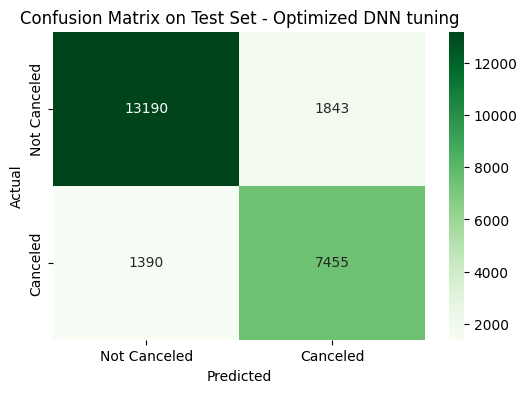


Classification Report for Optimized DNN tuning:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89     15033
           1       0.80      0.84      0.82      8845

    accuracy                           0.86     23878
   macro avg       0.85      0.86      0.86     23878
weighted avg       0.87      0.86      0.87     23878



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on test set (2D input for DNN)
y_pred_val = (dnn_opt_model.predict(X_test) > 0.40).astype("int32")

# Confusion Matrix
cm_dnn = confusion_matrix(y_test, y_pred_val)
labels = ['Not Canceled', 'Canceled']

plt.figure(figsize=(6,4))
sns.heatmap(cm_dnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix on Test Set - Optimized DNN tuning')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report for Optimized DNN tuning:")
print(classification_report(y_test, y_pred_val))

## **CNN + DNN HYBRID**

### CNN + DNN Base Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense

# CNN Model building
cnn_dnn_model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train_seq.shape[1], 1)),
    Conv1D(128, kernel_size=3, activation='relu'),

    Flatten(),

# DNN model building
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),

    Dense(1, activation='sigmoid')
])

# Complie
cnn_dnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

cnn_dnn_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 67, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 65, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 8320)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     1,065,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,098,369 (4.19 MB)

 Trainable params: 1,098,369 (4.19 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history = cnn_dnn_model.fit(
    X_train_seq, y_train_final,
    validation_data=(X_val_seq, y_val),
    epochs=30,
    batch_size=64,
    verbose=1
)

Epoch 1/30
742/742 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8192 - loss: 0.3872 - val_accuracy: 0.8634 - val_loss: 0.3013
Epoch 2/30
742/742 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8645 - loss: 0.2996 - val_accuracy: 0.8701 - val_loss: 0.2812
Epoch 3/30
742/742 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8725 - loss: 0.2804 - val_accuracy: 0.8749 - val_loss: 0.2697
Epoch 4/30
742/742 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8765 - loss: 0.2692 - val_accuracy: 0.8755 - val_loss: 0.2661
Epoch 5/30
742/742 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8788 - loss: 0.2616 - val_accuracy: 0.8768 - val_loss: 0.2647
Epoch 6/30
742/742 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8834 - loss: 0.2551 - val_accuracy: 0.8772 - val_loss: 0.2620
Epoch 7/30
742/742 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8856 - loss: 0.2484 - val_accuracy: 0.8784 - val_loss: 0.2627
Epoch 8/30
742/742 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8877 - loss: 0.2425 - val_acc

In [ ]:
# Find Best Epoch based on Validation Accuracy
best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_train_acc = history.history['accuracy'][best_epoch - 1]
best_train_loss = history.history['loss'][best_epoch - 1]
best_val_acc = history.history['val_accuracy'][best_epoch - 1]
best_val_loss = history.history['val_loss'][best_epoch - 1]

print("\nBest Epoch and Results (CNN+DNN HYBRID):")
print(f"Best Epoch: {best_epoch}")
print(f"Training Accuracy: {best_train_acc:.4f}")
print(f"Training Loss: {best_train_loss:.4f}")
print(f"Validation Accuracy: {best_val_acc:.4f}")
print(f"Validation Loss: {best_val_loss:.4f}")


Best Epoch and Results (CNN+DNN HYBRID):
Best Epoch: 8
Training Accuracy: 0.8889
Training Loss: 0.2387
Validation Accuracy: 0.8794
Validation Loss: 0.2625


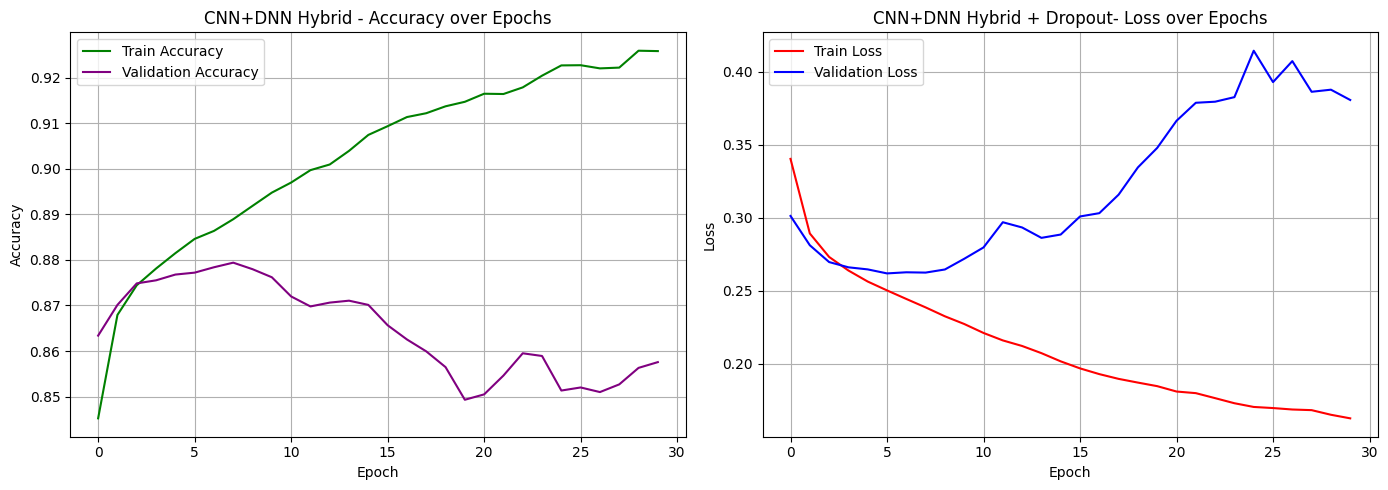

In [ ]:
# Plot Training & Validation Graphs
plt.figure(figsize=(14,5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy',  color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='purple')
plt.title('CNN+DNN Hybrid - Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss',  color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.title('CNN+DNN Hybrid + Dropout- Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

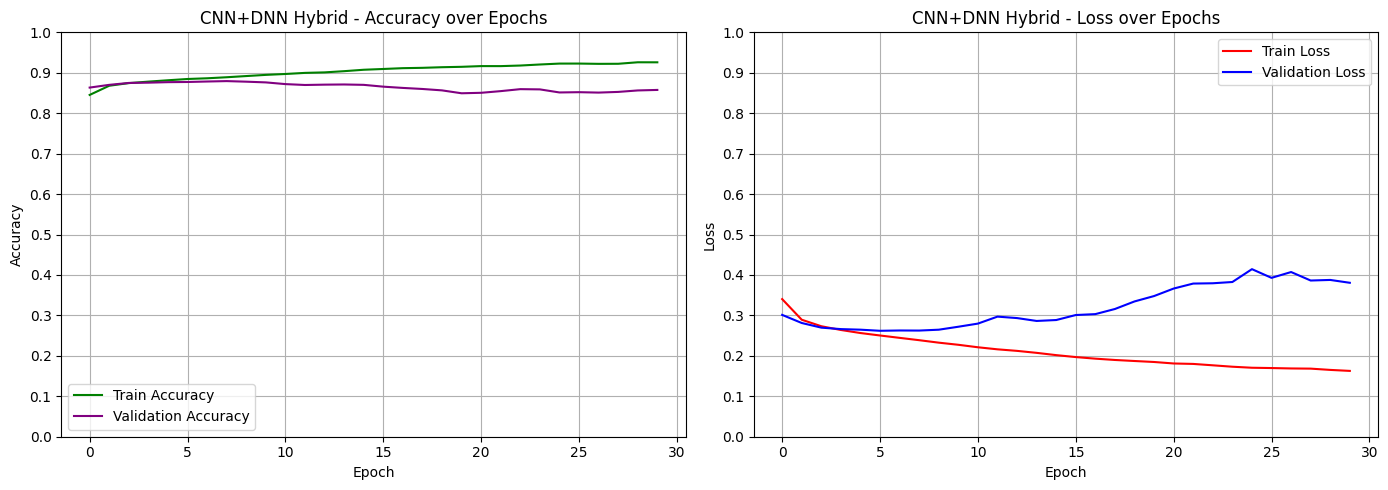

In [ ]:
# Plot Training & Validation Graphs
plt.figure(figsize=(14,5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy',  color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='purple')
plt.title('CNN+DNN Hybrid - Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0.0, 1.0)
plt.yticks([i/10 for i in range(11)])
plt.grid(True)
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss',  color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.title('CNN+DNN Hybrid - Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0.0, 1.0)
plt.yticks([i/10 for i in range(11)])
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

464/464 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


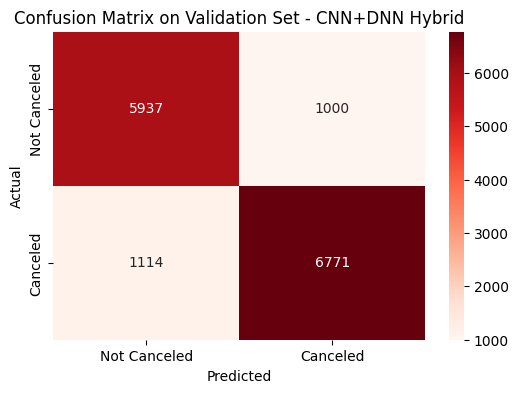


Classification Report for CNN+DNN Hybrid:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      6937
           1       0.87      0.86      0.86      7885

    accuracy                           0.86     14822
   macro avg       0.86      0.86      0.86     14822
weighted avg       0.86      0.86      0.86     14822



In [ ]:
# Confusion Matrix + Classification Report
y_pred_val = (cnn_dnn_model.predict(X_test_seq) > 0.5).astype("int32")

cm_dnn = confusion_matrix(y_test_arr, y_pred_val)

labels = ['Not Canceled', 'Canceled']

plt.figure(figsize=(6,4))
sns.heatmap(cm_dnn, annot=True, fmt='d', cmap='Reds',
              xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix on Validation Set - CNN+DNN Hybrid')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report for CNN+DNN Hybrid:")
print(classification_report(y_test_arr, y_pred_val))

464/464 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


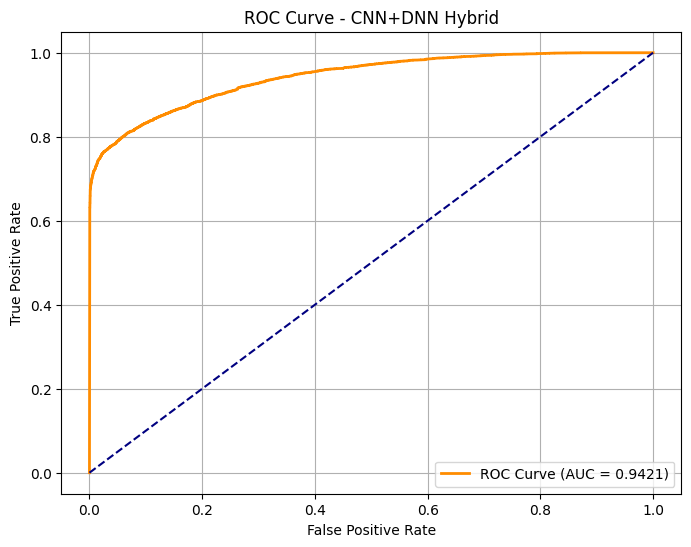

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities with CNN+DNN
y_pred_prob = cnn_dnn_model.predict(X_test_seq).ravel()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_arr, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - CNN+DNN Hybrid')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
# Final Test Accuracy and Loss for CNN+DNN
test_loss, test_accuracy = cnn_dnn_model.evaluate(X_test_seq, y_test_arr, verbose=0)
print(f"\nFinal Test Accuracy (CNN+DNN Hybrid): {test_accuracy:.4f}")
print(f"Final Test Loss (CNN+DNN Hybrid): {test_loss:.4f}")


Final Test Accuracy (CNN+DNN Hybrid): 0.8574
Final Test Loss (CNN+DNN Hybrid): 0.3729


464/464 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


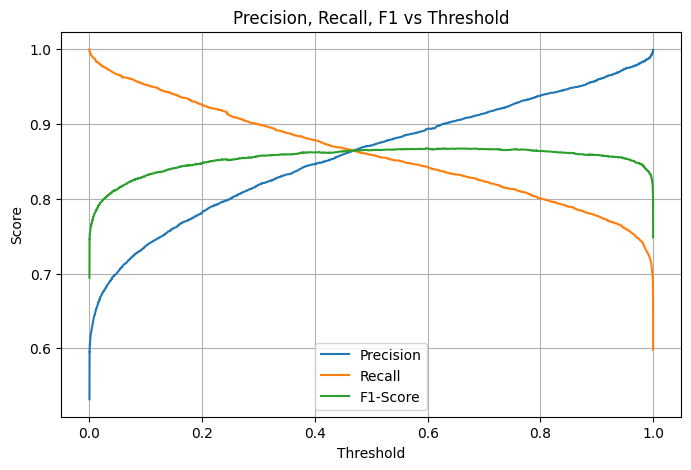

Best Threshold based on F1-Score: 0.5996


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score

# Predict probabilities
y_pred_prob = cnn_dnn_model.predict(X_test_seq).ravel()

# Calculate precision, recall, thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test_arr, y_pred_prob)

# Compute F1 for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-6)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1-Score')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, F1 vs Threshold')
plt.grid(True)
plt.legend()
plt.show()

# Get best threshold (highest F1)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Best Threshold based on F1-Score: {best_threshold:.4f}")

y_pred = (y_pred_prob >= best_threshold).astype("int32")

464/464 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


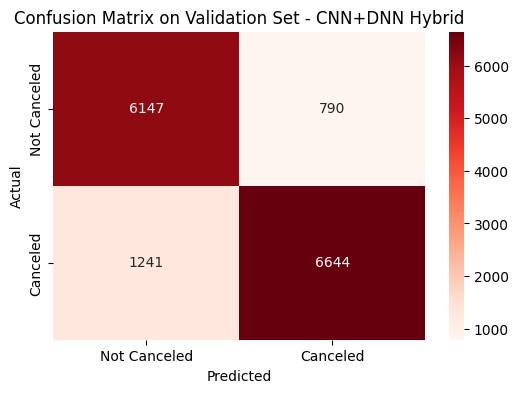


Classification Report for CNN+DNN Hybrid:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      6937
           1       0.89      0.84      0.87      7885

    accuracy                           0.86     14822
   macro avg       0.86      0.86      0.86     14822
weighted avg       0.86      0.86      0.86     14822



In [ ]:
# Confusion Matrix + Classification Report
y_pred_val = (cnn_dnn_model.predict(X_test_seq) > 0.60).astype("int32")

cm_dnn = confusion_matrix(y_test_arr, y_pred_val)

labels = ['Not Canceled', 'Canceled']

plt.figure(figsize=(6,4))
sns.heatmap(cm_dnn, annot=True, fmt='d', cmap='Reds',
              xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix on Validation Set - CNN+DNN Hybrid')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report for CNN+DNN Hybrid:")
print(classification_report(y_test_arr, y_pred_val))

### CNN + DNN with Batch Normalization and Dropout - Tuning 1

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Enhanced CNN+DNN model
cnn_dnn_bn_model = Sequential([
    # CNN Block
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train_seq.shape[1], 1)),
    BatchNormalization(),
    Dropout(0.3),

    Conv1D(128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Flatten(),

    # DNN Block
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

# Compile the model
cnn_dnn_bn_model.compile(optimizer=Adam(learning_rate=0.0005),
                       loss='binary_crossentropy',
                       metrics=['accuracy'])

cnn_dnn_bn_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 67, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 67, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 67, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 65, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 65, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 65, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8320)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,065,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,099,905 (4.20 MB)

 Trainable params: 1,099,137 (4.19 MB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
# Callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

# Train the model
history = cnn_dnn_bn_model.fit(
    X_train_seq, y_train_final,
    validation_data=(X_val_seq, y_val),
    epochs=50,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.7916 - loss: 0.4672 - val_accuracy: 0.8556 - val_loss: 0.3343 - learning_rate: 5.0000e-04
Epoch 2/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.8402 - loss: 0.3524 - val_accuracy: 0.8625 - val_loss: 0.3046 - learning_rate: 5.0000e-04
Epoch 3/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.8493 - loss: 0.3320 - val_accuracy: 0.8648 - val_loss: 0.2941 - learning_rate: 5.0000e-04
Epoch 4/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.8542 - loss: 0.3191 - val_accuracy: 0.8689 - val_loss: 0.2885 - learning_rate: 5.0000e-04
Epoch 5/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.8612 - loss: 0.3113 - val_accuracy: 0.8691 - val_loss: 0.2838 - learning_rate: 5.0000e-04
Epoch 6/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.8614 - loss: 0.3071 - val_accuracy: 0.8699 - val_loss: 0.2753 - learning_rate: 5.0000e-04
Epoch 7/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/ste

In [ ]:
# Find Best Epoch based on Validation Accuracy
best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_train_acc = history.history['accuracy'][best_epoch - 1]
best_train_loss = history.history['loss'][best_epoch - 1]
best_val_acc = history.history['val_accuracy'][best_epoch - 1]
best_val_loss = history.history['val_loss'][best_epoch - 1]

print("\nBest Epoch and Results (CNN+DNN with BatchNorm):")
print(f"Best Epoch: {best_epoch}")
print(f"Training Accuracy: {best_train_acc:.4f}")
print(f"Training Loss: {best_train_loss:.4f}")
print(f"Validation Accuracy: {best_val_acc:.4f}")
print(f"Validation Loss: {best_val_loss:.4f}")


Best Epoch and Results (CNN+DNN with BatchNorm):
Best Epoch: 47
Training Accuracy: 0.8887
Training Loss: 0.2406
Validation Accuracy: 0.8909
Validation Loss: 0.2420


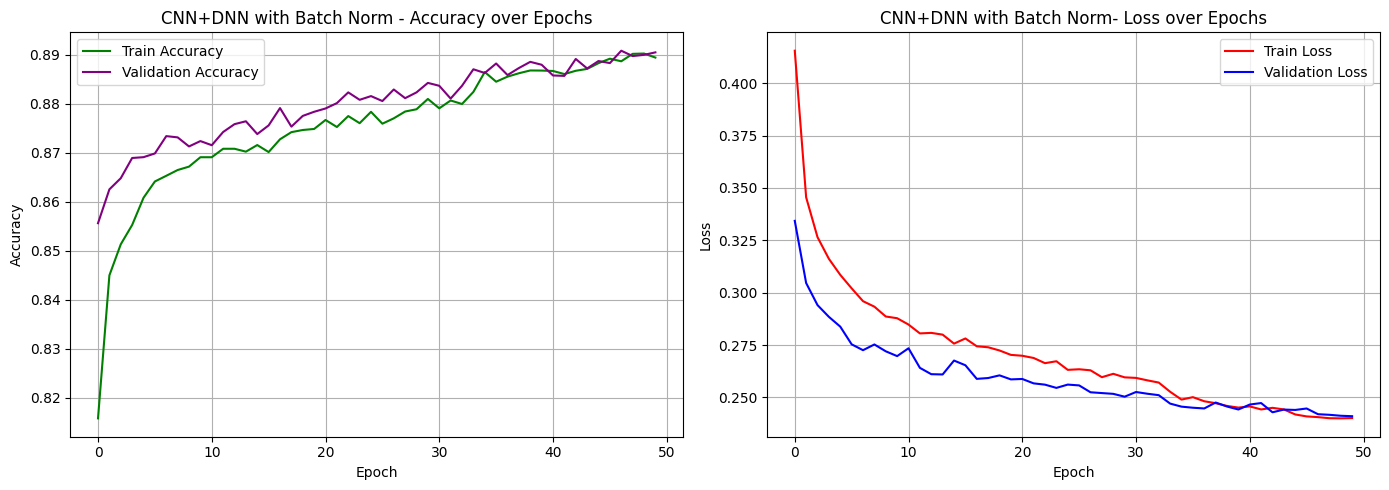

In [ ]:
# Plot Training & Validation Graphs
plt.figure(figsize=(14,5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy',  color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='purple')
plt.title('CNN+DNN with Batch Norm - Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss',  color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.title('CNN+DNN with Batch Norm- Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

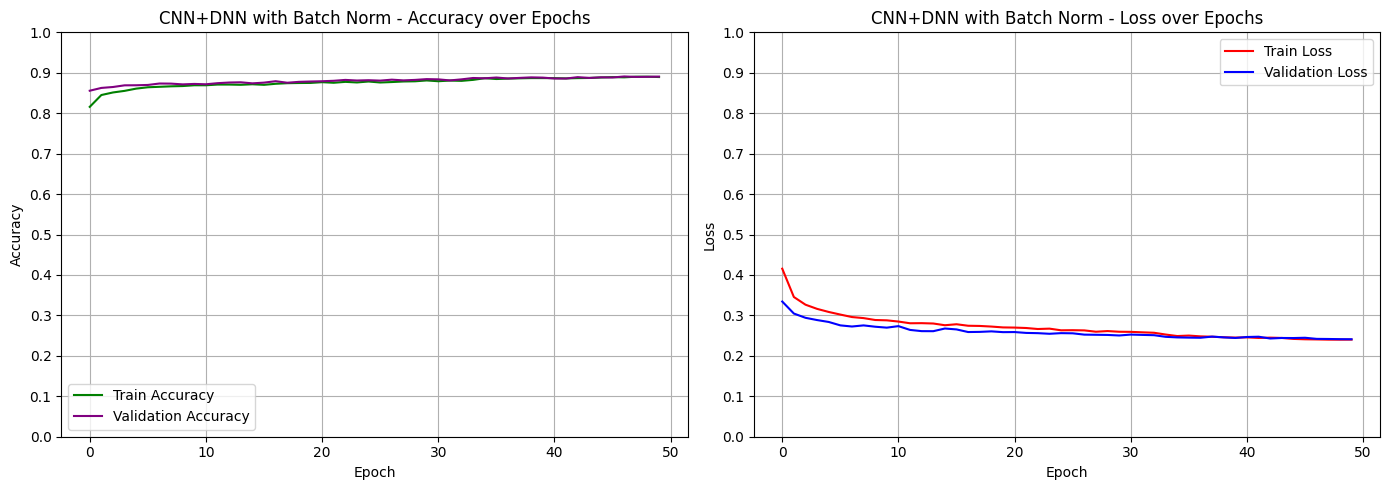

In [ ]:
# Plot Training & Validation Graphs
plt.figure(figsize=(14,5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy',  color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='purple')
plt.title('CNN+DNN with Batch Norm - Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0.0, 1.0)
plt.yticks([i/10 for i in range(11)])
plt.grid(True)
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss',  color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.title('CNN+DNN with Batch Norm - Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0.0, 1.0)
plt.yticks([i/10 for i in range(11)])
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

464/464 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


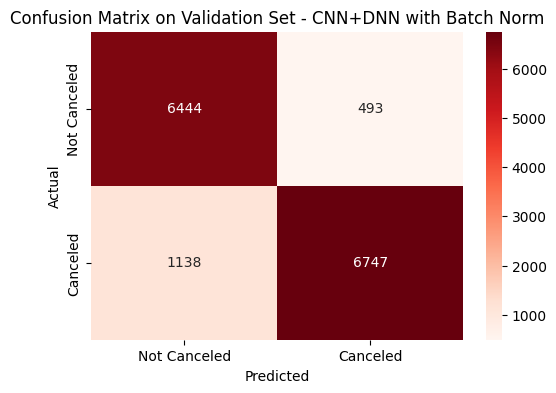


Classification Report for CNN+DNN with Batch Norm:
              precision    recall  f1-score   support

           0       0.85      0.93      0.89      6937
           1       0.93      0.86      0.89      7885

    accuracy                           0.89     14822
   macro avg       0.89      0.89      0.89     14822
weighted avg       0.89      0.89      0.89     14822



In [ ]:
# Confusion Matrix + Classification Report
# Predict on validation set
y_pred_val = (cnn_dnn_bn_model.predict(X_test_seq) > 0.5).astype("int32")

cm_dnn = confusion_matrix(y_test_arr, y_pred_val)

labels = ['Not Canceled', 'Canceled']

plt.figure(figsize=(6,4))
sns.heatmap(cm_dnn, annot=True, fmt='d', cmap='Reds',
              xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix on Validation Set - CNN+DNN with Batch Norm')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report for CNN+DNN with Batch Norm:")
print(classification_report(y_test_arr, y_pred_val))

464/464 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


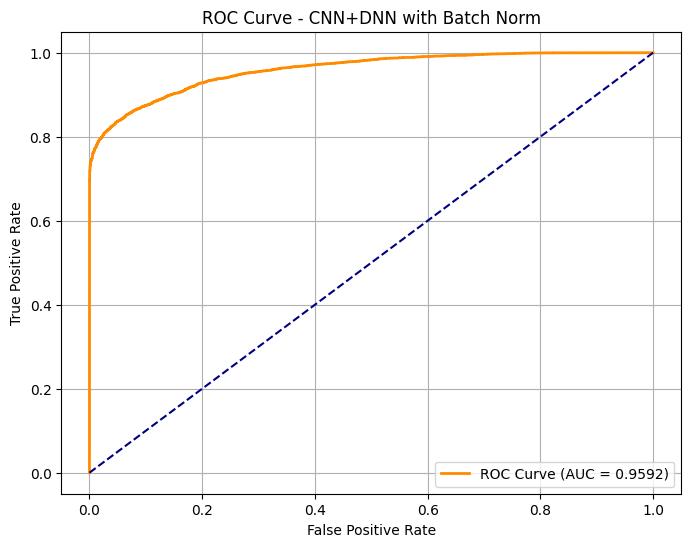

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities with CNN+DNN
y_pred_prob = cnn_dnn_bn_model.predict(X_test_seq).ravel()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_arr, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - CNN+DNN with Batch Norm')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
# Final Test Accuracy and Loss for CNN+DNN
test_loss, test_accuracy = cnn_dnn_bn_model.evaluate(X_test_seq, y_test_arr, verbose=0)
print(f"\nFinal Test Accuracy (CNN+DNN with Batch Norm): {test_accuracy:.4f}")
print(f"Final Test Loss (CNN+DNN with Batch Norm): {test_loss:.4f}")


Final Test Accuracy (CNN+DNN with Batch Norm): 0.8900
Final Test Loss (CNN+DNN with Batch Norm): 0.2400


464/464 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


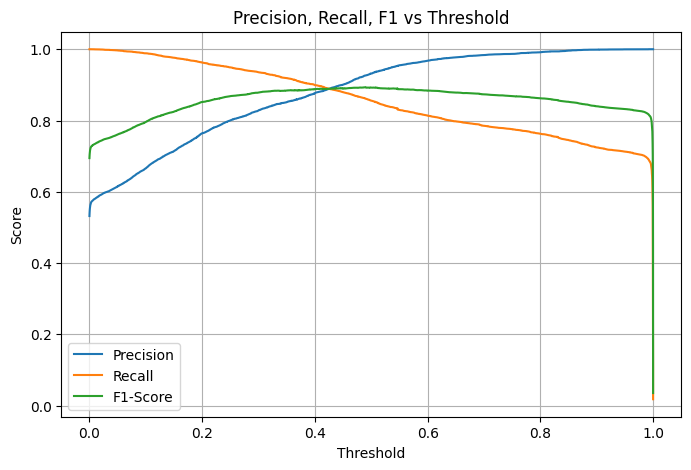

Best Threshold based on F1-Score: 0.4882


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score

# Predict probabilities
y_pred_prob = cnn_dnn_bn_model.predict(X_test_seq).ravel()

# Calculate precision, recall, thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test_arr, y_pred_prob)

# Compute F1 for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-6)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1-Score')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, F1 vs Threshold')
plt.grid(True)
plt.legend()
plt.show()

# Get best threshold (highest F1)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Best Threshold based on F1-Score: {best_threshold:.4f}")

y_pred = (y_pred_prob >= best_threshold).astype("int32")

464/464 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


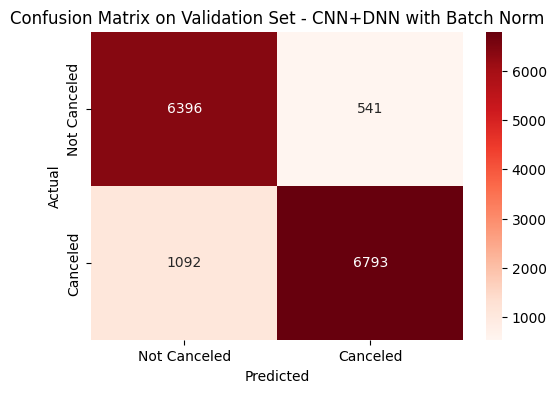


Classification Report for CNN+DNN with Batch Norm:
              precision    recall  f1-score   support

           0       0.85      0.92      0.89      6937
           1       0.93      0.86      0.89      7885

    accuracy                           0.89     14822
   macro avg       0.89      0.89      0.89     14822
weighted avg       0.89      0.89      0.89     14822



In [ ]:
# Confusion Matrix + Classification Report
y_pred_val = (cnn_dnn_bn_model.predict(X_test_seq) > 0.49).astype("int32")

cm_dnn = confusion_matrix(y_test_arr, y_pred_val)

labels = ['Not Canceled', 'Canceled']

plt.figure(figsize=(6,4))
sns.heatmap(cm_dnn, annot=True, fmt='d', cmap='Reds',
              xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix on Validation Set - CNN+DNN with Batch Norm')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report for CNN+DNN with Batch Norm:")
print(classification_report(y_test_arr, y_pred_val))

### CNN + DNN Hybrid Model with BatchNormalization, Dropout & L2 Regularization - Tuning 2

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay

cnn_dnn_opt_model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(1e-4), input_shape=(X_train_seq.shape[1], 1)),
    BatchNormalization(),
    Dropout(0.3),

    Conv1D(128, kernel_size=3, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),

    Flatten(),

    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

# Learning Rate Schedule
lr_schedule = ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=1000,
    decay_rate=0.9,
    staircase=True
)

# Compile with the scheduler
cnn_dnn_opt_model.compile(
    optimizer=Adam(learning_rate=lr_schedule),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
cnn_dnn_opt_model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_10 (Conv1D)              │ (None, 67, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 67, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 67, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 65, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 65, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 65, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 8320)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │     1,065,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,099,649 (4.19 MB)

 Trainable params: 1,099,009 (4.19 MB)

 Non-trainable params: 640 (2.50 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Callbacks
early_stop = EarlyStopping(patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, verbose=1)

# Train the model
history = cnn_dnn_opt_model.fit(
    X_train_seq, y_train_final,
    validation_data=(X_val_seq, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.8022 - loss: 0.4909 - val_accuracy: 0.8582 - val_loss: 0.3806 - learning_rate: 0.0010
Epoch 2/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.8495 - loss: 0.3884 - val_accuracy: 0.8625 - val_loss: 0.3580 - learning_rate: 9.0000e-04
Epoch 3/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.8542 - loss: 0.3719 - val_accuracy: 0.8692 - val_loss: 0.3446 - learning_rate: 8.1000e-04
Epoch 4/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.8626 - loss: 0.3586 - val_accuracy: 0.8720 - val_loss: 0.3292 - learning_rate: 8.1000e-04
Epoch 5/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.8656 - loss: 0.3458 - val_accuracy: 0.8703 - val_loss: 0.3247 - learning_rate: 7.2900e-04
Epoch 6/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.8683 - loss: 0.3371 - val_accuracy: 0.8715 - val_loss: 0.3189 - learning_rate: 6.5610e-04
Epoch 7/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - 

In [ ]:
# Find Best Epoch based on Validation Accuracy
best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_train_acc = history.history['accuracy'][best_epoch - 1]
best_train_loss = history.history['loss'][best_epoch - 1]
best_val_acc = history.history['val_accuracy'][best_epoch - 1]
best_val_loss = history.history['val_loss'][best_epoch - 1]

print("\nBest Epoch and Results (Optimized CNN+DNN HYBRID Tuning):")
print(f"Best Epoch: {best_epoch}")
print(f"Training Accuracy: {best_train_acc:.4f}")
print(f"Training Loss: {best_train_loss:.4f}")
print(f"Validation Accuracy: {best_val_acc:.4f}")
print(f"Validation Loss: {best_val_loss:.4f}")


Best Epoch and Results (Optimized CNN+DNN HYBRID Tuning):
Best Epoch: 49
Training Accuracy: 0.8884
Training Loss: 0.2583
Validation Accuracy: 0.8863
Validation Loss: 0.2641


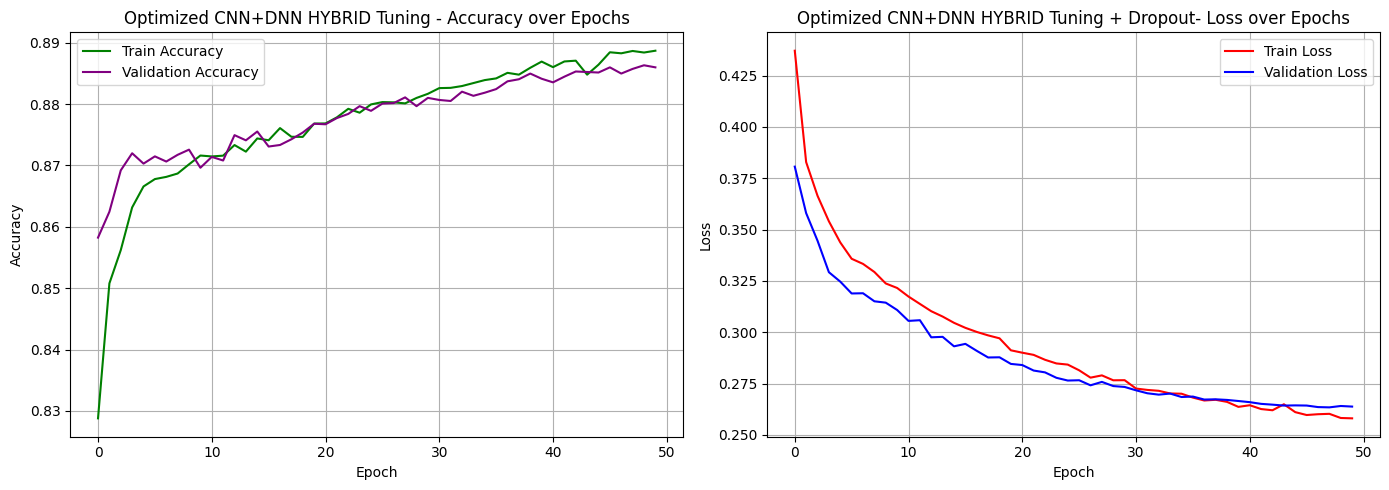

In [ ]:
# Plot Training & Validation Graphs
plt.figure(figsize=(14,5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy',  color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='purple')
plt.title('Optimized CNN+DNN HYBRID Tuning - Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss',  color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.title('Optimized CNN+DNN HYBRID Tuning + Dropout- Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

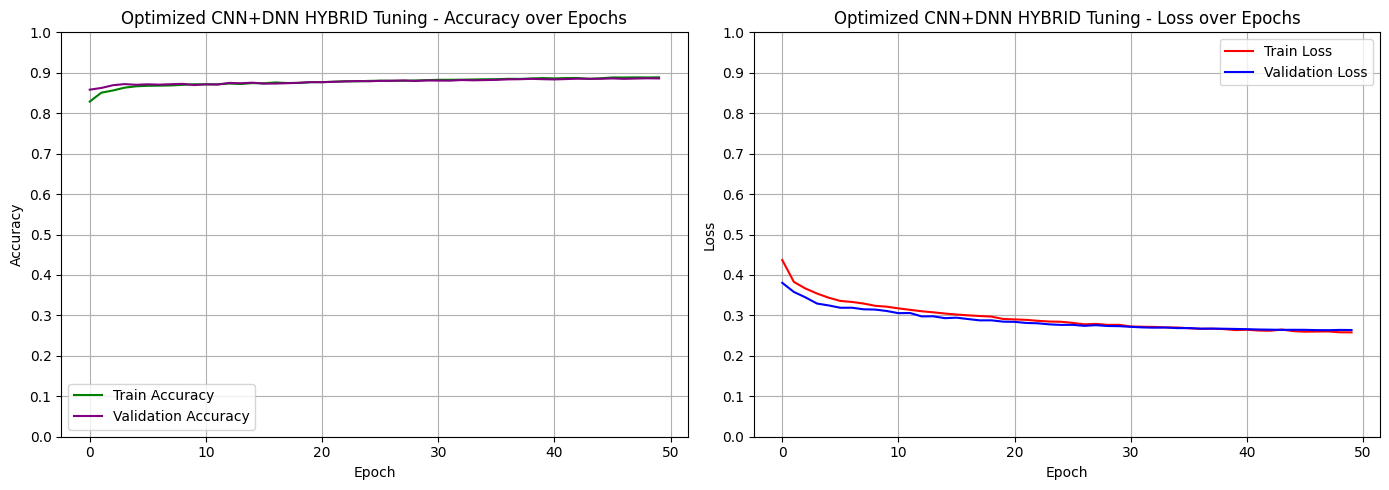

In [ ]:
# Plot Training & Validation Graphs
plt.figure(figsize=(14,5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy',  color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='purple')
plt.title('Optimized CNN+DNN HYBRID Tuning - Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0.0, 1.0)
plt.yticks([i/10 for i in range(11)])
plt.grid(True)
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss',  color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.title('Optimized CNN+DNN HYBRID Tuning - Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0.0, 1.0)
plt.yticks([i/10 for i in range(11)])
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

464/464 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


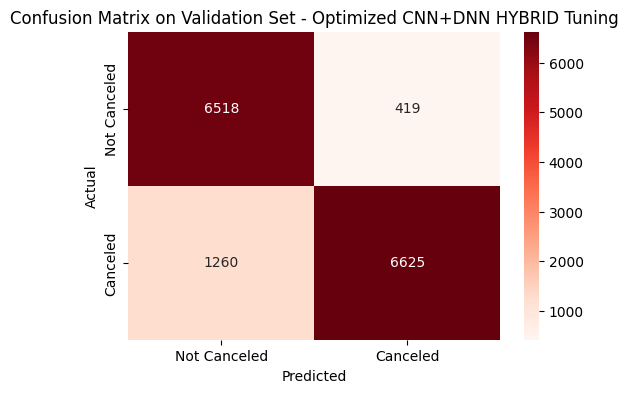


Classification Report forOptimized CNN+DNN HYBRID Tuning:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      6937
           1       0.94      0.84      0.89      7885

    accuracy                           0.89     14822
   macro avg       0.89      0.89      0.89     14822
weighted avg       0.89      0.89      0.89     14822



In [ ]:
# Confusion Matrix + Classification Report
# Predict on validation set
y_pred_val = (cnn_dnn_opt_model.predict(X_test_seq) > 0.5).astype("int32")

cm_dnn = confusion_matrix(y_test_arr, y_pred_val)

labels = ['Not Canceled', 'Canceled']

plt.figure(figsize=(6,4))
sns.heatmap(cm_dnn, annot=True, fmt='d', cmap='Reds',
              xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix on Validation Set - Optimized CNN+DNN HYBRID Tuning')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report forOptimized CNN+DNN HYBRID Tuning:")
print(classification_report(y_test_arr, y_pred_val))

464/464 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


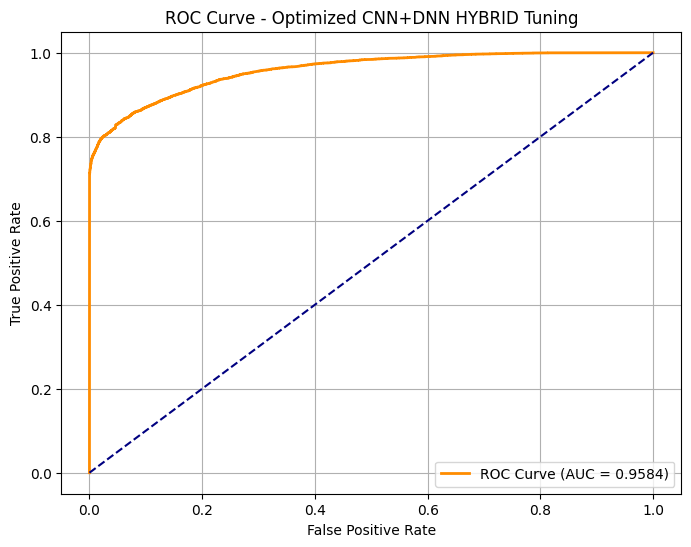

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities with CNN+DNN
y_pred_prob = cnn_dnn_opt_model.predict(X_test_seq).ravel()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_arr, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Optimized CNN+DNN HYBRID Tuning')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
# Final Test Accuracy and Loss for CNN+DNN
test_loss, test_accuracy = cnn_dnn_opt_model.evaluate(X_test_seq, y_test_arr, verbose=0)
print(f"\nFinal Test Accuracy (Optimized CNN+DNN HYBRID Tuning): {test_accuracy:.4f}")
print(f"Final Test Loss (Optimized CNN+DNN HYBRID Tuning): {test_loss:.4f}")


Final Test Accuracy (Optimized CNN+DNN HYBRID Tuning): 0.8867
Final Test Loss (Optimized CNN+DNN HYBRID Tuning): 0.2618


464/464 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


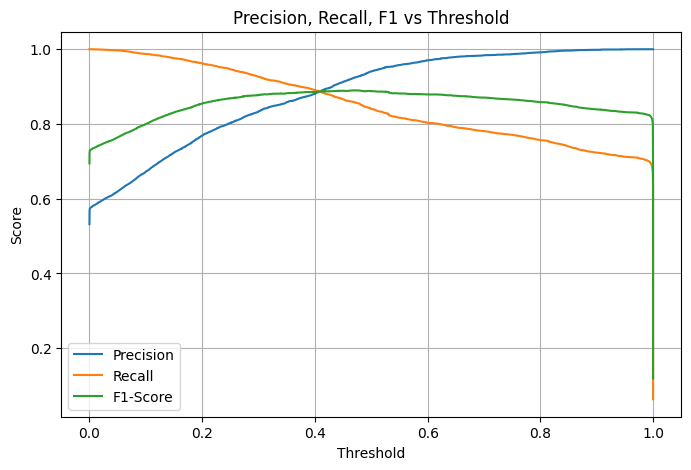

Best Threshold based on F1-Score: 0.4691


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score

# Predict probabilities
y_pred_prob = cnn_dnn_opt_model.predict(X_test_seq).ravel() # Changed cnn_dnn_model to cnn_dnn_opt_model

# Calculate precision, recall, thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test_arr, y_pred_prob)

# Compute F1 for each thresholdopt_
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-6)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1-Score')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, F1 vs Threshold')
plt.grid(True)
plt.legend()
plt.show()


# Get best threshold (highest F1)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Best Threshold based on F1-Score: {best_threshold:.4f}")

y_pred = (y_pred_prob >= best_threshold).astype("int32")

464/464 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


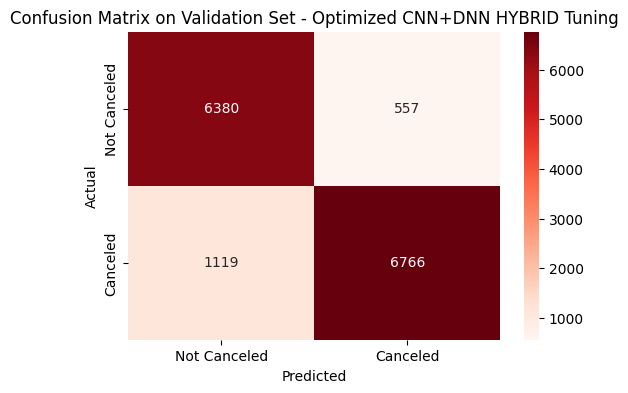


Classification Report forOptimized CNN+DNN HYBRID Tuning:
              precision    recall  f1-score   support

           0       0.85      0.92      0.88      6937
           1       0.92      0.86      0.89      7885

    accuracy                           0.89     14822
   macro avg       0.89      0.89      0.89     14822
weighted avg       0.89      0.89      0.89     14822



In [ ]:
# Confusion Matrix + Classification Report
# Predict on validation set
y_pred_val = (cnn_dnn_opt_model.predict(X_test_seq) > 0.47).astype("int32")

cm_dnn = confusion_matrix(y_test_arr, y_pred_val)

labels = ['Not Canceled', 'Canceled']

plt.figure(figsize=(6,4))
sns.heatmap(cm_dnn, annot=True, fmt='d', cmap='Reds',
              xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix on Validation Set - Optimized CNN+DNN HYBRID Tuning')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report forOptimized CNN+DNN HYBRID Tuning:")
print(classification_report(y_test_arr, y_pred_val))

### CNN+DNN with Optimized tuning using Focal loss - Tuning 3

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K
import tensorflow as tf

# Focal Loss Function
def focal_loss(gamma=2., alpha=0.25):
    def focal(y_true, y_pred):
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        y_pred = K.clip(y_pred, K.epsilon(), 1. - K.epsilon())
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        return alpha * K.pow(1. - p_t, gamma) * bce
    return focal

# Model definition
cnn_dnn_focal_model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(1e-4), input_shape=(X_train_seq.shape[1], 1)),
    BatchNormalization(),
    Conv1D(128, kernel_size=3, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Flatten(),

    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

cnn_dnn_focal_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=focal_loss(gamma=2., alpha=0.25),
    metrics=['accuracy']
)

# Summary
cnn_dnn_focal_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 67, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 67, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 65, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 65, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8320)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │     1,065,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,099,905 (4.20 MB)

 Trainable params: 1,099,137 (4.19 MB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping to avoid overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the model
history = cnn_dnn_focal_model.fit(
    X_train_seq, y_train_final,
    validation_data=(X_val_seq, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.7985 - loss: 0.0597 - val_accuracy: 0.8547 - val_loss: 0.0462
Epoch 2/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.8419 - loss: 0.0469 - val_accuracy: 0.8615 - val_loss: 0.0404
Epoch 3/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.8461 - loss: 0.0406 - val_accuracy: 0.8628 - val_loss: 0.0345
Epoch 4/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8508 - loss: 0.0349 - val_accuracy: 0.8607 - val_loss: 0.0301
Epoch 5/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.8566 - loss: 0.0297 - val_accuracy: 0.8695 - val_loss: 0.0253
Epoch 6/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.8594 - loss: 0.0258 - val_accuracy: 0.8665 - val_loss: 0.0218
Epoch 7/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.8609 - loss: 0.0223 - val_accuracy: 0.8702 - val_loss: 0.0190
Epoch 8/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.8622 - loss: 0.0197 - 

In [ ]:
# Find Best Epoch Accuracy
best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_train_acc = history.history['accuracy'][best_epoch - 1]
best_train_loss = history.history['loss'][best_epoch - 1]
best_val_acc = history.history['val_accuracy'][best_epoch - 1]
best_val_loss = history.history['val_loss'][best_epoch - 1]

print("\nBest Epoch and Results (CNN+DNN with optimized Tuning):")
print(f"Best Epoch: {best_epoch}")
print(f"Training Accuracy: {best_train_acc:.4f}")
print(f"Training Loss: {best_train_loss:.4f}")
print(f"Validation Accuracy: {best_val_acc:.4f}")
print(f"Validation Loss: {best_val_loss:.4f}")


Best Epoch and Results (CNN+DNN with optimized Tuning):
Best Epoch: 46
Training Accuracy: 0.8858
Training Loss: 0.0067
Validation Accuracy: 0.8834
Validation Loss: 0.0068


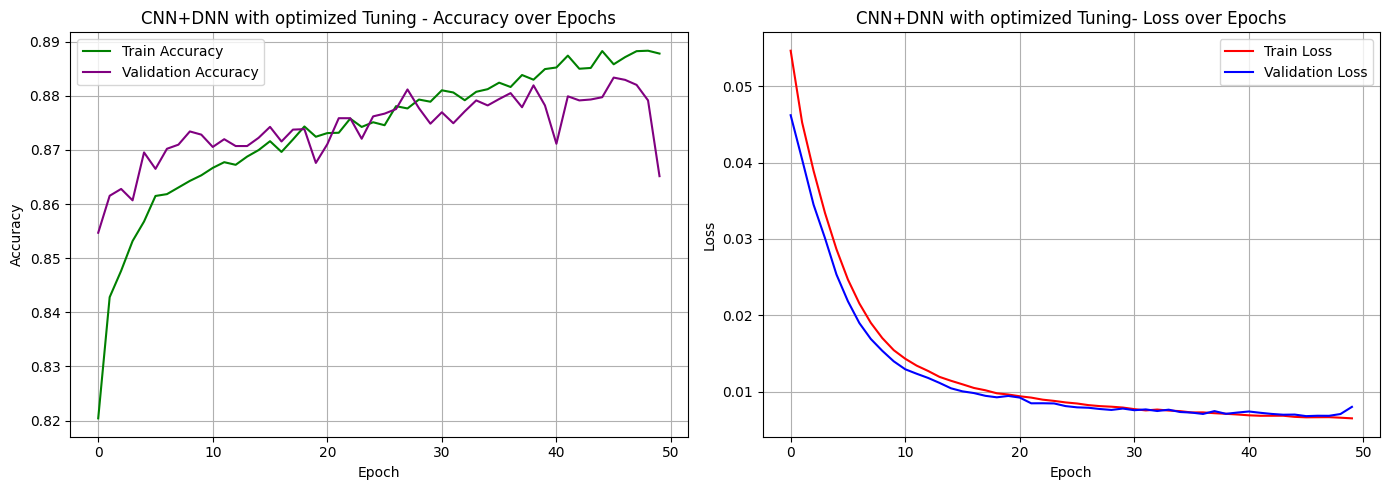

In [ ]:
# Plot Training & Validation Graphs
plt.figure(figsize=(14,5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy',  color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='purple')
plt.title('CNN+DNN with optimized Tuning - Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss',  color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.title('CNN+DNN with optimized Tuning- Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

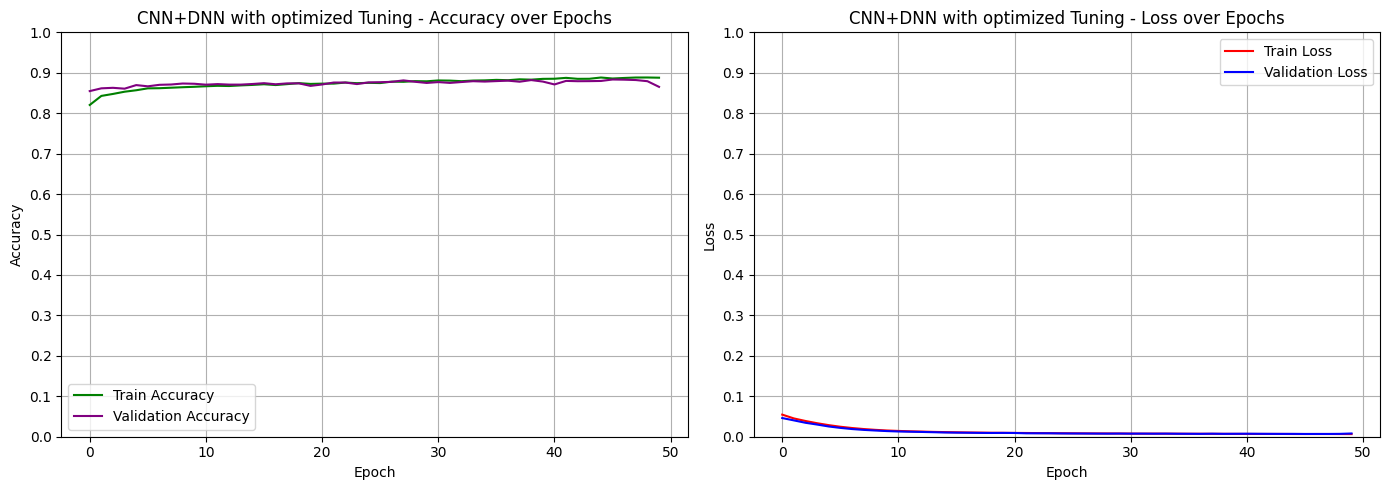

In [ ]:
# Plot Training & Validation Graphs
plt.figure(figsize=(14,5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy',  color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='purple')
plt.title('CNN+DNN with optimized Tuning - Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0.0, 1.0)
plt.yticks([i/10 for i in range(11)])
plt.grid(True)
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss',  color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.title('CNN+DNN with optimized Tuning - Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0.0, 1.0)
plt.yticks([i/10 for i in range(11)])
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

464/464 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


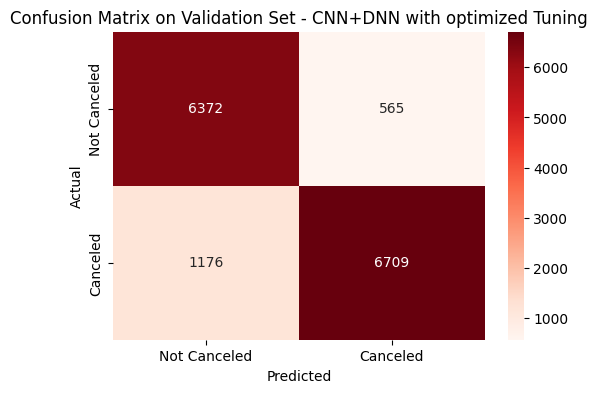


Classification Report for CNN+DNN with optimized Tuning:
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      6937
           1       0.92      0.85      0.89      7885

    accuracy                           0.88     14822
   macro avg       0.88      0.88      0.88     14822
weighted avg       0.89      0.88      0.88     14822



In [ ]:
# Confusion Matrix + Classification Report
y_pred_val = (cnn_dnn_focal_model.predict(X_test_seq) > 0.5).astype("int32")

cm_dnn = confusion_matrix(y_test_arr, y_pred_val)

labels = ['Not Canceled', 'Canceled']

plt.figure(figsize=(6,4))
sns.heatmap(cm_dnn, annot=True, fmt='d', cmap='Reds',
              xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix on Validation Set - CNN+DNN with optimized Tuning')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report for CNN+DNN with optimized Tuning:")
print(classification_report(y_test_arr, y_pred_val))

464/464 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


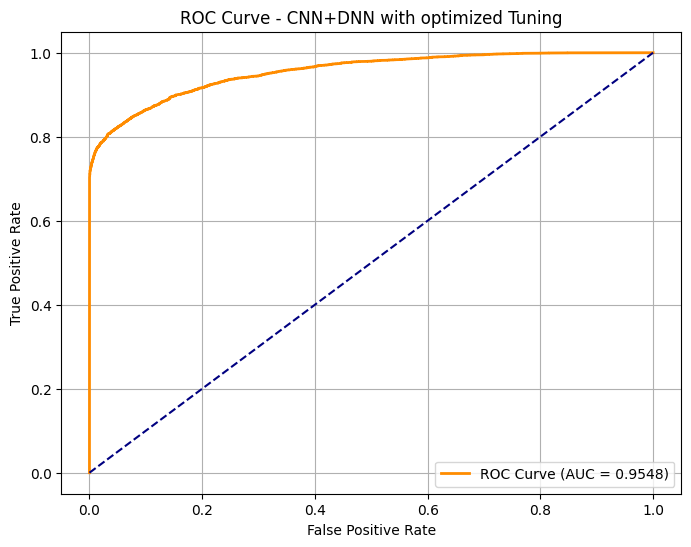

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities with CNN+DNN
y_pred_prob = cnn_dnn_focal_model.predict(X_test_seq).ravel()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_arr, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - CNN+DNN with optimized Tuning')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
# Final Test Accuracy and Loss for CNN+DNN
test_loss, test_accuracy = cnn_dnn_focal_model.evaluate(X_test_seq, y_test_arr, verbose=0)
print(f"\nFinal Test Accuracy (CNN+DNN with optimized Tuning): {test_accuracy:.4f}")
print(f"Final Test Loss (CNN+DNN with optimized Tuning): {test_loss:.4f}")


Final Test Accuracy (CNN+DNN with optimized Tuning): 0.8825
Final Test Loss (CNN+DNN with optimized Tuning): 0.0071


464/464 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


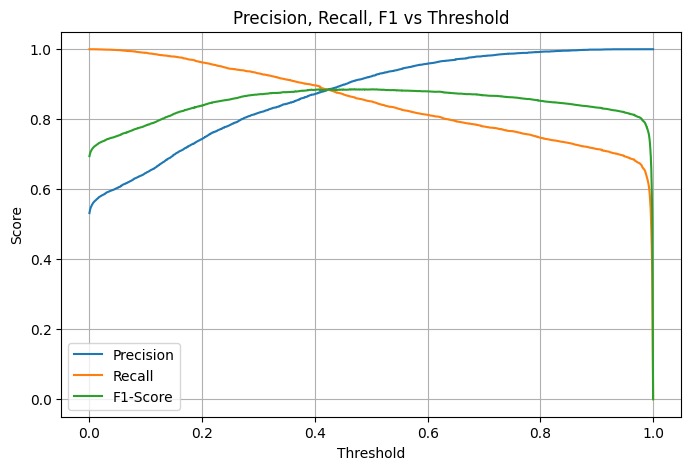

Best Threshold based on F1-Score: 0.4709


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score

# Predict probabilities
y_pred_prob = cnn_dnn_focal_model.predict(X_test_seq).ravel()

# Calculate precision, recall, thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test_arr, y_pred_prob)

# Compute F1 for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-6)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1-Score')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, F1 vs Threshold')
plt.grid(True)
plt.legend()
plt.show()

# Get best threshold (highest F1)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Best Threshold based on F1-Score: {best_threshold:.4f}")

y_pred = (y_pred_prob >= best_threshold).astype("int32")

464/464 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


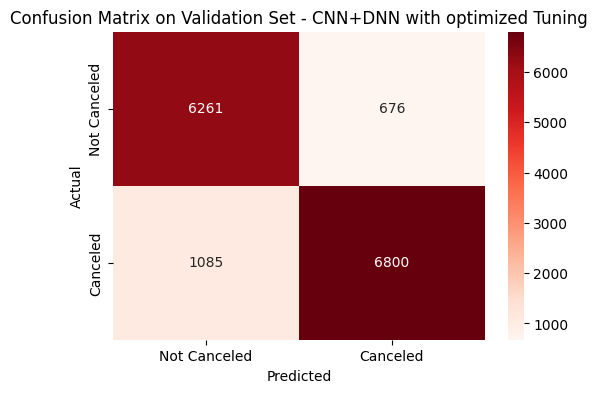


Classification Report for CNN+DNN with optimized Tuning:
              precision    recall  f1-score   support

           0       0.85      0.90      0.88      6937
           1       0.91      0.86      0.89      7885

    accuracy                           0.88     14822
   macro avg       0.88      0.88      0.88     14822
weighted avg       0.88      0.88      0.88     14822



In [ ]:
# Confusion Matrix + Classification Report
y_pred_val = (cnn_dnn_focal_model.predict(X_test_seq) > 0.47).astype("int32")

cm_dnn = confusion_matrix(y_test_arr, y_pred_val)

labels = ['Not Canceled', 'Canceled']

plt.figure(figsize=(6,4))
sns.heatmap(cm_dnn, annot=True, fmt='d', cmap='Reds',
              xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix on Validation Set - CNN+DNN with optimized Tuning')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report for CNN+DNN with optimized Tuning:")
print(classification_report(y_test_arr, y_pred_val))